# Objectif 


L'objectif est d'établir une formulation analytique du vecteur de RTF noté $\mathbf{\Pi}$ dans le cadre de la théorie des modes normaux.

\subsubsection{Hypothèses et cadre de travail}

* L'antenne est composée de M capteurs.
* La position des capteurs de l'antenne est notée $\mathbf{x_j}=(r_j, z_j)$.
* La source est positionnée sur l'axe z $\mathbf{x_s}=(0, z_s)$.
* L'environnement est axisymétrique.

## Formulation du problème

On pose 
$$
    Q =  \frac{e^{i3\pi/4}}{\rho(z_s) \sqrt{8 \pi}}
$$

et

$$
    A_m(z) = \Psi_m(z_{s}) \Psi_m(z) \frac{1}{\sqrt{k_{rm}}}
$$

La fonction de transfert du guide d'onde s'écrit,

$$
    H(f, r, z) = \frac{Q}{\sqrt{r}} \sum_{m=1}^{\infty} A_m(z) e^{-ik_{rm}
    r}
$$

En particulier, la fonction de transfert du canal de propagation associée au récepteur $j$ est :

$$
    H_{j} = \frac{Q}{\sqrt{r_j}} \sum_{m=1}**{\infty} A_m(z_j) e^{-ik_{rm}
    r_{j}}
$$

on s'intéresse au vecteur de RTF défini par

$$
    \mathbf{\Pi} \overset{\Delta}{=}
    \left [ \frac{H_{1}}{H_{1}} \, \frac{H_{2}}{H_{1}} \, \dots \, \frac{H_{M}}{H_{1}} \right ]^T
    = \frac{1}{H_{1}} \mathbf{H}
$$

En particulier, il s'agira d'étudier le comportement d'une composante du vecteur $\mathbf{\Pi}$,

$$
    \Pi_j = \frac{H_j}{H_1}, \quad j \in [1, J]
$$

## Approche calcul 

$$
I(r, z) = \frac{\tilde{Q}}{r} \left [  \sum_{m=1}^{\infty} A_m^2 + \sum_{m=1}^{\infty} \sum_{n>m}^{\infty} 2 A_m A_n \cos{\Delta k_{mn} r} \right ]
$$

On pose, 

$$
\gamma : r \mapsto \lvert \Pi_j(r, z) \rvert^2
$$

ie, 

$$
 \gamma(r) =  \frac{I(r_j, z)}{I(r_1, z)}
$$

En appliquant les règles de dérivation élémentaires,

$$
    \gamma'(r) = \frac{1}{I(r, z)^2} \left [I(r, z) \frac{\partial }{\partial r} I(r + d_j, z) - I(r + d_j, z)  \frac{\partial }{\partial r} I(r, z) \right ]
$$

$$
\frac{\partial }{\partial r} I(r, z) = \frac{-1}{r} \left [ I(r, z) + \tilde{Q} \sum_{m=1}^{\infty} \sum_{n>m}^{\infty} 2 A_m A_n \Delta k_{mn} \sin{\Delta k_{mn} r}\right ]
$$

## Cas étudié : antenne linéaire horizontale dans un guide d'onde isocélère avec une interface fond parfaitement solide 

**Conditions aux limites (cas parfaitement solide -> perfectly_rigid) **

Pression nulle en surface et au fond :
$$
p(r, z=0) = 0 \quad \text{et} \quad \frac{\partial p(r, z)}{\partial z} \rvert_{z=D} = 0 
$$

et les fonctions modales s'écrivent 

$$
\Psi_m(z) = \sqrt{\frac{2 \rho}{D}} \sin(k_{zm} z)
$$

Les fonctions $\Psi_m$ sont les fonctions propres associées aux valeurs propres $k_{rm}$,

$$
    k_{rm} = \sqrt{ k^2 - k_{zm}^2}
$$

avec, 

$$ 
k_{zm} =  (m - \frac{1}{2}) \frac{\pi}{D}, \quad m \in \mathbb{N}^{*} .
$$
           


**Conditions aux limites (cas parfaitement réfléchissant -> pressure release) **

Pression nulle en surface et au fond :
$$
p(r, z=0) = p(r, z=D) = 0 
$$

et les fonctions modales s'écrivent 

$$
\Psi_m(z) = \sqrt{\frac{2 \rho}{D}} \sin(k_{zm} z)
$$

Les fonctions $\Psi_m$ sont les fonctions propres associées aux valeurs propres $k_{rm}$,

$$
    k_{rm} = \sqrt{ k^2 - k_{zm}^2}
$$

avec, 

$$ 
k_{zm} =  \frac{m\pi}{D}, \quad m \in \mathbb{N}^{*} .
$$
           

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from propa.ideal_waveguide import (
    kr,
    psi,
    psi_normalised,
    h,
    field,
    plot_tl,
    nb_propagating_modes,
    intensity,
    intensity_1,
)


import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure, color

# Etape 1 : définition du guide d'onde parfait et illustration de quelques propriétés 

### Paramètres du problème

In [2]:
# Parameters
D = 100 # Depth of the waveguide
# Receiver
z_rcv = 50 # Depth of receiver
# Source
z_src= 25 # Depth of source 
# Signal
f0 = 100 # Frequency in Hz
# bottom_bc = 'pressure_release' # Bottom boundary condition
bottom_bc = "perfectly_rigid"  # Bottom boundary condition

# TL grid properties
ngrid = 1000 # Number of grid points along each dimension
rmax = 50 * 1e3 # Maximum range in m
r_grid = np.linspace(1, rmax, ngrid)
z_grid = np.linspace(0, D, ngrid)
rr, zz = np.meshgrid(r_grid, z_grid)

### Fonctions modales

In [3]:
n_propagating_modes_f0 = nb_propagating_modes(f=f0, c=g.c0, depth=D, bottom_bc=bottom_bc)
print(f"Number of propagating modes: {n_propagating_modes_f0}")

Number of propagating modes: 13


In [4]:
# Derive first three modes
# M = nb_propagating_modes(f=f, c=g.c0, depth=D, bottom_bc=bottom_bc)
M = 4
modes = np.arange(1, M+1).astype(int)
modal_fcts = []
z = np.linspace(0, D, int(1e4)) # Depths vector for modal functions
for m in modes:

    # psi_m = psi_normalised(m=m, z=z, depth=D, rho=g.rho_w, bottom_bc=bottom_bc)
    psi_m = psi(m=m, z=z, depth=D,  bottom_bc=bottom_bc)

    # Cast to complex to match with the general form of the modal function
    psi_m = psi_m.astype(complex)
    modal_fcts.append(psi_m)

modal_fcts = np.array(modal_fcts)

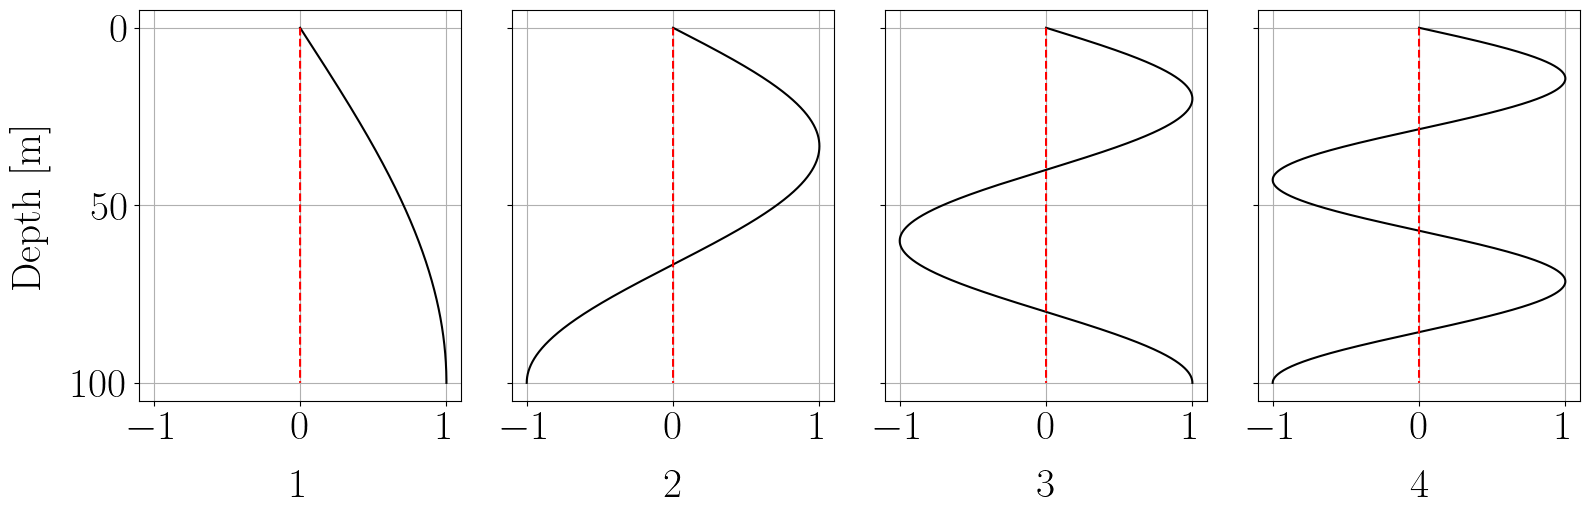

In [5]:
# Plot modal functions
lfig = LargeFigure()

fig, axs = plt.subplots(1, len(modes), sharey=True)
# Revert y-axis
axs[0].invert_yaxis()

max_amp = np.max(np.abs(modal_fcts))
axs[0].set_ylabel("Depth [m]")

for i, m in enumerate(modes):
    axs[i].plot(np.real(modal_fcts[i]), z, label=f"Real", linestyle="-", color="k")
    axs[i].plot(np.imag(modal_fcts[i]), z, label=f"Im", linestyle="--", color="r")
    axs[i].set_xlabel(m)
    axs[i].set_xlim([-1.1 * max_amp, 1.1 * max_amp])
    axs[i].grid()



## Pertes par transmission TL

Les pertes par transmission sont définies par : 
$$
\text{TL}(r, z) = -10 \times log_{10} \left \lvert \frac{p(r, z)}{p_0} \right \rvert^2
$$

où $p_0$ désigne la pression produite par la source à 1 m dans un milieu homogène infini et donné par : 

$$
p_0 = p_0(r=1) \quad \text{où} \quad p_0(r) = \frac{\text{e}^{-ikr}}{4\pi r}
$$

Cette expression des pertes par transmission est valide dans le cas où l'impédance du milieu est la même au point source et au point de réception (r, z). 

On peut également écrire les pertes en fonction du rapport des intensités : 

$$
\text{TL}(r, z) = -10 \times log_{10} \left \lvert \frac{I(r, z)}{I_0} \right \rvert^2
$$


In [6]:
# Derive transfert functions for different number of modes
modes = [1, 2, 3]
fields = []
for n in modes:
    ff, rr, zz, p_field = field(
        f=f0, z_src=z_src, z=z_grid, r=r_grid, depth=D, bottom_bc=bottom_bc, n=n
    )
    fields.append(p_field)
fields = np.array(fields)

### TL(r, z)

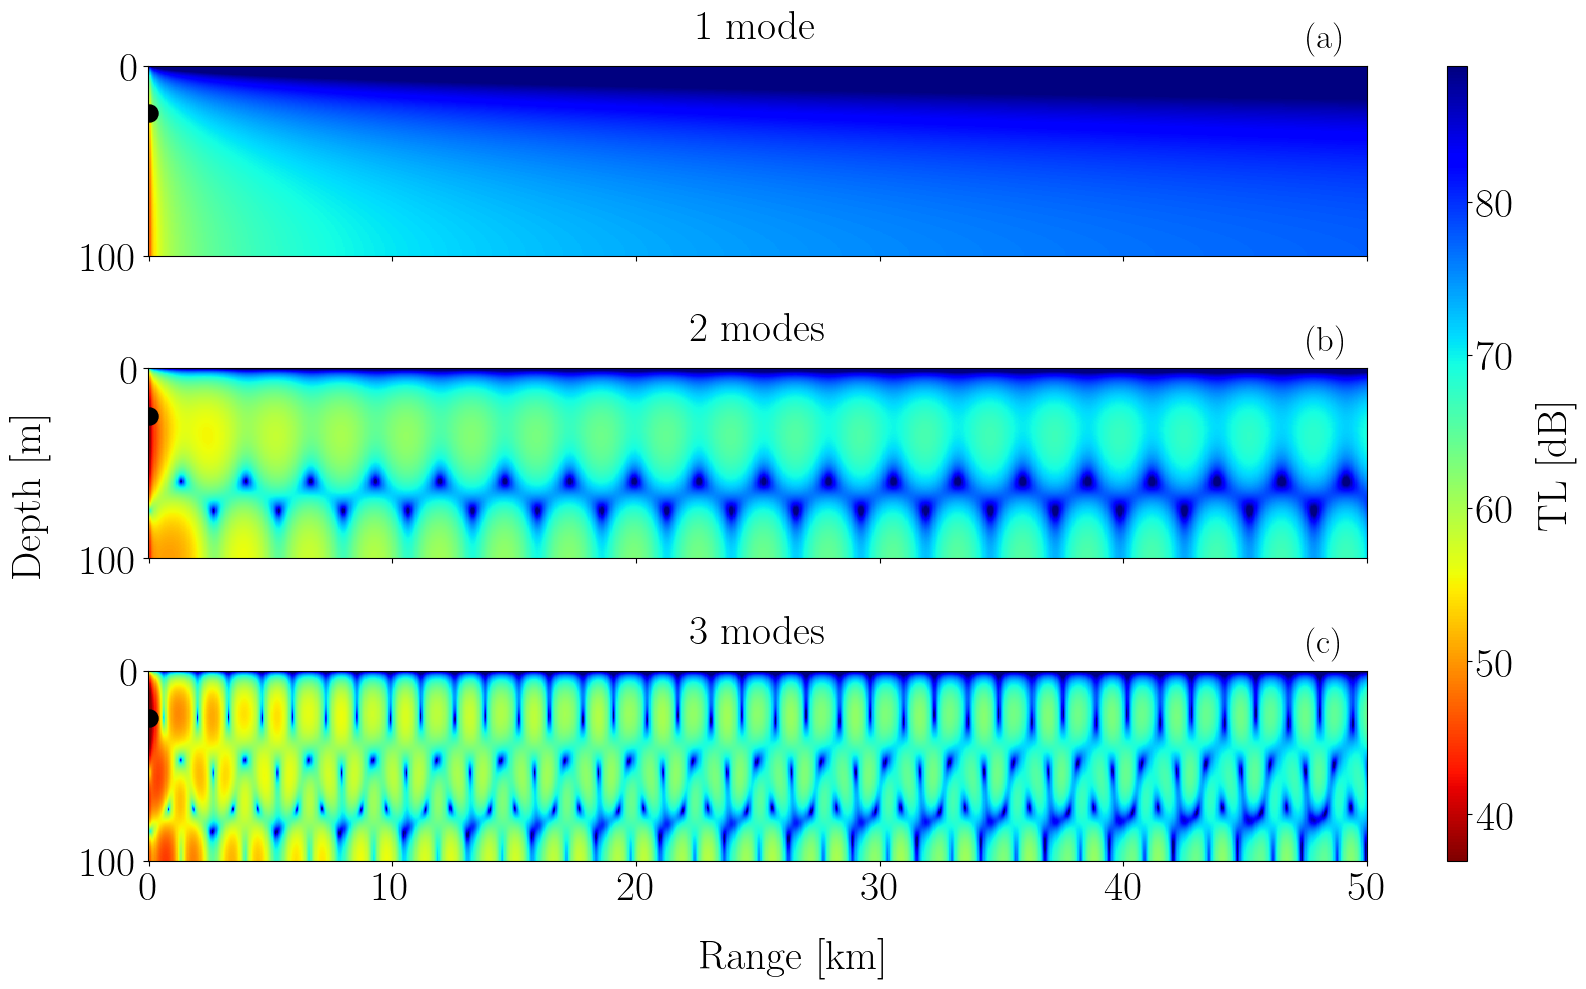

In [7]:
sfig = LargeFigure(size=(16, 10))


# Derive TLs
# Slice to get the pressure field at the single frequency
p_field = fields[:, 0, ...]
# Derive TL from the pressure field
p_field[(p_field == 0) | np.isnan(p_field)] = 1e-20
tl = -20 * np.log10( 4* np.pi * np.abs(p_field))
tlmax = np.percentile(tl, 95)
tlmin = np.percentile(tl, 1) - 15

# Plot TL for each number of modes
fig, axs = plt.subplots(len(modes), sharex=True)
abcd_labels = ["a", "b", "c", "d", "e", "f"]
for i, n in enumerate(modes):
    p_field = fields[i]
    if n == 1:
        title = "1 mode"
    else:
        title = f"{n} modes"

    # Plot TL
    im = axs[i].pcolormesh(rr * 1e-3, zz, tl[i], cmap="jet_r", vmin=tlmin, vmax=tlmax, rasterized=True)
    # plt.colorbar(im, label=r"$\textrm{TL [dB]}$", ax=axs[i])
    # Add source position
    if z_src is not None:
        axs[i].scatter(
            0,
            z_src,
            color="k",
            marker="o",
            s=150,
        )
    axs[i].set_title(title)
    axs[i].invert_yaxis()

    # Add a, b, c labels
    axs[i].text(
        0.95,
        1.05,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label("TL [dB]")

### TL(r, z=z_rcv)

L'exemple traité est identique au cas présenté dans le Jensen p. 347, 348. Les résultats sont identiques ce qui valide l'utilisation de ce cas test pour la suite du développement des calculs. 


In [8]:
# Compute TL using intensity for comparison
intensity_r = []
for n in modes:
    In = intensity(
        f=f0,
        z_src=z_src,
        z_rcv=z_rcv,
        r=r_grid,
        depth=D,
        bottom_bc=bottom_bc,
        n=n,
    )
    # In = intensity_1(
    #     f=f,
    #     z_src=z_src,
    #     z_rcv=z_rcv,
    #     r=r_grid,
    #     depth=D,
    #     bottom_bc=bottom_bc,
    #     n=n,
    # )

    intensity_r.append(In)
intensity_r = np.array(intensity_r)

Text(0.02, 0.5, 'TL [dB]')

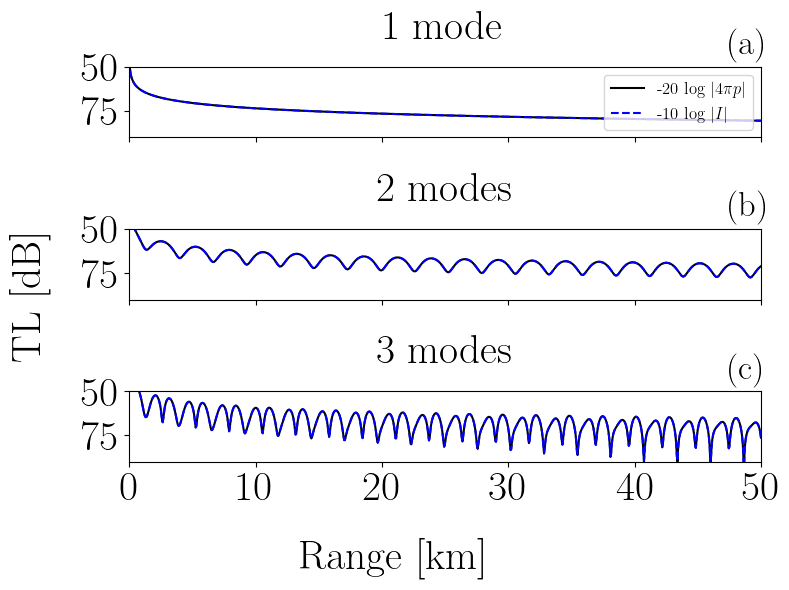

In [9]:
lfig = LargeFigure(size=(8, 6), legend_fontsize=12)

# Derive TLs
# Slice to get the pressure field at the single frequency and single depth
idx_z_rcv = np.argmin(np.abs(z_grid - z_rcv))
p_field = fields[:, 0, idx_z_rcv, :]
# Derive TL from the pressure field
p_field[(p_field == 0) | np.isnan(p_field)] = 1e-20
tl = -20 * np.log10(4*np.pi*np.abs(p_field))

tl_I = -10 * np.log10(intensity_r)

# Plot TL for each number of modes
fig, axs = plt.subplots(len(modes), sharex=True)
abcd_labels = ["a", "b", "c", "d", "e", "f"]
for i, n in enumerate(modes):
    if n == 1:
        title = "1 mode"
    else:
        title = f"{n} modes"

    # axs[i].plot(
    #     r_grid * 1e-3, 10*np.log10(r_grid), color="r", linestyle="--", label="10 log (r)"
    # )

    # Plot TL
    axs[i].plot(
        r_grid * 1e-3, tl[i], label=r"-20 log $\lvert 4 \pi p \rvert $", color="k"
    )
    # Plot TL I
    axs[i].plot(
        r_grid * 1e-3, tl_I[i], label=r"-10 log $\lvert I \rvert $", color="b", linestyle="--"
    )

    # # Plot TL I detrended
    # tl_I_detrended = tl_I[i]-15 * np.log10(r_grid)
    # tl_I_detrended -= np.mean(tl_I_detrended) 
    # axs[i].plot(
    #     r_grid * 1e-3,
    #     tl_I_detrended,
    #     label=r"-10 log $\lvert I \rvert $",
    #     color="b",
    #     linestyle="--",
    # )

    axs[i].set_title(title)
    axs[i].set_ylim([50,90])
    axs[i].invert_yaxis()
    axs[i].set_xlim([0, rmax * 1e-3])

    # Add a, b, c labels
    axs[i].text(
        0.95,
        1.05,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )
    if i == 0:
        axs[i].legend()

fig.supxlabel("Range [km]")
fig.supylabel("TL [dB]")

2 : delta_k (m=1, n=2) =  0.0004 1/m
3 : delta_k (m=1, n=2) =  0.0004 1/m
3 : delta_k (m=1, n=3) =  0.0011 1/m
3 : delta_k (m=2, n=3) =  0.0008 1/m


Text(0.02, 0.5, '$\\lvert FFT(I(r)) \\rvert$')

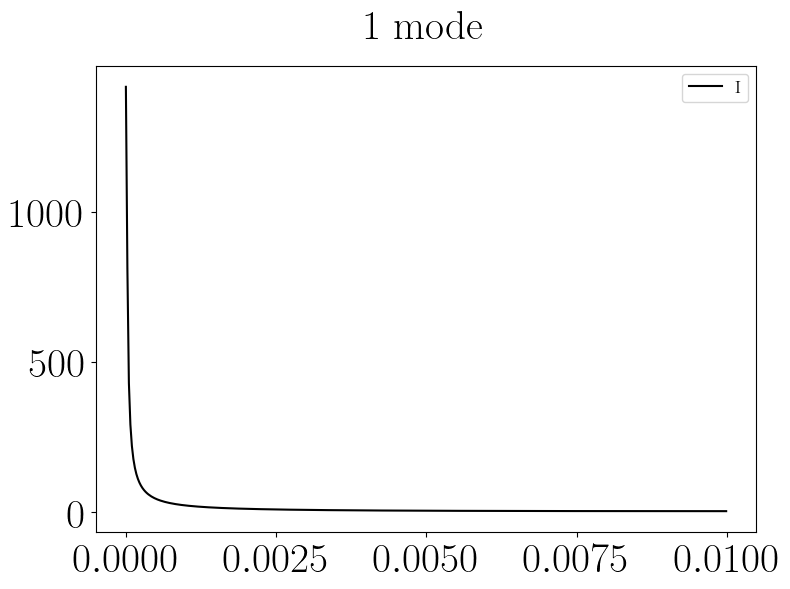

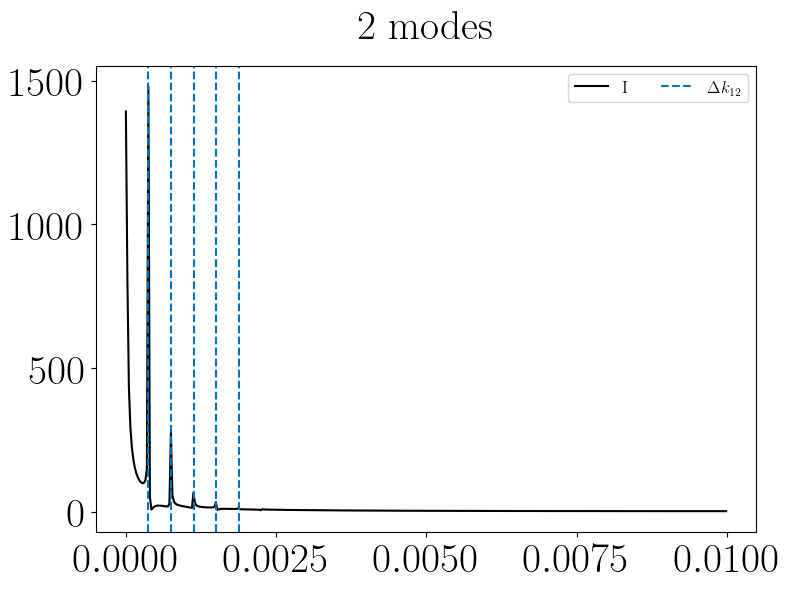

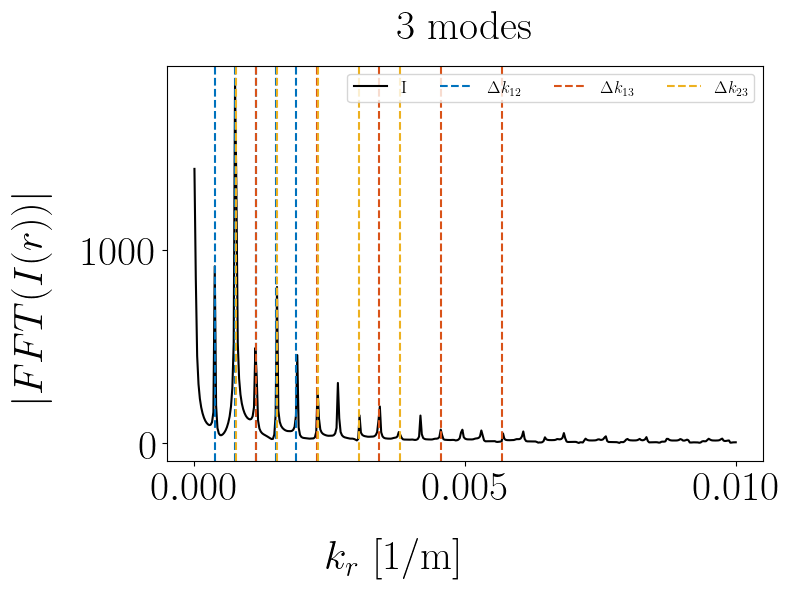

In [10]:
lfig = LargeFigure(size=(8, 6), legend_fontsize=12)

modes = [1, 2, 3]
# Apply fft to intensity
# intensity_r_detrended = (
#     10 * np.log10(intensity_r) - 15 * np.log10(r_grid)[np.newaxis, :]
# )

intensity_r_detrended = 10 * np.log10(intensity_r)
intensity_r_detrended = intensity_r_detrended - np.mean(
    intensity_r_detrended, axis=-1, keepdims=True
)
# Crop first km
intensity_r_detrended = intensity_r_detrended[:, r_grid >= 10*1e3]

intensity_r_fft = rfft(intensity_r_detrended, axis=-1)
dr = r_grid[1] - r_grid[0]
k_r = rfftfreq(intensity_r_detrended.shape[1], d=dr)

# Plot TL for each number of modes
# fig, axs = plt.subplots(len(modes), sharex=True)
abcd_labels = ["a", "b", "c", "d", "e", "f"]
for i_m, m in enumerate(modes):

    fig, ax = plt.subplots(1, 1)

    if m == 1:
        title = "1 mode"
    else:
        title = f"{m} modes"

    # Plot TL I
    ax.plot(
        k_r,
        np.abs(intensity_r_fft[i_m]),
        label=r"I",
        color="k",
        linestyle="-",
    )

    ax.set_title(title)

    col_count = 0
    for mm in range(1, m+1):
        if mm+1 < m+1:
            for nn in range(mm+1, m+1):
                k_rm = kr(mm, f=f0, depth=D, bottom_bc=bottom_bc)
                k_rn = kr(nn, f=f0, depth=D, bottom_bc=bottom_bc)
                delta_kmn = k_rm - k_rn
                delta_kmn /= 2 * np.pi
                # l_delta = 2 * np.pi / delta_kmn
                # print(f"L_mn (m={m}, n={n}) =  {l_delta:.2f} m")
                print(f"{m} : delta_k (m={mm}, n={nn}) =  {delta_kmn:.4f} 1/m")

                for h in range(1,6):
                    if h > 1:
                        # label = rf"${{{h}}}\Delta k_{{{mm} {nn}}}$"
                        label = None
                    else:
                        label = rf"$\Delta k_{{{mm} {nn}}}$"
                    ax.axvline(
                        delta_kmn * h,
                        color=color(col_count),
                        linestyle="--",
                        label=label,
                    )
                col_count += 1

    ax.legend(ncols=col_count+1)


fig.supxlabel(r"$k_r$ [1/m]")
fig.supylabel(r"$\lvert FFT(I(r)) \rvert$")

# Étape 2 : étude du rapport des fonctions de transfert
L'objectif ici est d'étudier les variations spatiales du rapport des fonctions de transfert et de guider le calcul analytique. Dans un premier temps :

* la fréquence f est fixée
* l'immersion de la source est fixée
* l'antenne est linéaire horizontale 

Ainsi, il s'agit d'étudier les variations du rapport de deux fonctions de transfert en fonctions de la distance $r$ de la source au premier capteur de l'antenne (pris pour référence). On s'intérèsse au rapport : 

$$ 
\Pi_{12}(r, z) = \frac{H(r + d_2, z)}{H(r, z)}
$$

Les notations utilisées correspondant aux notations introduites et schématisées dans la note de calcul du même nom que ce notebook. 

In [11]:
def lambda_rm(f, m):
    k_rm = kr(m, f, depth=D, bottom_bc=bottom_bc)
    lambda_m = 2 * np.pi / k_rm
    return lambda_m

## Étude à la fréquence f0 = 100 Hz 

In [12]:
# Parameters
d12 = 10  # Distance between receiver 1 and 2 in m
z_antenna = 50 # Depth of the antenna in m

# Define range vectors
nrgrid = 5000
rmin = 1
rmax = 200 * 1e3
r_grid = np.linspace(rmin, rmax, nrgrid)
r_grid1 = r_grid
r_grid2 = r_grid + d12

# Define z vectors
nzgrid = 400
z_grid = np.linspace(0, D, nzgrid)
rr1, zz1 = np.meshgrid(r_grid, z_grid)
rr2, zz2 = np.meshgrid(r_grid2, z_grid)

In [13]:
# Number of modes to consider (e.g 3 means first three modes)
modes = [1, 2, 3, 4, 5]

In [14]:
# Compute RTF on the whole grid for a different number of modes
def pi_12_modes(f, z_antenna, z_grid, r_grid, d12, depth, bottom_bc, modes):
    r_grid1 = r_grid
    r_grid2 = r_grid + d12
    pi_12 = []
    for n in modes:
        ff, rr, zz, p_field1 = field(
            f=f, z_src=z_antenna, z=z_grid, r=r_grid1, depth=depth, bottom_bc=bottom_bc, n=n
        )
        ff, _, _, p_field2 = field(
            f=f,
            z_src=z_antenna,
            z=z_grid,
            r=r_grid2,
            depth=depth,
            bottom_bc=bottom_bc,
            n=n,
        )
        p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
        p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
        pi_12.append(p_field2 / p_field1)
    pi_12 = np.array(pi_12)
    pi_12 = np.squeeze(pi_12)

    return rr, zz, pi_12

In [15]:
# # Compute RTF on the whole grid for a different number of modes
# pi_12 = []
# for n in modes:
#     ff, rr, zz, p_field1 = field(
#         f=f0, z_src=z_antenna, z=z_grid, r=r_grid1, depth=D, bottom_bc=bottom_bc, n=n
#     )
#     ff, _, _, p_field2 = field(
#         f=f0, z_src=z_antenna, z=z_grid, r=r_grid2, depth=D, bottom_bc=bottom_bc, n=n
#     )
#     p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
#     p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
#     pi_12.append(p_field2/ p_field1)
# pi_12 = np.array(pi_12)
# pi_12 = np.squeeze(pi_12)
rr, zz, pi_12 = pi_12_modes(
    f=f0,
    z_antenna=z_antenna,
    z_grid=z_grid,
    r_grid=r_grid1,
    d12=d12,
    depth=D,
    bottom_bc=bottom_bc,
    modes=modes,
)

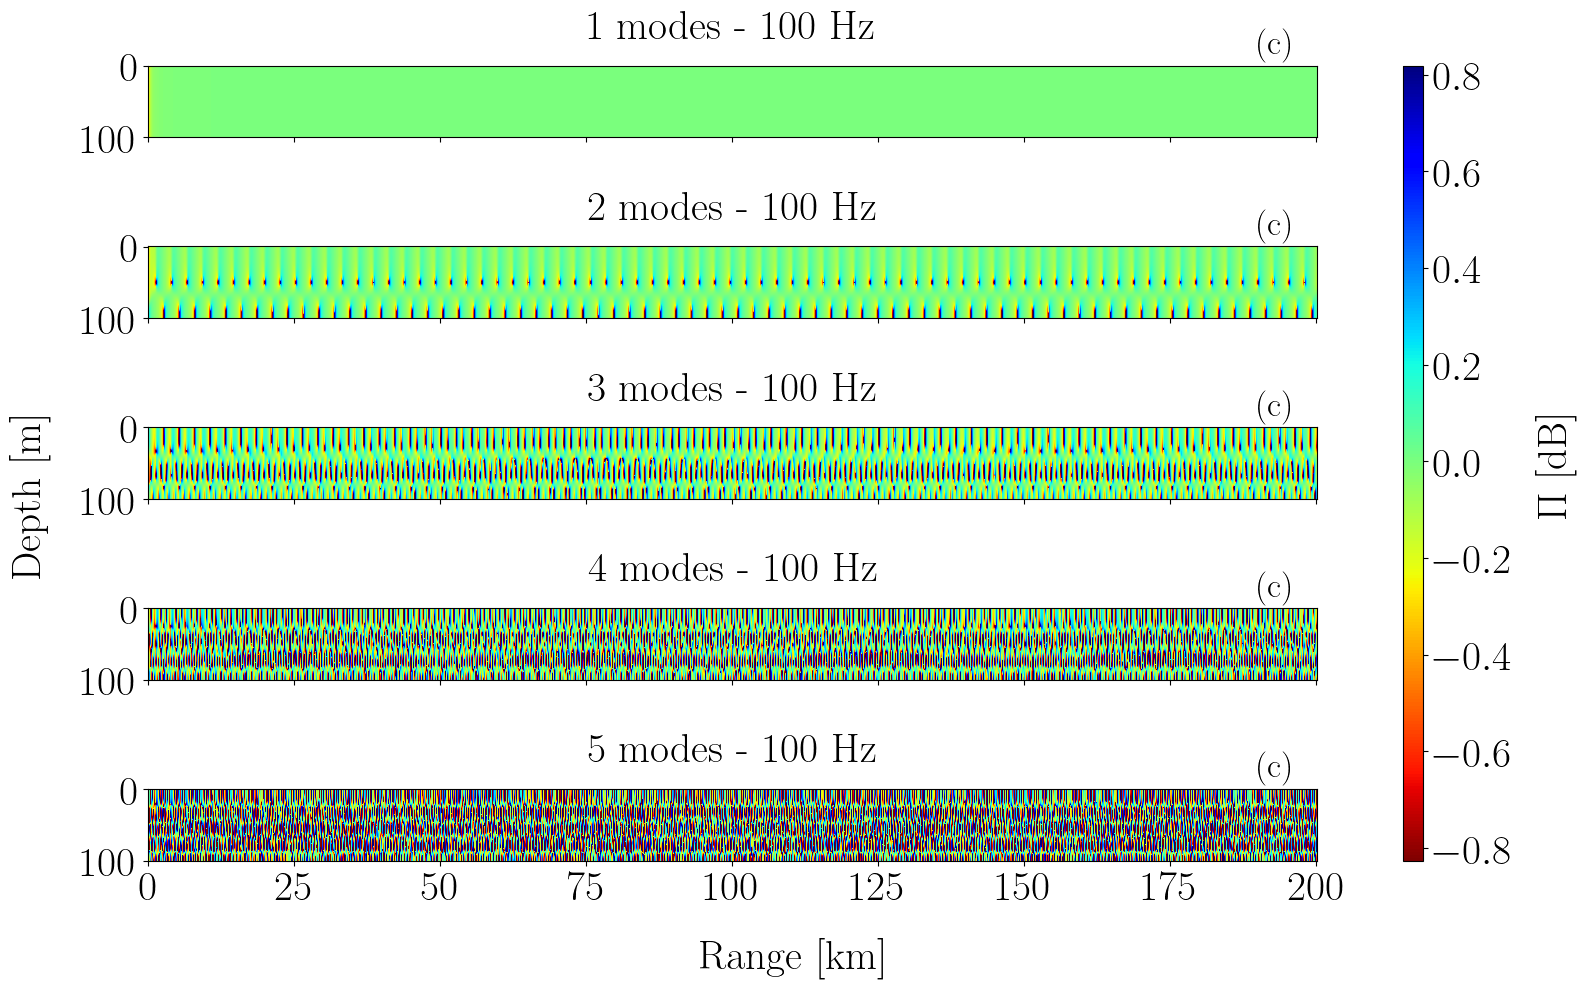

In [16]:
sfig = LargeFigure(size=(16, 10))

pi = 20 * np.log10(np.abs(pi_12))
vmin = np.percentile(pi, 5)
vmax = np.percentile(pi, 95)

fig, axs = plt.subplots(len(modes), sharex=True)
for i_m, m in enumerate(modes):

    # Plot at given number of modes
    title = f"{m} modes - {f0} Hz"
    # Plot TL
    # pi = 20 * np.log10(np.abs(pi_12[i_m]))
    # vmin = np.percentile(pi, 25)
    # vmax = np.percentile(pi, 75)
    im = axs[i_m].pcolormesh(
        rr * 1e-3,
        zz,
        pi[i_m],
        vmin=vmin,
        vmax=vmax,
        cmap="jet_r",
        rasterized=True,
    )
    axs[i_m].invert_yaxis()

    # Add a, b, c labels
    axs[i_m].text(
        0.95,
        1.05,
        f"({abcd_labels[i]})",
        transform=axs[i_m].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )
    axs[i_m].set_title(title)

    fig.supxlabel("Range [km]")
    fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label(r"$\Pi$ [dB]")

### Étude à z fixé 

In [17]:
pi_12_r = []
for n in modes:
    ff, rr, zz, p_field1 = field(
        f=f0, z_src=z_antenna, z=z_src, r=r_grid1, depth=D, bottom_bc=bottom_bc, n=n
    )
    ff, _, _, p_field2 = field(
        f=f0, z_src=z_antenna, z=z_src, r=r_grid2, depth=D, bottom_bc=bottom_bc, n=n
    )
    p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
    p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
    pi_12_r.append(p_field2 / p_field1)
pi_12_r = np.array(pi_12_r)
pi_12_r = pi_12_r.squeeze()  # nmodes  x nranges

Text(0.02, 0.5, '20 log $\\lvert \\Pi(r) \\rvert $')

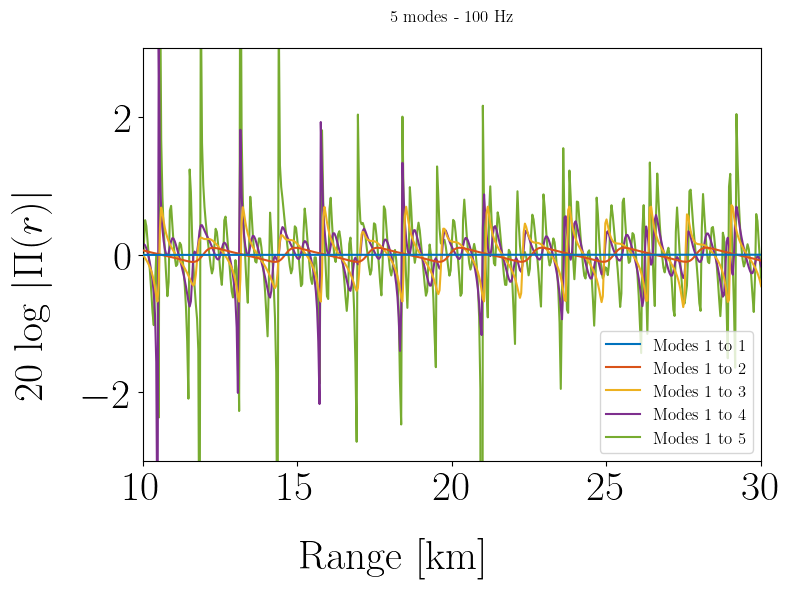

In [18]:
lfig = LargeFigure(size=(8, 6), legend_fontsize=12)


# Plot TL for each number of modes
fig, ax = plt.subplots(1, 1, sharex=True)
abcd_labels = ["a", "b", "c", "d", "e", "f"]
for i_m, m in enumerate(modes):

    # Plot Pi for each freq at given number of modes
    pi = 20 * np.log10(np.abs(pi_12_r[i_m]))
    # pi = np.abs(pi_12[i_mode, idx_freq])
    ax.plot(r_grid * 1e-3, pi, label=f"Modes 1 to {m}", color=color(i_m), zorder=len(modes)-i_m)

ax.set_title(title, fontsize=12)
ax.set_ylim([-3, 3])
ax.set_xlim([10, 30])

# Add legend
ax.legend()

fig.supxlabel("Range [km]")
fig.supylabel(r"20 log $\lvert \Pi(r) \rvert $")

#### Analyse spectrale de la fonction $r \mapsto \lvert \Pi_{12}(r, z=z_s) \rvert$

In [19]:
# Remove first km to avoid near-field effects
rmin_crop = 5 * 1e3
idx_rmin_crop = np.argmin(np.abs(r_grid - rmin_crop))

pi_12_r_crop = pi_12_r[..., idx_rmin_crop:]
pi_12_r_crop_abs = np.abs(pi_12_r_crop) 
pi_12_r_crop_phase = np.angle(pi_12_r_crop)

# Remove mean
pi_12_r_crop_abs -= np.mean(pi_12_r_crop_abs, axis=-1, keepdims=True)
pi_12_r_crop_phase -= np.mean(pi_12_r_crop_phase, axis=-1, keepdims=True)

# Apply FFT along range axis
pi_12_r_abs_fft = rfft(pi_12_r_crop_abs, axis=-1)
pi_12_r_phase_fft = rfft(pi_12_r_crop_phase, axis=-1)

# Derive frequency axis
dr = r_grid[1] - r_grid[0]
k_r = rfftfreq(pi_12_r_crop.shape[-1], d=dr)

In [20]:
# # Get peaks in the FFT
# for idx_freq, freq in enumerate(f):
#     for i_mode, n in enumerate(n_modes):
#         peaks, properties = find_peaks(np.abs(pi_12_abs_fft[i_mode, idx_freq]), distance = 10)
#         peak_k_r = k_r[peaks]
#         print(f"Frequency {freq} Hz - {n} modes - Peak k_r: {peak_k_r}")

2 : delta_k (m=1, n=2) =  0.0004 1/m
3 : delta_k (m=1, n=2) =  0.0004 1/m
3 : delta_k (m=1, n=3) =  0.0011 1/m
3 : delta_k (m=2, n=3) =  0.0008 1/m
4 : delta_k (m=1, n=2) =  0.0004 1/m
4 : delta_k (m=1, n=3) =  0.0011 1/m
4 : delta_k (m=1, n=4) =  0.0023 1/m
4 : delta_k (m=2, n=3) =  0.0008 1/m
4 : delta_k (m=2, n=4) =  0.0019 1/m
4 : delta_k (m=3, n=4) =  0.0012 1/m
5 : delta_k (m=1, n=2) =  0.0004 1/m
5 : delta_k (m=1, n=3) =  0.0011 1/m
5 : delta_k (m=1, n=4) =  0.0023 1/m
5 : delta_k (m=1, n=5) =  0.0039 1/m
5 : delta_k (m=2, n=3) =  0.0008 1/m
5 : delta_k (m=2, n=4) =  0.0019 1/m
5 : delta_k (m=2, n=5) =  0.0035 1/m
5 : delta_k (m=3, n=4) =  0.0012 1/m
5 : delta_k (m=3, n=5) =  0.0027 1/m
5 : delta_k (m=4, n=5) =  0.0016 1/m


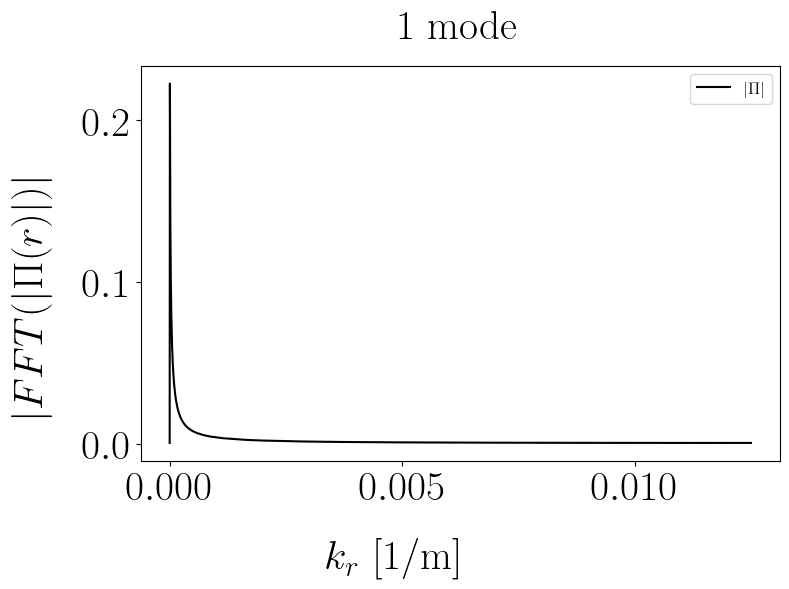

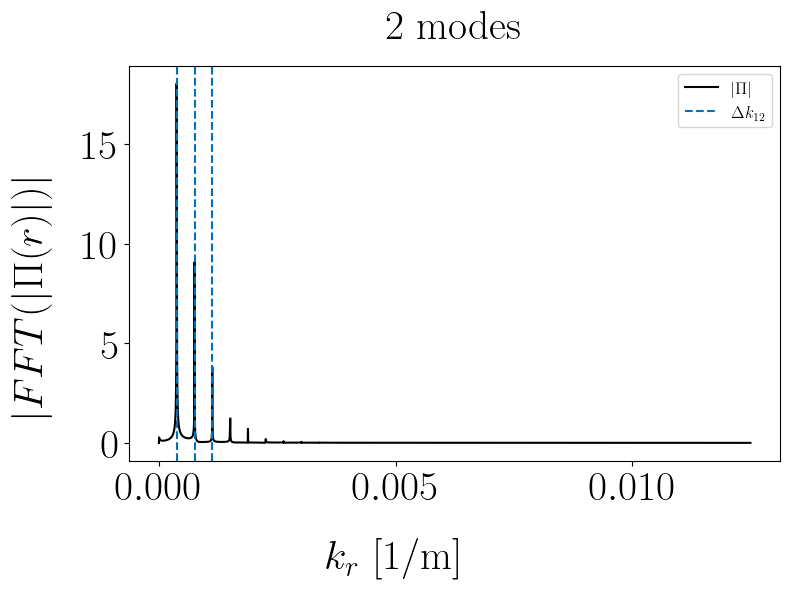

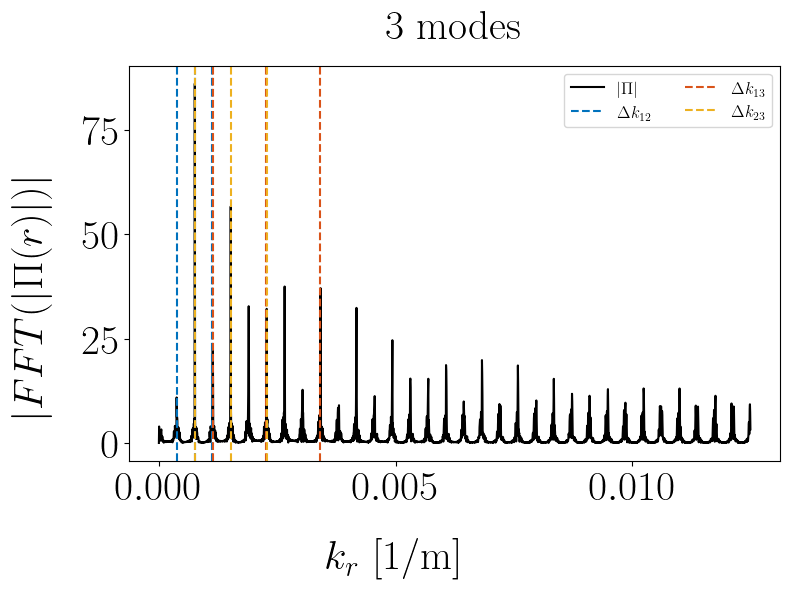

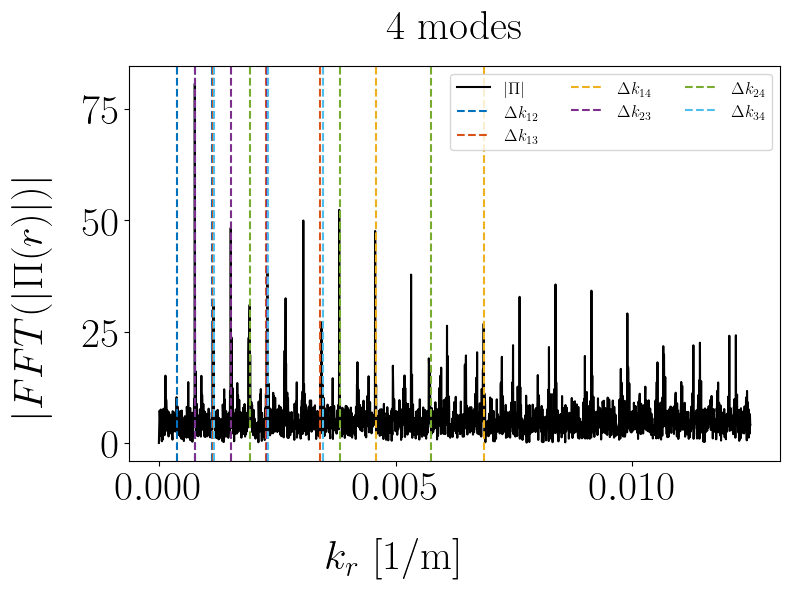

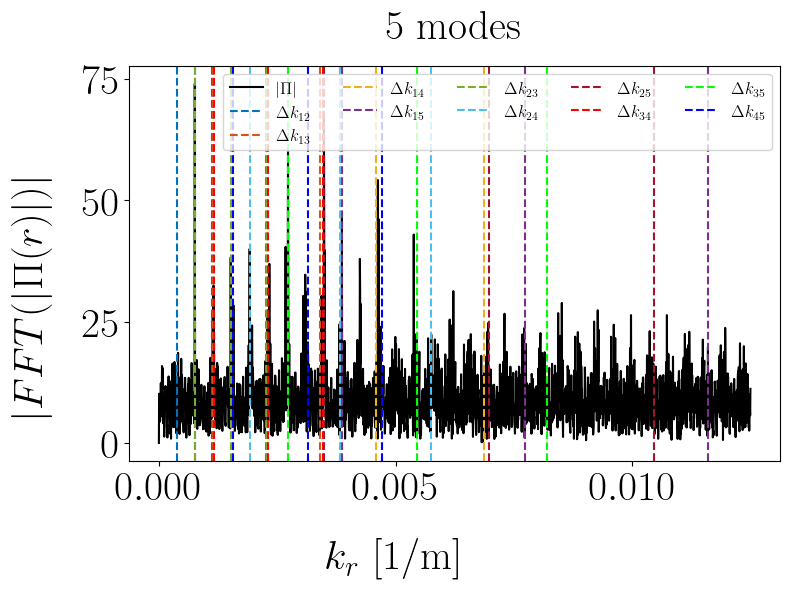

In [21]:
lfig = LargeFigure(size=(8, 6), legend_fontsize=12)

abcd_labels = ["a", "b", "c", "d", "e", "f"]
for i_m, m in enumerate(modes):

    fig, ax = plt.subplots(1, 1)

    if m == 1:
        title = "1 mode"
    else:
        title = f"{m} modes"

    # Plot TL I
    ax.plot(
        k_r,
        np.abs(pi_12_r_abs_fft[i_m]),  # Select freq index 2 (100 Hz)
        label=r"$\lvert \Pi \rvert$",
        color="k",
        linestyle="-",
    )

    ax.set_title(title)

    # if m <= 3:
    m_max_plot = min(m, 5)
    col_count = 0
    for mm in range(1, m_max_plot + 1):
        if mm + 1 < m_max_plot + 1:
            for nn in range(mm + 1, m_max_plot + 1):
                k_rm = kr(mm, f=f0, depth=D, bottom_bc=bottom_bc)
                k_rn = kr(nn, f=f0, depth=D, bottom_bc=bottom_bc)
                delta_kmn = k_rm - k_rn
                delta_kmn /= 2 * np.pi
                # l_delta = 2 * np.pi / delta_kmn
                # print(f"L_mn (m={m}, n={n}) =  {l_delta:.2f} m")
                print(f"{m} : delta_k (m={mm}, n={nn}) =  {delta_kmn:.4f} 1/m")

                for h in range(1, 4):
                    if h > 1:
                        # label = rf"${{{h}}}\Delta k_{{{mm} {nn}}}$"
                        label = None
                    else:
                        label = rf"$\Delta k_{{{mm} {nn}}}$"
                    ax.axvline(
                        delta_kmn * h,
                        color=color(col_count),
                        linestyle="--",
                        label=label,
                    )
                col_count += 1

    ax.legend(ncols=(col_count + 1)//2)

    fig.supxlabel(r"$k_r$ [1/m]")
    fig.supylabel(r"$\lvert FFT(\lvert \Pi(r) \rvert) \rvert$")

#### Variation en fonction de la distance intercapteur 

L'objectif est d'étudier l'impact de la distance dj entre les deux capteurs sur le rapport des fonctions de transfert 

In [22]:
# Parameters
d12_bis = 250  # New distance between receiver 1 and 2 in m
# # Déphasage = 2pi
# delta_k12 = kr(1, f=f0, depth=D, bottom_bc=bottom_bc) - kr(
#     2, f=f0, depth=D, bottom_bc=bottom_bc
# )
# d12_bis = 2* np.pi / delta_k12

r_grid2 = r_grid + d12_bis

In [23]:
rr, zz, pi_12_bis = pi_12_modes(
    f=f0,
    z_antenna=z_antenna,
    z_grid=z_grid,
    r_grid=r_grid1,
    d12=d12_bis,
    depth=D,
    bottom_bc=bottom_bc,
    modes=modes,
)


# pi_12_bis = []
# for n in modes:
#     ff, rr, zz, p_field1 = field(
#         f=f0, z_src=z_antenna, z=z_grid, r=r_grid1, depth=D, bottom_bc=bottom_bc, n=n
#     )
#     ff, _, _, p_field2 = field(
#         f=f0, z_src=z_antenna, z=z_grid, r=r_grid2, depth=D, bottom_bc=bottom_bc, n=n
#     )
#     p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
#     p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
#     pi_12_bis.append(p_field2 / p_field1)
# pi_12_bis = np.array(pi_12_bis)
# pi_12_bis = np.squeeze(pi_12_bis)

Text(0.02, 0.5, 'Depth [m]')

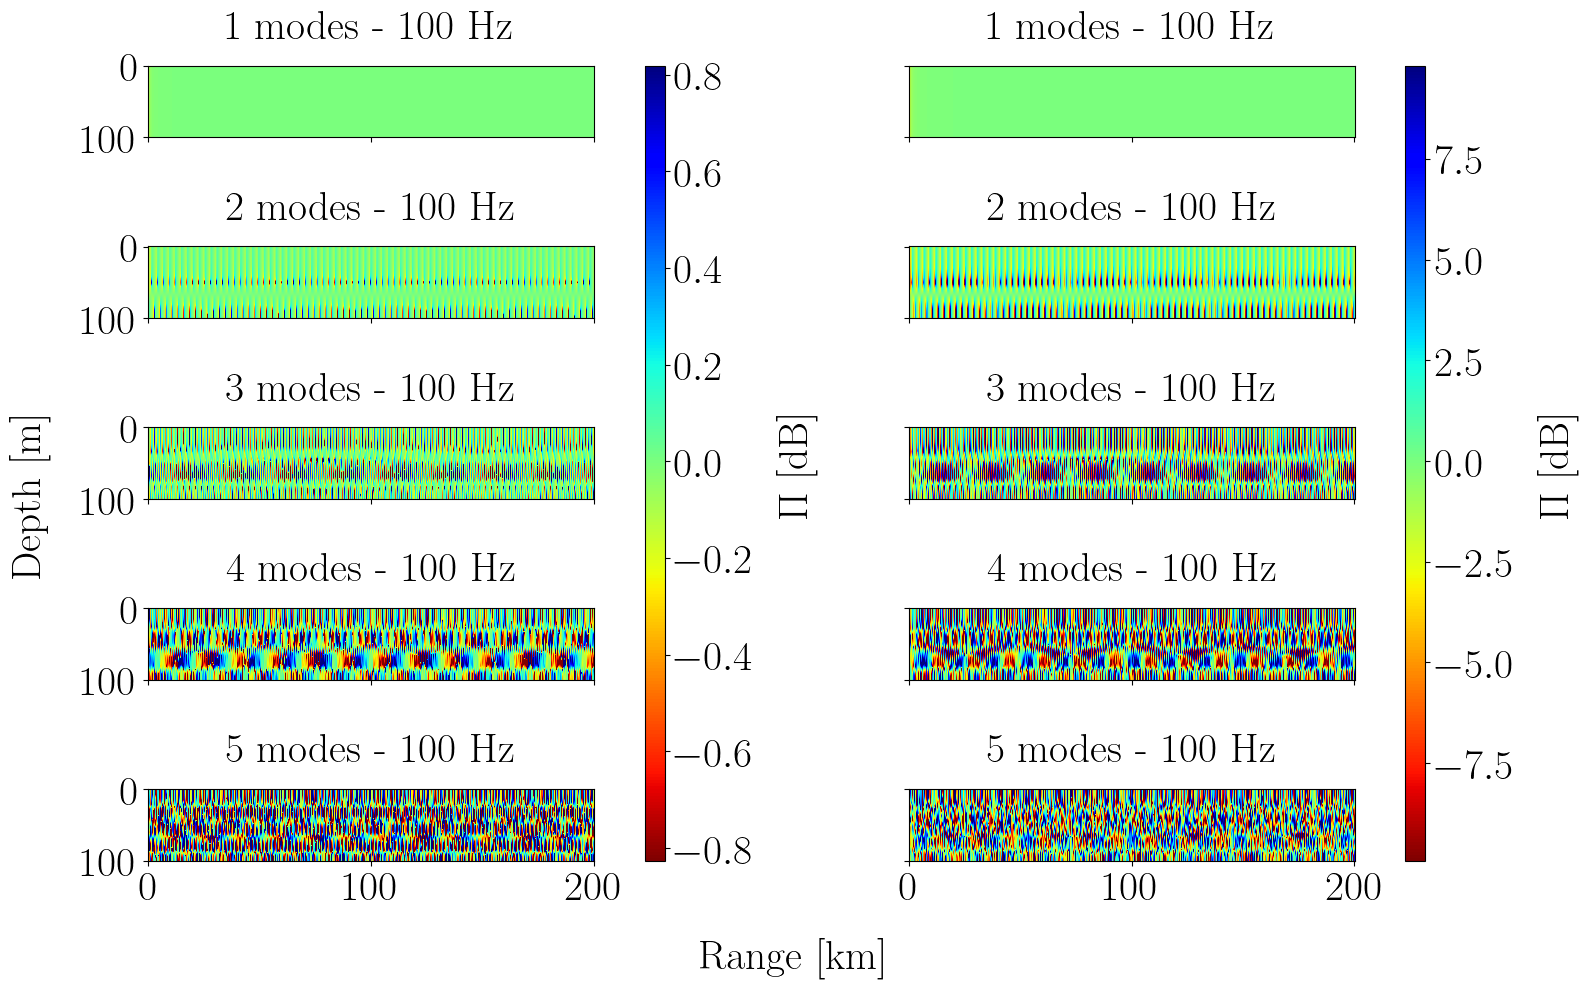

In [24]:
sfig = LargeFigure(size=(16, 10))

pi = 20 * np.log10(np.abs(pi_12))
vmin_1 = np.percentile(pi, 5)
vmax_1 = np.percentile(pi, 95)

pi_bis = 20 * np.log10(np.abs(pi_12_bis))
vmin_2 = np.percentile(pi_bis, 5)
vmax_2 = np.percentile(pi_bis, 95)

fig, axs = plt.subplots(len(modes), 2, sharex=True, sharey=True)
for i_m, m in enumerate(modes):

    # Plot at given number of modes
    title = f"{m} modes - {f0} Hz"

    im1 = axs[i_m, 0].pcolormesh(
        rr * 1e-3,
        zz,
        pi[i_m],
        vmin=vmin_1,
        vmax=vmax_1,
        cmap="jet_r",
        rasterized=True,
    )
    axs[i_m, 0].invert_yaxis()

    im2 = axs[i_m, 1].pcolormesh(
        rr * 1e-3,
        zz,
        pi_bis[i_m],
        vmin=vmin_2,
        vmax=vmax_2,
        cmap="jet_r",
        rasterized=True,
    )

    # # Add a, b, c labels
    # axs[i_m].text(
    #     0.95,
    #     1.05,
    #     f"({abcd_labels[i]})",
    #     transform=axs[i_m].transAxes,
    #     fontsize=25,
    #     fontweight="bold",
    #     va="bottom",
    # )
    axs[i_m, 0].set_title(title)
    axs[i_m, 1].set_title(title)



# Add colorbar
cbar = fig.colorbar(im1, ax=axs[:, 0], orientation="vertical", pad=0.05, aspect=40)
cbar.set_label(r"$\Pi$ [dB]")
cbar = fig.colorbar(im2, ax=axs[:, 1], orientation="vertical", pad=0.05, aspect=40)
cbar.set_label(r"$\Pi$ [dB]")
    
fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

Text(0.02, 0.5, 'Depth [m]')

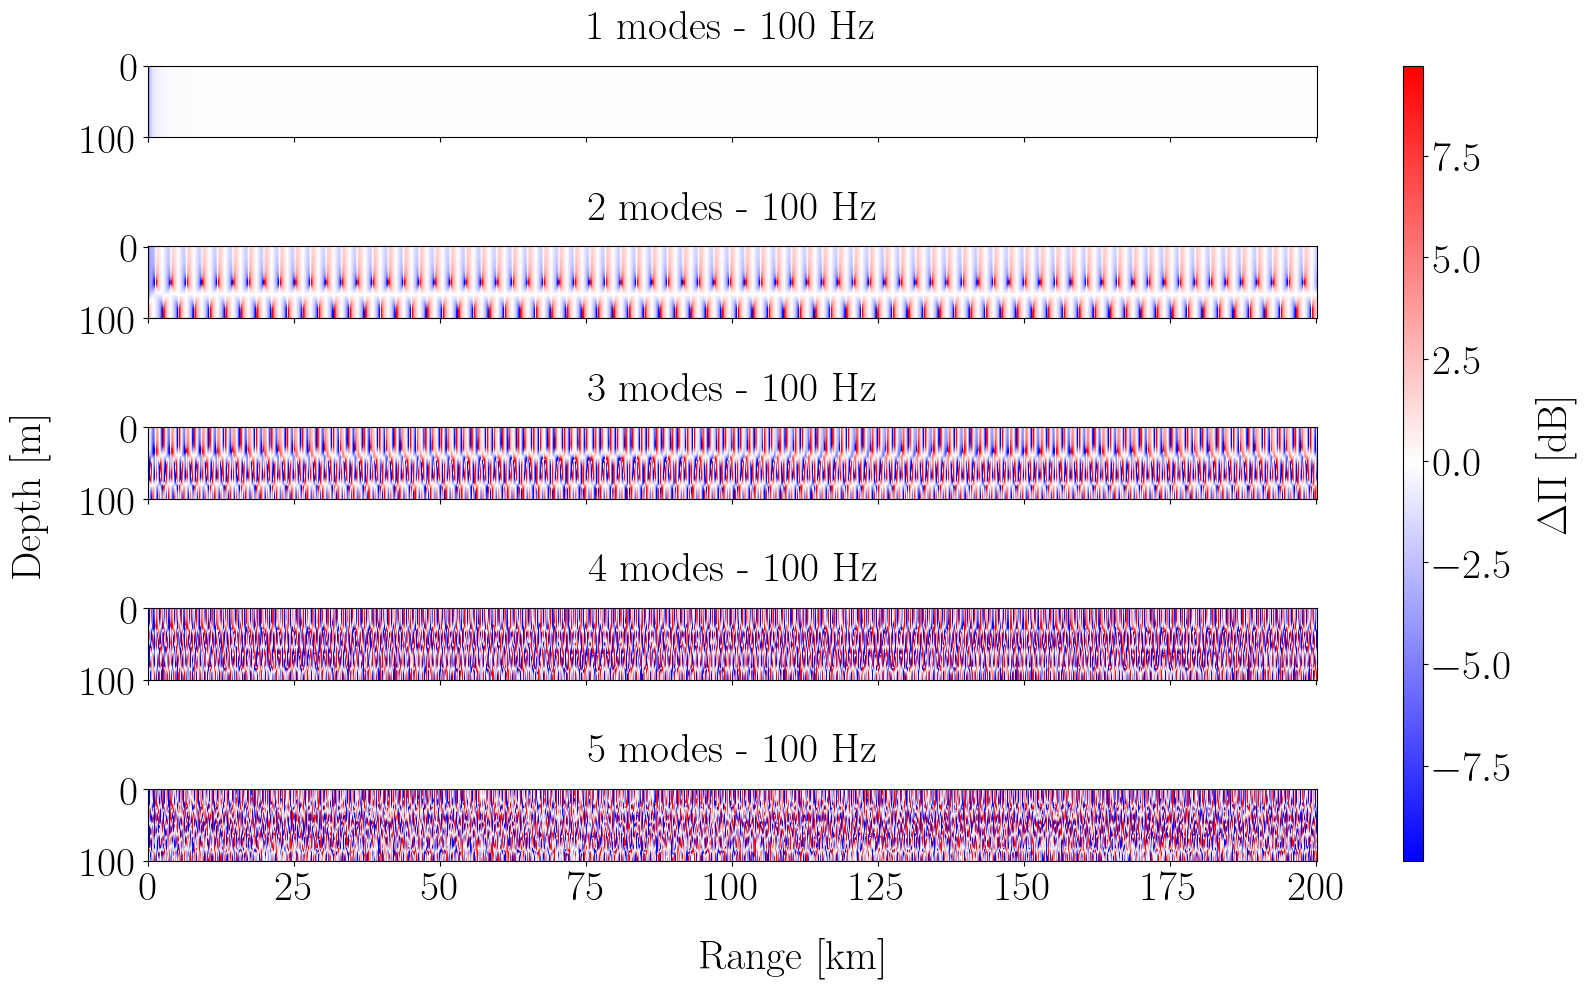

In [25]:
sfig = LargeFigure(size=(16, 10))

pi_diff = pi_bis - pi
vmin = np.percentile(pi_diff, 5)
vmax = np.percentile(pi_diff, 95)

fig, axs = plt.subplots(len(modes), sharex=True, sharey=True)
for i_m, m in enumerate(modes):

    # Plot at given number of modes
    title = f"{m} modes - {f0} Hz"

    im = axs[i_m].pcolormesh(
        rr * 1e-3,
        zz,
        pi_diff[i_m],
        vmin=vmin,
        vmax=vmax,
        cmap="bwr",
        rasterized=True,
    )
    axs[i_m].invert_yaxis()

    axs[i_m].set_title(title)



# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label(r"$\Delta \Pi$ [dB]")

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

In [26]:
pi_12_r_bis = []
for n in modes:
    ff, rr, zz, p_field1 = field(
        f=f0, z_src=z_antenna, z=z_src, r=r_grid1, depth=D, bottom_bc=bottom_bc, n=n
    )
    ff, _, _, p_field2 = field(
        f=f0, z_src=z_antenna, z=z_src, r=r_grid2, depth=D, bottom_bc=bottom_bc, n=n
    )
    p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
    p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
    pi_12_r_bis.append(p_field2 / p_field1)
pi_12_r_bis = np.array(pi_12_r_bis)
pi_12_r_bis = pi_12_r_bis.squeeze()  # nmodes  x nranges

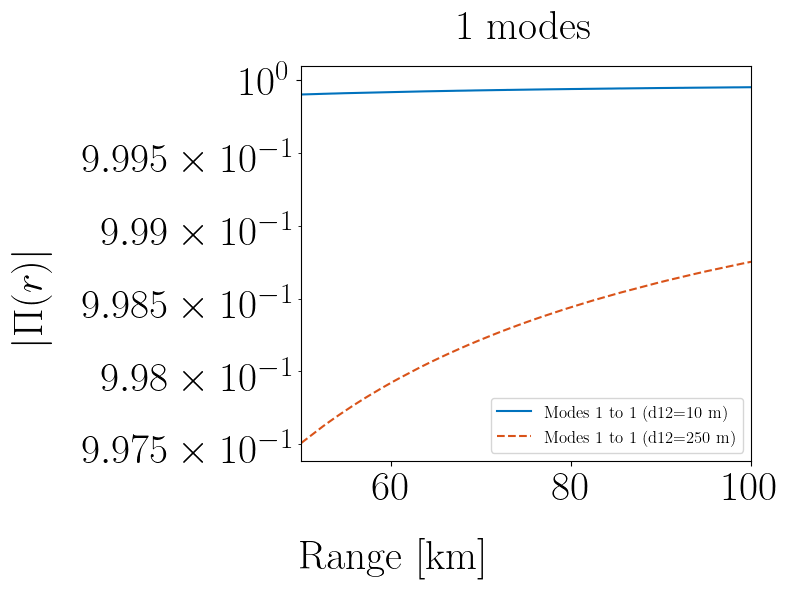

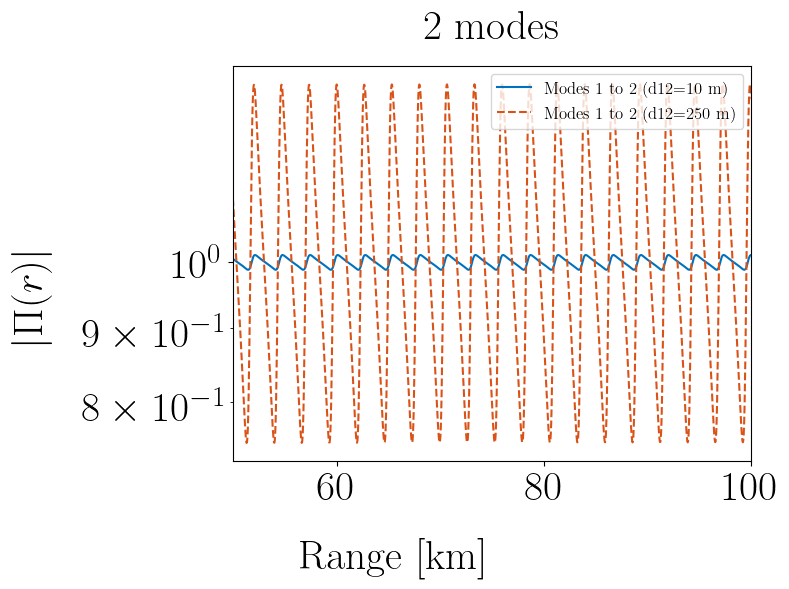

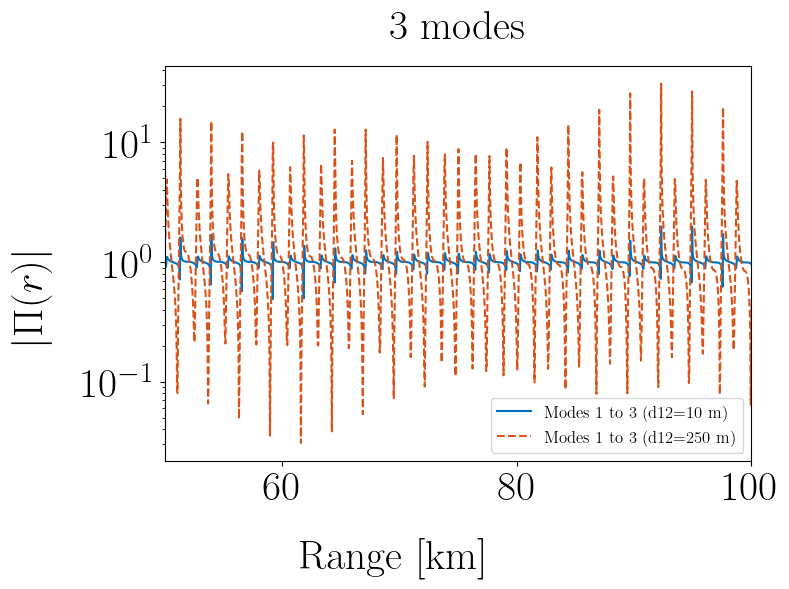

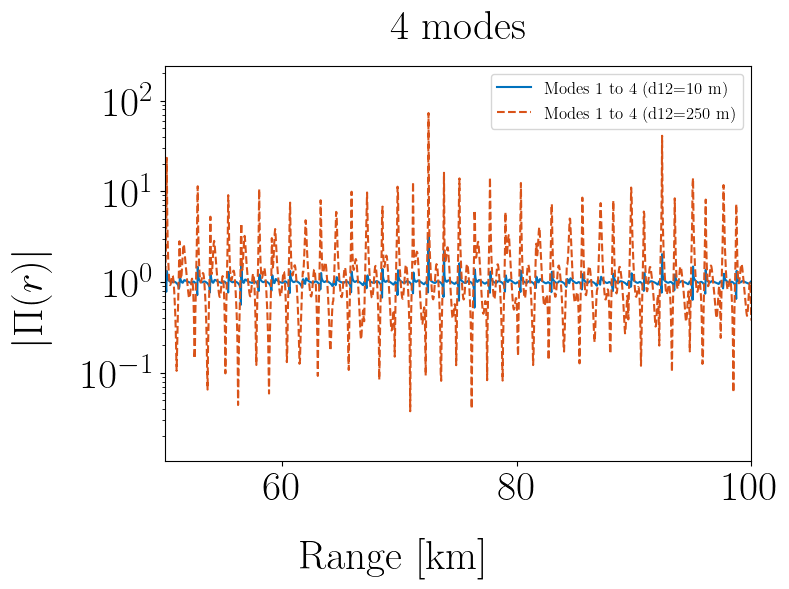

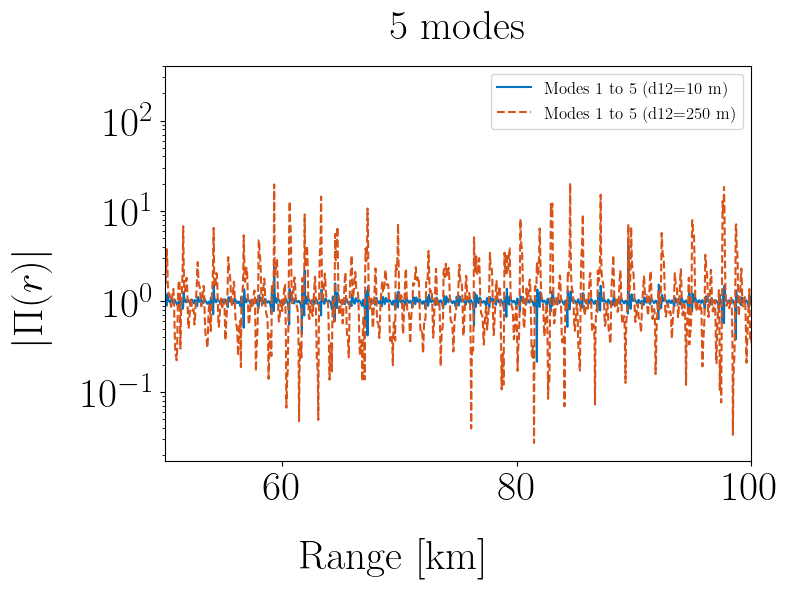

In [27]:
lfig = LargeFigure(size=(8, 6), legend_fontsize=12)

# Crop first km to avoid near-field effects
rmin_crop = 50 * 1e3
idx_rmin_crop = np.argmin(np.abs(r_grid - rmin_crop))
pi_12_r_crop = pi_12_r[..., idx_rmin_crop:]
pi_12_r_crop_bis = pi_12_r_bis[..., idx_rmin_crop:]
r_grid_crop = r_grid[idx_rmin_crop:]

# Plot TL for each number of modes
for i_m, m in enumerate(modes):
    fig, ax = plt.subplots(1, 1, sharex=True)

    # Plot Pi for each freq at given number of modes
    # pi = 20 * np.log10(np.abs(pi_12_r_crop[i_m]))
    # pi_bis = 20 * np.log10(np.abs(pi_12_r_crop_bis[i_m]))
    pi = np.abs(pi_12_r_crop[i_m])
    # pi = pi-1
    # k = d12_bis / d12
    # pi = k*(pi-1)
    pi_bis = np.abs(pi_12_r_crop_bis[i_m])
    # pi_bis = pi_bis-1
    # diff = pi_bis - pi
    # # diff = diff / k
    # print(pi_bis/pi)
    # ax.plot(
    #     r_grid_crop * 1e-3,
    #     diff,
    #     label=f"Modes 1 to {m} (d12={d12} m)",
    #     color=color(0),
    #     linestyle="-",
    #     zorder=1,
    # )

    # if m == 2:
    #     k_r1 = kr(1, f=f0, depth=D, bottom_bc=bottom_bc)
    #     k_r2 = kr(2, f=f0, depth=D, bottom_bc=bottom_bc)
    #     delta_k12 = k_r1 - k_r2
    #     th1 = np.cos(delta_k12 * (r_grid_crop + d12_bis)) * np.max(pi_bis)
    #     th2 = np.cos(delta_k12 * (r_grid_crop + d12)) * np.max(pi)
    #     ax.plot(
    #         r_grid_crop * 1e-3,
    #         np.cos(delta_k12 * d12_bis)*np.ones_like(r_grid_crop),
    #         label=r"$\cos(\Delta k_{12} r)$",
    #         color="k",
    #         linestyle="--",
    #     )

    #     print(np.cos(delta_k12 * d12_bis) / np.max(pi_bis) * 1 / d12_bis)

    ax.plot(
        r_grid_crop * 1e-3,
        pi,
        label=f"Modes 1 to {m} (d12={d12} m)",
        color=color(0),
        linestyle="-",
        zorder=1,
    )
    ax.plot(
        r_grid_crop * 1e-3,
        pi_bis,
        label=f"Modes 1 to {m} (d12={d12_bis} m)",
        color=color(1),
        linestyle="--",
        zorder=2,
    )

    title = f"{m} modes"
    ax.set_title(title)
    max_v = max(np.max(np.abs(pi)), np.max(np.abs(pi_bis))) * 1.2
    # ax.set_ylim([-max_v, max_v])
    ax.set_xlim([50, 100])
    ax.set_yscale('log')

    # Add legend
    ax.legend()

    fig.supxlabel("Range [km]")
    # fig.supylabel(r"20 log $\lvert \Pi(r) \rvert $")
    fig.supylabel(r"$\lvert \Pi(r) \rvert$")

In [28]:
# Comparaison avec un développement analytique asymptotique dans le cas M = 2 modes
from propa.ideal_waveguide import u_m
def Pi2_asympto_M2(r, d12, f, z_src, z_rcv, depth, bottom_bc):
    modes = np.array([1, 2])
    Am = u_m(modes, f, z_src, z_rcv, depth, bottom_bc=bottom_bc)

    delta_k12 = kr(1, f=f, depth=depth, bottom_bc=bottom_bc) - kr(2, f=f, depth=depth, bottom_bc=bottom_bc)
    a = Am[0]**2 + Am[1]**2 + 2*Am[0]*Am[1]*np.cos(delta_k12*(r+d12))
    b = Am[0]**2 + Am[1]**2 + 2*Am[0]*Am[1]*np.cos(delta_k12*r)
    Pi2_asympto = a/b
    return Pi2_asympto

Pi2_asympto = Pi2_asympto_M2(
    r=r_grid,
    d12=d12,
    f=f0,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)
Pi2_asympto_bis = Pi2_asympto_M2(
    r=r_grid,
    d12=d12_bis,
    f=f0,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)

# Two terms A and B
def Pi2_M2(r, d12, f, z_src, z_rcv, depth, bottom_bc):
    modes = np.array([1, 2])
    Am = u_m(modes, f, z_src, z_rcv, depth, bottom_bc=bottom_bc)
    Qtilde = (2 * np.pi) / g.rho_w**2

    def I1_r(r):
        I1 = Qtilde * (Am[0] ** 2 + Am[1] ** 2) / r
        return I1

    def I2_r(r):
        delta_k12 = kr(1, f=f, depth=depth, bottom_bc=bottom_bc) - kr(2, f=f, depth=depth, bottom_bc=bottom_bc)
        I2 = 2 * Qtilde * Am[0] * Am[1] * np.cos(delta_k12 * r) / r
        return I2
    A = I1_r(r + d12) / (I1_r(r) + I2_r(r))
    B = I2_r(r + d12) / (I1_r(r) + I2_r(r))
    Pi2 = A + B
    return Pi2, A, B

Pi2, A, B = Pi2_M2(
    r=r_grid,
    d12=d12,
    f=f0,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)
Pi2_bis, A_bis, B_bis = Pi2_M2(
    r=r_grid,
    d12=d12_bis,
    f=f0,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)

Text(0.02, 0.5, '$\\lvert \\Pi(r) \\rvert^2$')

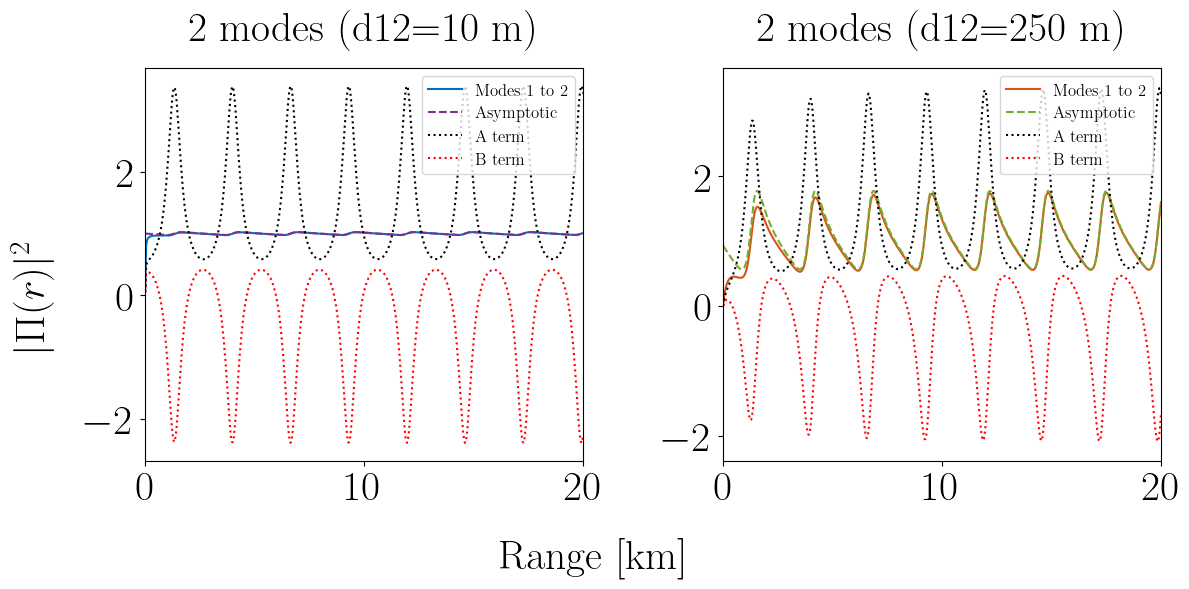

In [29]:
lfig = LargeFigure(size=(12, 6), legend_fontsize=12)

i_m = 1  # Index for m=2 modes
m = modes[i_m]
fig, axs = plt.subplots(1, 2, sharex=True)
ax1 = axs[0]
ax2 = axs[1]

pi = np.abs(pi_12_r[i_m])**2
pi_bis = np.abs(pi_12_r_bis[i_m])**2

ax1.plot(
    r_grid * 1e-3,
    pi,
    label=f"Modes 1 to {m}",
    color=color(0),
    linestyle="-",
    zorder=1,
)
ax2.plot(
    r_grid * 1e-3,
    pi_bis,
    label=f"Modes 1 to {m}",
    color=color(1),
    linestyle="-",
    zorder=2,
)
ax1.plot(
    r_grid * 1e-3,
    Pi2_asympto,
    label=f"Asymptotic",
    color=color(3),
    linestyle="--",
    zorder=1,
)
ax2.plot(
    r_grid * 1e-3,
    Pi2_asympto_bis,
    label=f"Asymptotic",
    color=color(4),
    linestyle="--",
    zorder=2,
)

# Plot A and B terms
ax1.plot(
    r_grid * 1e-3,
    A,
    label=f"A term",
    color="k",
    linestyle=":",
    zorder=1,
)
ax2.plot(
    r_grid * 1e-3,
    A_bis,
    label=f"A term",
    color="k",
    linestyle=":",
    zorder=2,
)
ax1.plot(
    r_grid * 1e-3,
    B,
    label=f"B term",
    color="r",
    linestyle=":",
    zorder=1,
)
ax2.plot(
    r_grid * 1e-3,
    B_bis,
    label=f"B term",
    color="r",
    linestyle=":",
    zorder=2,
)


title1 = f"{m} modes (d12={d12} m)"
ax1.set_title(title1)
title2 = f"{m} modes (d12={d12_bis} m)"
ax2.set_title(title2)

max_v = max(np.max(np.abs(pi)), np.max(np.abs(pi_bis))) * 1.2
# ax.set_ylim([-max_v, max_v])
ax1.set_xlim([0, 20])
ax2.set_xlim([0, 20])

# Add legend
ax1.legend()
ax2.legend()

fig.supxlabel("Range [km]")
# fig.supylabel(r"20 log $\lvert \Pi(r) \rvert $")
fig.supylabel(r"$\lvert \Pi(r) \rvert^2$")

In [30]:
# Comparaison avec un développement analytique asymptotique dans le cas M = 2 modes

Pi2_asympto = Pi2_asympto_M2(
    r=r_grid_crop,
    d12=d12,
    f=f0,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)
Pi2_asympto_bis = Pi2_asympto_M2(
    r=r_grid_crop,
    d12=d12_bis,
    f=f0,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)

Pi2, A, B = Pi2_M2(
    r=r_grid_crop,
    d12=d12,
    f=f0,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)
Pi2_bis, A_bis, B_bis = Pi2_M2(
    r=r_grid_crop,
    d12=d12_bis,
    f=f0,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)

fft_Pi2 = rfft(Pi2-np.mean(Pi2))
fft_Pi2_bis = rfft(Pi2_bis - np.mean(Pi2_bis))
fft_Pi2_asympto = rfft(Pi2_asympto - np.mean(Pi2_asympto))
fft_Pi2_asympto_bis = rfft(Pi2_asympto_bis - np.mean(Pi2_asympto_bis))

dr = r_grid_crop[1] - r_grid_crop[0]
k_r = rfftfreq(pi_12_r_crop.shape[-1], d=dr)

Text(0.02, 0.5, '$\\lvert \\Pi(r) \\rvert^2$')

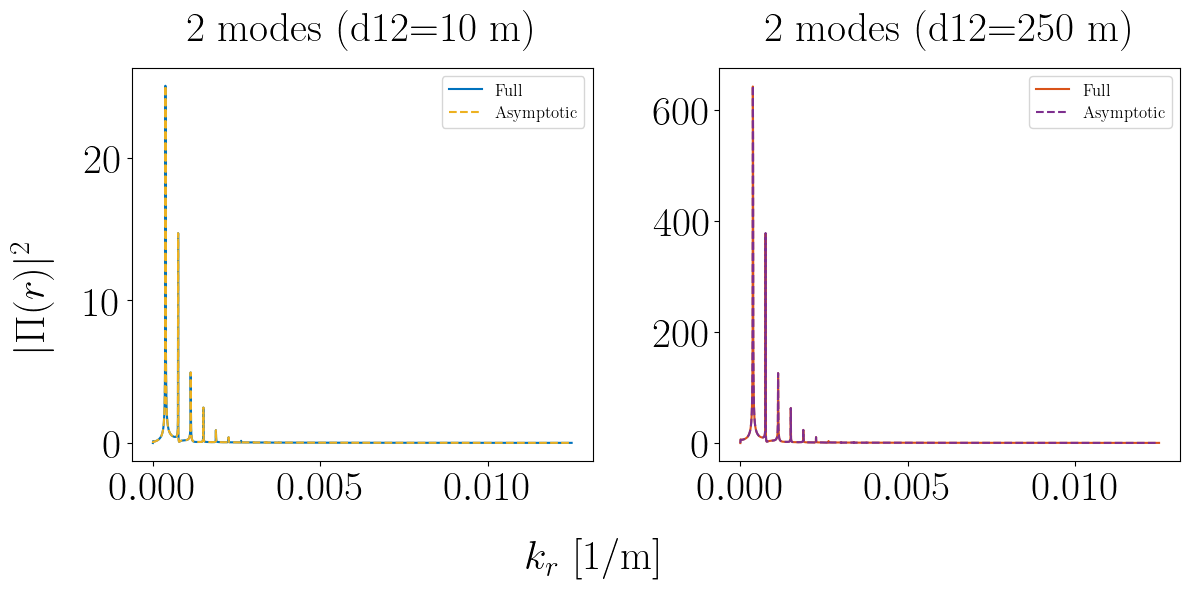

In [31]:
# lfig = LargeFigure(size=(12, 6), legend_fontsize=12)

i_m = 1  # Index for m=2 modes
m = modes[i_m]
fig, axs = plt.subplots(1, 2, sharey=False)
ax1 = axs[0]
ax2 = axs[1]

# pi = np.abs(pi_12_r[i_m]) ** 2
# pi_bis = np.abs(pi_12_r_bis[i_m]) ** 2

ax1.plot(
    k_r,
    np.abs(fft_Pi2),
    label=f"Full",
    color=color(0),
    linestyle="-",
    zorder=1,
)
ax2.plot(
    k_r,
    np.abs(fft_Pi2_bis),
    label=f"Full",
    color=color(1),
    linestyle="-",
    zorder=2,
)

ax1.plot(
    k_r,
    np.abs(fft_Pi2_asympto),
    label=f"Asymptotic",
    color=color(2),
    linestyle="--",
    zorder=1,
)
ax2.plot(
    k_r,
    np.abs(fft_Pi2_asympto_bis),
    label=f"Asymptotic",
    color=color(3),
    linestyle="--",
    zorder=2,
)

title1 = f"{m} modes (d12={d12} m)"
ax1.set_title(title1)
title2 = f"{m} modes (d12={d12_bis} m)"
ax2.set_title(title2)

# max_v = max(np.max(np.abs(pi)), np.max(np.abs(pi_bis))) * 1.2
# ax.set_ylim([-max_v, max_v])
# ax1.set_xlim([0, 20])
# ax2.set_xlim([-0.0001, 0.003])

# Add legend
ax1.legend()
ax2.legend()

fig.supxlabel(r"$k_r$ [1/m]")
# fig.supylabel(r"20 log $\lvert \Pi(r) \rvert $")
fig.supylabel(r"$\lvert \Pi(r) \rvert^2$")

In [32]:
pi_12_r_crop_abs = np.abs(pi_12_r_crop)
pi_12_r_crop_phase = np.angle(pi_12_r_crop)
# Bis
pi_12_r_crop_abs_bis = np.abs(pi_12_r_crop_bis)
pi_12_r_crop_phase_bis = np.angle(pi_12_r_crop_bis)

# Remove mean
pi_12_r_crop_abs -= np.mean(pi_12_r_crop_abs, axis=-1, keepdims=True)
pi_12_r_crop_phase -= np.mean(pi_12_r_crop_phase, axis=-1, keepdims=True)
# Bis
pi_12_r_crop_abs_bis -= np.mean(pi_12_r_crop_abs_bis, axis=-1, keepdims=True)
pi_12_r_crop_phase_bis -= np.mean(pi_12_r_crop_phase_bis, axis=-1, keepdims=True)

# Apply FFT along range axis
pi_12_r_abs_fft = rfft(pi_12_r_crop_abs, axis=-1)
pi_12_r_phase_fft = rfft(pi_12_r_crop_phase, axis=-1)
# Bis
pi_12_r_abs_fft_bis = rfft(pi_12_r_crop_abs_bis, axis=-1)
pi_12_r_phase_fft_bis = rfft(pi_12_r_crop_phase_bis, axis=-1)

# Compute k_r
dr = r_grid_crop[1] - r_grid_crop[0]
k_r = rfftfreq(pi_12_r_crop.shape[-1], d=dr)

2 : delta_k (m=1, n=2) =  0.0004 1/m
3 : delta_k (m=1, n=2) =  0.0004 1/m
3 : delta_k (m=1, n=3) =  0.0011 1/m
3 : delta_k (m=2, n=3) =  0.0008 1/m
4 : delta_k (m=1, n=2) =  0.0004 1/m
4 : delta_k (m=1, n=3) =  0.0011 1/m
4 : delta_k (m=1, n=4) =  0.0023 1/m
4 : delta_k (m=2, n=3) =  0.0008 1/m
4 : delta_k (m=2, n=4) =  0.0019 1/m
4 : delta_k (m=3, n=4) =  0.0012 1/m
5 : delta_k (m=1, n=2) =  0.0004 1/m
5 : delta_k (m=1, n=3) =  0.0011 1/m
5 : delta_k (m=1, n=4) =  0.0023 1/m
5 : delta_k (m=1, n=5) =  0.0039 1/m
5 : delta_k (m=2, n=3) =  0.0008 1/m
5 : delta_k (m=2, n=4) =  0.0019 1/m
5 : delta_k (m=2, n=5) =  0.0035 1/m
5 : delta_k (m=3, n=4) =  0.0012 1/m
5 : delta_k (m=3, n=5) =  0.0027 1/m
5 : delta_k (m=4, n=5) =  0.0016 1/m


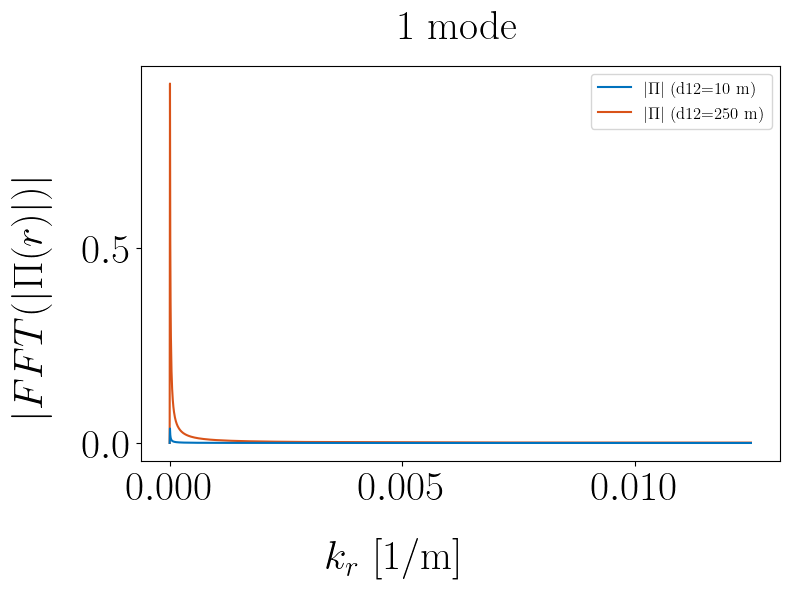

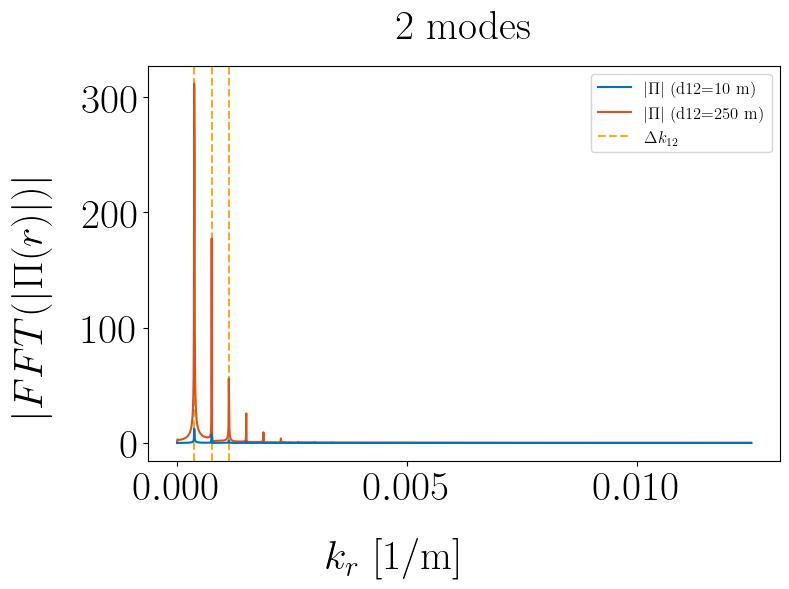

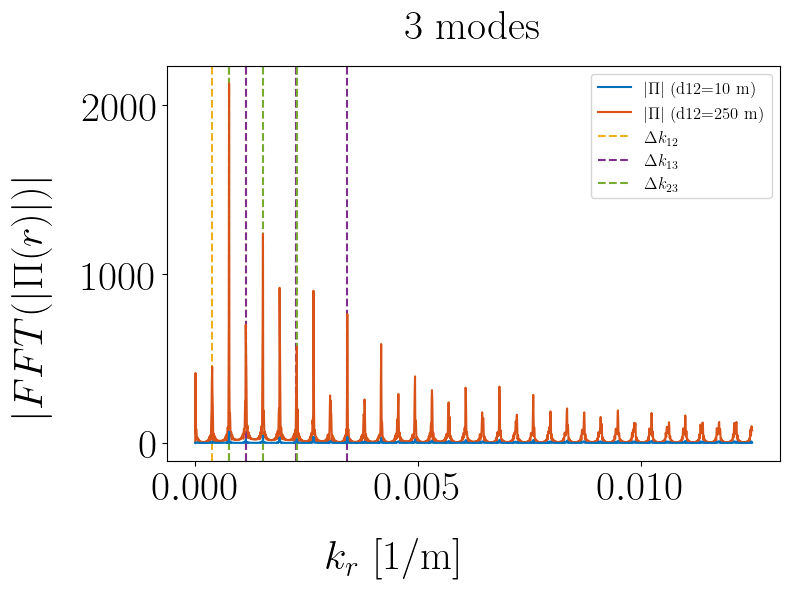

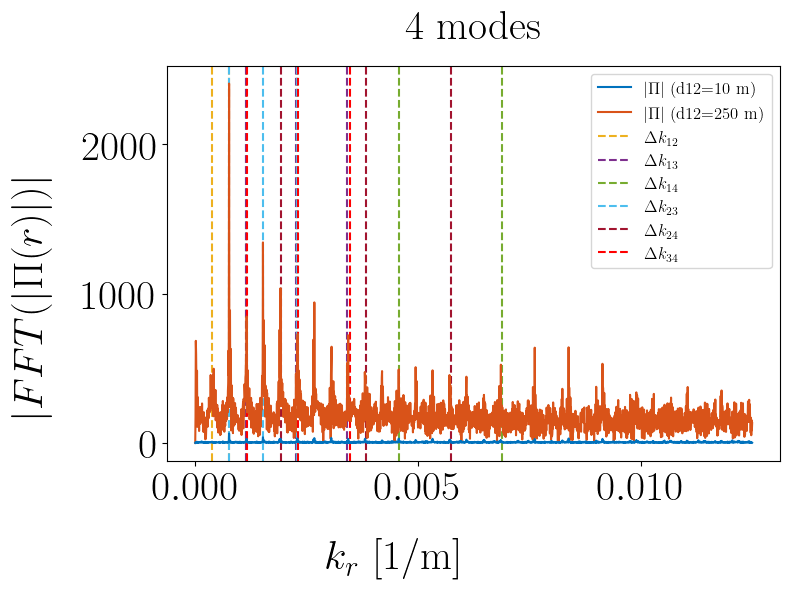

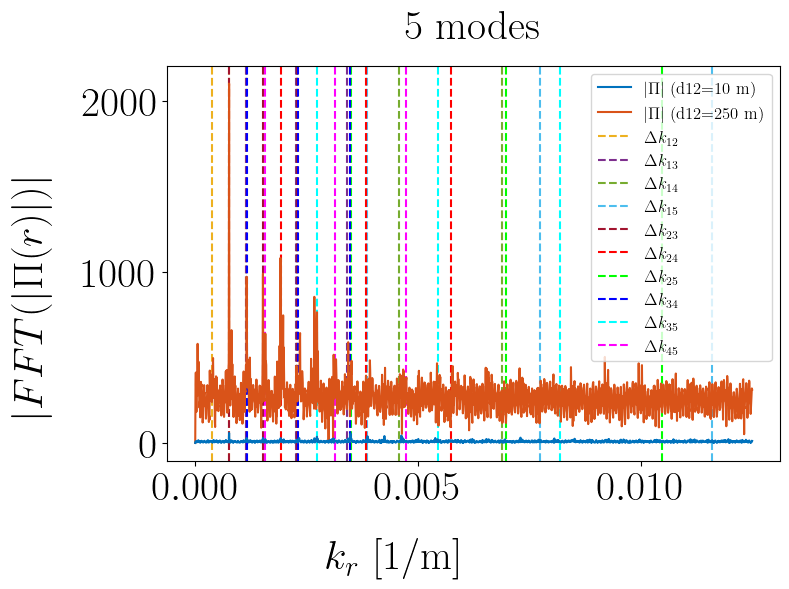

In [33]:
lfig = LargeFigure(size=(8, 6), legend_fontsize=12)

abcd_labels = ["a", "b", "c", "d", "e", "f"]
for i_m, m in enumerate(modes):

    fig, ax = plt.subplots(1, 1)

    if m == 1:
        title = "1 mode"
    else:
        title = f"{m} modes"

    # Plot TL I
    ax.plot(
        k_r,
        np.abs(pi_12_r_abs_fft[i_m]),  # Select freq index 2 (100 Hz)
        label=r"$\lvert \Pi \rvert$" + f" (d12={d12} m)",
        color=color(0),
        linestyle="-",
        zorder=2,
    )
    ax.plot(
        k_r,
        np.abs(pi_12_r_abs_fft_bis[i_m]),  # Select freq index 2 (100 Hz)
        label=r"$\lvert \Pi  \rvert$" + f" (d12={d12_bis} m)",
        color=color(1),
        linestyle="-",
        zorder=1,
    )

    ax.set_title(title)

    # if m <= 3:
    m_max_plot = min(m, 5)
    col_count = 0
    for mm in range(1, m_max_plot + 1):
        if mm + 1 < m_max_plot + 1:
            for nn in range(mm + 1, m_max_plot + 1):
                k_rm = kr(mm, f=f0, depth=D, bottom_bc=bottom_bc)
                k_rn = kr(nn, f=f0, depth=D, bottom_bc=bottom_bc)
                delta_kmn = k_rm - k_rn
                delta_kmn /= 2 * np.pi
                # l_delta = 2 * np.pi / delta_kmn
                # print(f"L_mn (m={m}, n={n}) =  {l_delta:.2f} m")
                print(f"{m} : delta_k (m={mm}, n={nn}) =  {delta_kmn:.4f} 1/m")

                for h in range(1, 4):
                    if h > 1:
                        # label = rf"${{{h}}}\Delta k_{{{mm} {nn}}}$"
                        label = None
                    else:
                        label = rf"$\Delta k_{{{mm} {nn}}}$"
                    ax.axvline(
                        delta_kmn * h,
                        color=color(col_count+2),
                        linestyle="--",
                        label=label,
                        zorder=0,
                    )
                col_count += 1

    # ax.legend(ncols=(col_count + 1)//2)
    ax.legend()
    # ax.set_xlim([0, 0.003])

    fig.supxlabel(r"$k_r$ [1/m]")
    fig.supylabel(r"$\lvert FFT(\lvert \Pi(r) \rvert) \rvert$")

3
18.75


C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\ideal_waveguide.py:115: RuntimeWarning: invalid value encountered in sqrt
  kr_m = np.sqrt(k**2 - kz_m**2)


Text(0.02, 0.5, '$\\Phi_{mn}$ [rad]')

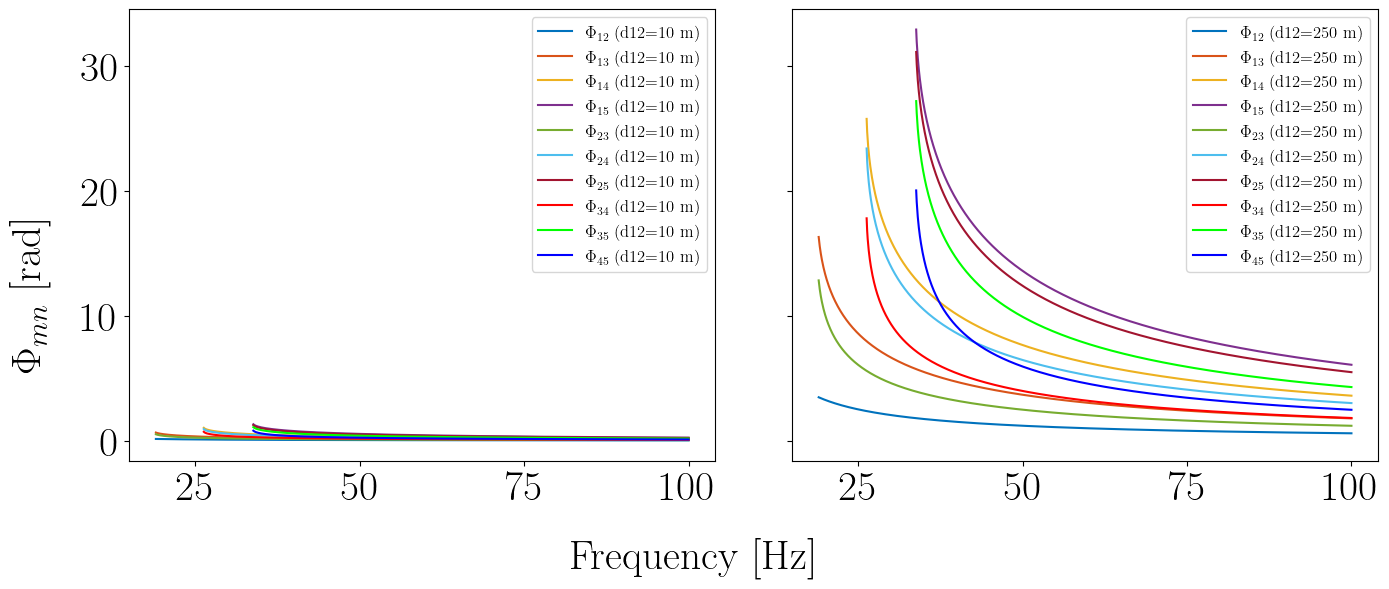

In [34]:
# Etude du déphasage Phimn = delta_kmn * d12 en fonction de la fréquence
lfig = LargeFigure(size=(14, 6), legend_fontsize=12)

freq = np.linspace(19, 100, 1001)
print(nb_propagating_modes(f=np.min(freq), c=g.c0, depth=D, bottom_bc=bottom_bc))
fmin_m3 = (3 - 1/2) * g.c0 / (2 * D)
print(fmin_m3)
fig, axs = plt.subplots(1, 2, sharey=True)
ax1 = axs[0]
ax2 = axs[1]

m_max_plot = 5
col_count = 0
for mm in range(1, m_max_plot + 1):
    for nn in range(mm + 1, m_max_plot + 1):
        k_rm = kr(mm, f=freq, depth=D, bottom_bc=bottom_bc)
        k_rn = kr(nn, f=freq, depth=D, bottom_bc=bottom_bc)
        delta_kmn = k_rm - k_rn
        phi_mn = delta_kmn * d12
        # phi_mn = phi_mn % (2 * np.pi)
        phi_mn_bis = delta_kmn * d12_bis 
        # phi_mn_bis = phi_mn_bis % (2 * np.pi)
        ax1.plot(
            freq, 
            phi_mn, 
            label=rf"$\Phi_{{{mm} {nn}}}$ (d12={d12} m)",
            color=color(col_count),
        )
        ax2.plot(
            freq, 
            phi_mn_bis, 
            label=rf"$\Phi_{{{mm} {nn}}}$ (d12={d12_bis} m)",
            color=color(col_count),
        )
        col_count += 1

ax1.legend()
ax2.legend()
fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$\Phi_{mn}$ [rad]")

# Set graduation to 0 to 2pi
# ax1.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
# ax1.set_yticklabels([r"$0$", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])


1
11.25


[Text(0, 0.0, '$0$'),
 Text(0, 1.5707963267948966, '$\\frac{\\pi}{2}$'),
 Text(0, 3.141592653589793, '$\\pi$'),
 Text(0, 4.71238898038469, '$\\frac{3\\pi}{2}$'),
 Text(0, 6.283185307179586, '$2\\pi$')]

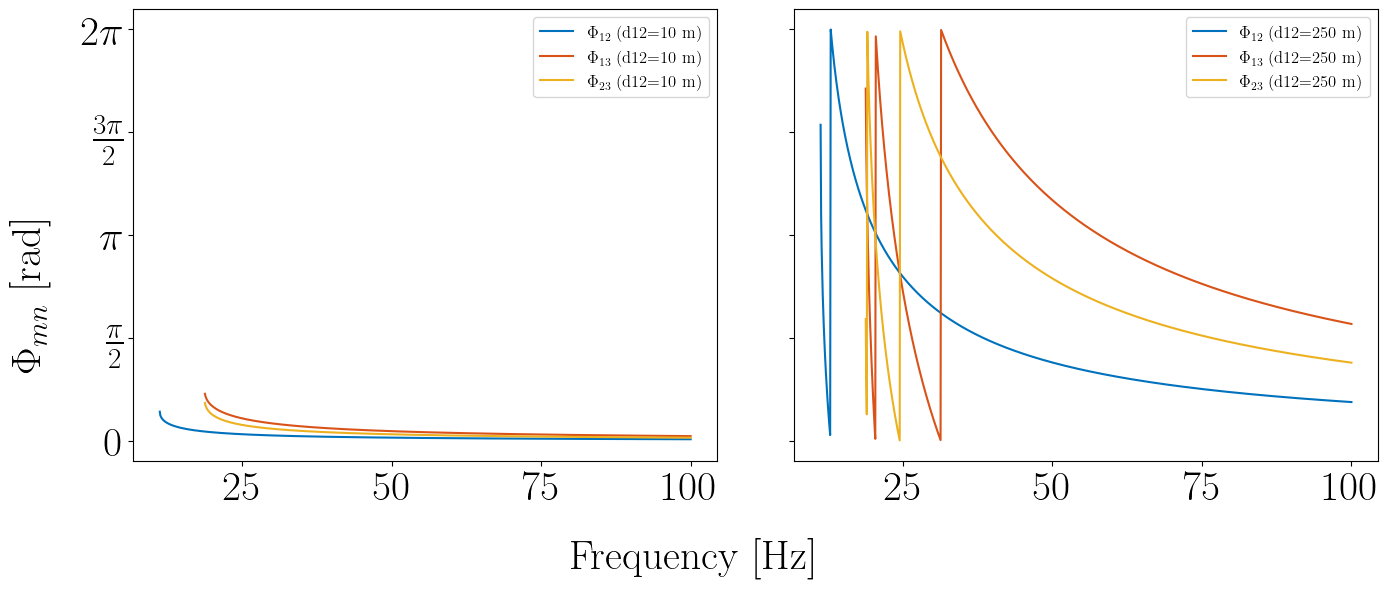

In [35]:
# Etude du déphasage Phimn = delta_kmn * d12 en fonction de la fréquence
lfig = LargeFigure(size=(14, 6), legend_fontsize=12)

freq = np.linspace(11.25, 100, 1001)
print(nb_propagating_modes(f=np.min(freq), c=g.c0, depth=D, bottom_bc=bottom_bc))
fmin_m2 = (2 - 1 / 2) * g.c0 / (2 * D)
print(fmin_m2)
fig, axs = plt.subplots(1, 2, sharey=True)
ax1 = axs[0]
ax2 = axs[1]

m_max_plot = 3
col_count = 0
for mm in range(1, m_max_plot + 1):
    for nn in range(mm + 1, m_max_plot + 1):
        k_rm = kr(mm, f=freq, depth=D, bottom_bc=bottom_bc)
        k_rn = kr(nn, f=freq, depth=D, bottom_bc=bottom_bc)
        delta_kmn = k_rm - k_rn
        phi_mn = delta_kmn * d12
        phi_mn = phi_mn % (2 * np.pi)
        phi_mn_bis = delta_kmn * d12_bis
        phi_mn_bis = phi_mn_bis % (2 * np.pi)
        ax1.plot(
            freq,
            phi_mn,
            label=rf"$\Phi_{{{mm} {nn}}}$ (d12={d12} m)",
            color=color(col_count),
        )
        ax2.plot(
            freq,
            phi_mn_bis,
            label=rf"$\Phi_{{{mm} {nn}}}$ (d12={d12_bis} m)",
            color=color(col_count),
        )
        col_count += 1

ax1.legend()
ax2.legend()
fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$\Phi_{mn}$ [rad]")

# Set graduation to 0 to 2pi
ax1.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax1.set_yticklabels([r"$0$", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])

# ax2.set_xlim([0,25])

In [36]:
mm = 1
nn = 2
a = ((mm - 1/2) * np.pi / D)**2
b = ((nn - 1 / 2) * np.pi / D) ** 2

def fx(a, b, x):
    return np.sqrt(x - a) - np.sqrt(x - b)

def fx_inv(a, b, y):
    x = ( a**2 - 2*a*b + b**2 + 2*a*y**2 + 2*b*y**2 + y**4 ) / (4*y**2)
    return x

k2 = fx_inv(a, b, y=2 * np.pi / d12)
flim = np.sqrt(k2) * g.c0 / (2 * np.pi)
print(flim)

75.4682259298574


(0.0, 300.0)

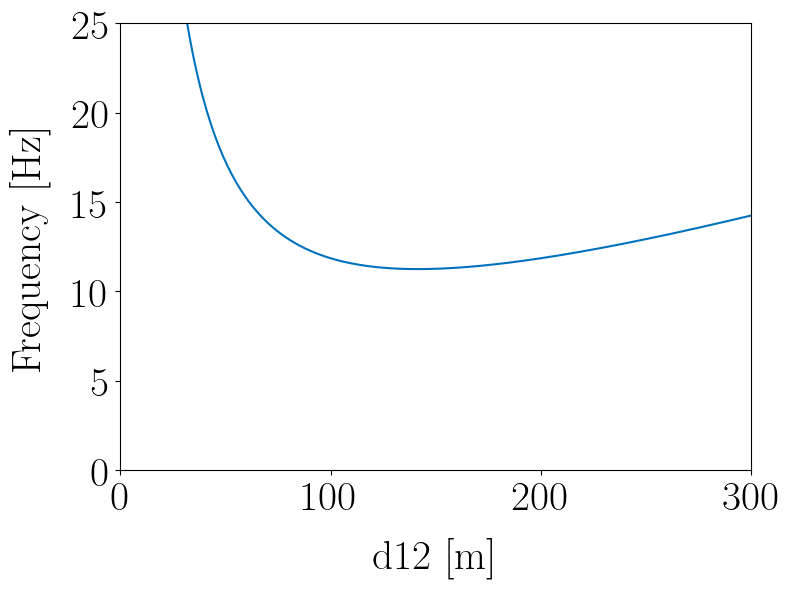

In [37]:
d = np.linspace(1, 1000, 1000)
y = 2 * np.pi / d
x = fx_inv(a, b, y=y)
freq_d = np.sqrt(x) * g.c0 / (2 * np.pi)
lfig = LargeFigure(size=(8, 6), legend_fontsize=12)

fig, ax = plt.subplots(1, 1)
ax.plot(
    d,
    freq_d,
    label=rf"Limit frequency for $\Delta \phi_{{{mm} {nn}}} = 2\pi$",
    color=color(0),
)
ax.set_xlabel("d12 [m]")
ax.set_ylabel("Frequency [Hz]")
ax.set_ylim([0, 25])
ax.set_xlim([0, 300])

In [38]:
kzm = (mm - 1/2) * np.pi / D
kzn = (nn - 1 / 2) * np.pi / D

freq = np.linspace(0.1, 100, 1000)
alpha_mn = 2 * (kzm**2 + kzn**2)
beta_mn = (kzm**2 - kzn**2)**2
k = 2 * np.pi * freq / g.c0
Delta = (alpha_mn/4 - k**2)**2 - beta_mn/4 

a_G = 1
b_G = -1 / 2 * alpha_mn
c_G = 1 / 2 * (kzm**4 + kzn**4)
Delta_G = b_G**2 - 4 * a_G * c_G
print(Delta_G)

def g_k(k, alpha_mn, kzm, kzn):
    return k**4 - (kzm**2 + kzn**2) * k**2 + kzm**2 * kzn**2

-3.896363641360096e-06


(-1e-06, 3e-06)

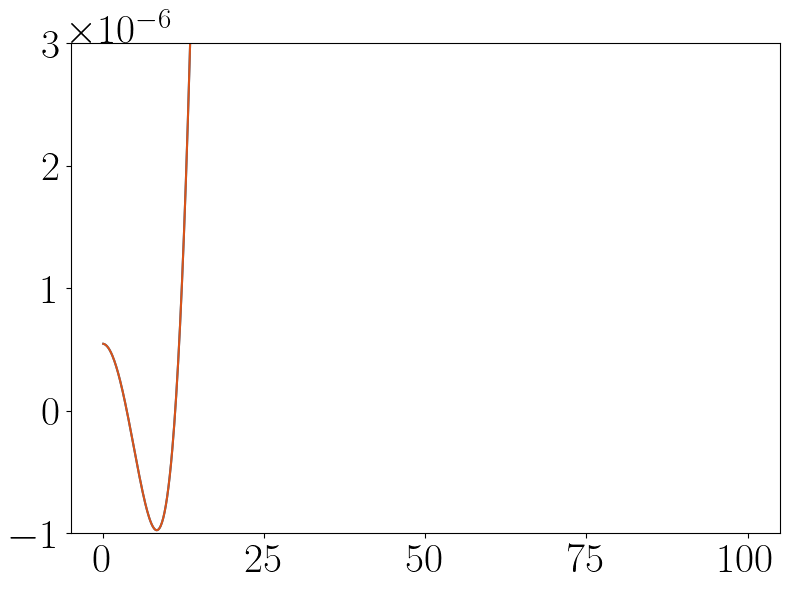

In [39]:
a_L = np.pi**2 / d12**2
b_L = alpha_mn / 4 - k**2
c_L = d12**2 * beta_mn / (16 * np.pi**2)
Delta_L = b_L**2 - 4 * a_L * c_L

fig, ax = plt.subplots(1, 1)
ax.plot(
    freq,
    g_k(k, alpha_mn, kzm, kzn),
    label=rf"$\Delta$ (m={mm}, n={nn})",
    color=color(0),
)
ax.plot(
    freq,
    Delta_L,
    label=rf"$\Delta_L$ (m={mm}, n={nn})",
    color=color(1),
)
ax.set_ylim([-1e-6, 3*1e-6])

In [40]:
k0 = 2 * np.pi * f0 / g.c0

a_L = np.pi**2 / d12**2
b_L = alpha_mn / 4 - k**2
c_L = d12**2 * beta_mn / (16 * np.pi**2)
Delta_L = b_L**2 - 4 * a_L * c_L

print(Delta_L)


[ 5.47493239e-07  5.46194912e-07  5.44032267e-07  5.41007150e-07
  5.37122146e-07  5.32380581e-07  5.26786519e-07  5.20344762e-07
  5.13060852e-07  5.04941069e-07  4.95992432e-07  4.86222699e-07
  4.75640368e-07  4.64254674e-07  4.52075591e-07  4.39113835e-07
  4.25380856e-07  4.10888846e-07  3.95650735e-07  3.79680193e-07
  3.62991627e-07  3.45600184e-07  3.27521749e-07  3.08772948e-07
  2.89371142e-07  2.69334436e-07  2.48681669e-07  2.27432422e-07
  2.05607013e-07  1.83226500e-07  1.60312680e-07  1.36888088e-07
  1.12975999e-07  8.86004249e-08  6.37861185e-08  3.85585704e-08
  1.29440106e-08 -1.30305926e-08 -3.93375315e-08 -6.59483598e-08
 -9.28338923e-08 -1.19964205e-07 -1.47308635e-07 -1.74835780e-07
 -2.02513500e-07 -2.30308915e-07 -2.58188408e-07 -2.86117619e-07
 -3.14061454e-07 -3.41984077e-07 -3.69848915e-07 -3.97618655e-07
 -4.25255245e-07 -4.52719894e-07 -4.79973074e-07 -5.06974516e-07
 -5.33683214e-07 -5.60057420e-07 -5.86054651e-07 -6.11631683e-07
 -6.36744552e-07 -6.61348

##### Bilan 

Le distance intercapteur, notée ici $d_{12}$, modifie l'amplitude de chacune des harmoniques du signal $\Pi_{12}(r)$

# Comparaison plusieurs fréquences

In [41]:
nrgrid = 10000
rc = 20 * 1e3
delta_r = 1 * 1e3
rmin = (rc - delta_r / 2)
rmax = (rc + delta_r / 2)
r_grid = np.linspace(rmin, rmax, nrgrid)
colors = r_grid * 1e-3

Text(0.5, 1.0, '$d_{12}$ = {100} m, $f_1$ = 15 Hz, $f_2$ = 16 Hz')

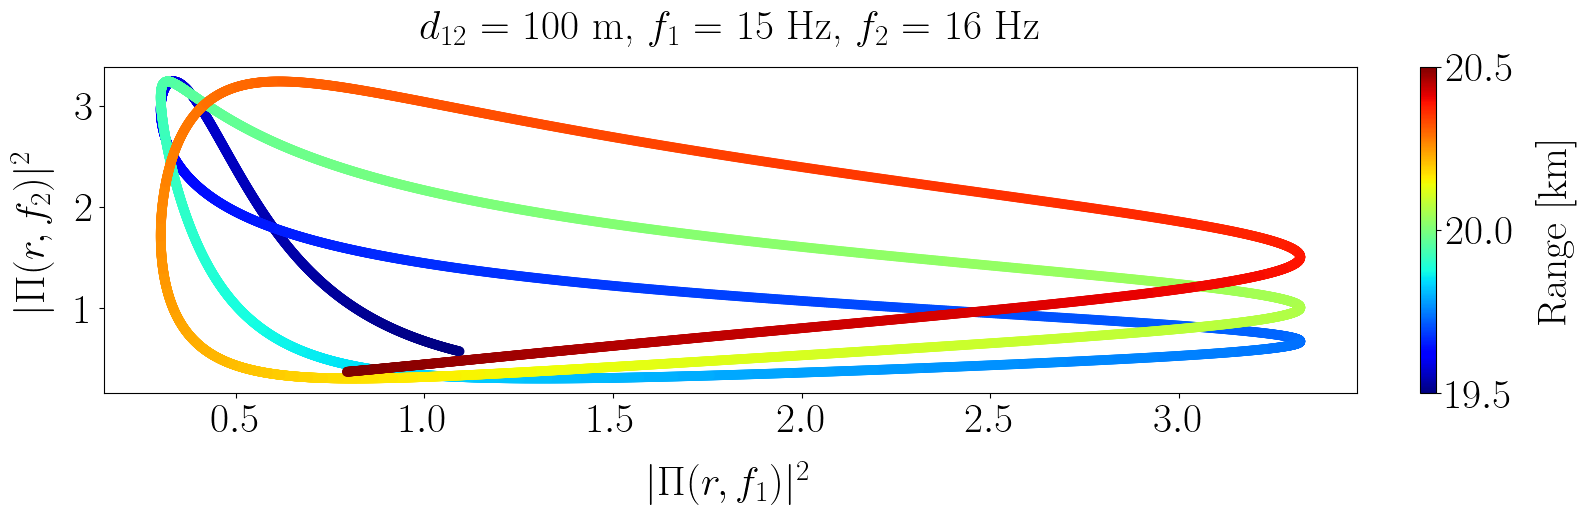

In [61]:
# Comparaison avec un développement analytique asymptotique dans le cas M = 2 modes
d = [100]
f1 = 15
f2 = 16

lfig = LargeFigure()
plt.figure()
for d12 in d:
    Pi_f1 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f1,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_f2 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f2,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )

    # plt.plot(Pi_f1, Pi_f2, label=f"d12 = {d12} m", linestyle="-", color="k")
    plt.scatter(Pi_f1, Pi_f2, c=colors, cmap="jet", linestyle="-", zorder=10)


# plt.legend()
plt.xlabel(r"$\lvert \Pi(r, f_1) \rvert^2$")
plt.ylabel(r"$\lvert \Pi(r, f_2) \rvert^2$")
plt.colorbar(label="Range [km]")
plt.title(rf"$d_{{12}}$ = {{{d12}}} m, $f_1$ = {f1} Hz, $f_2$ = {f2} Hz")

Text(0.5, 0.92, '$d_{12}$ = {100} m\n  $f_1$ = 15 Hz, $f_2$ = 16 Hz, $f_3$ = 17 Hz')

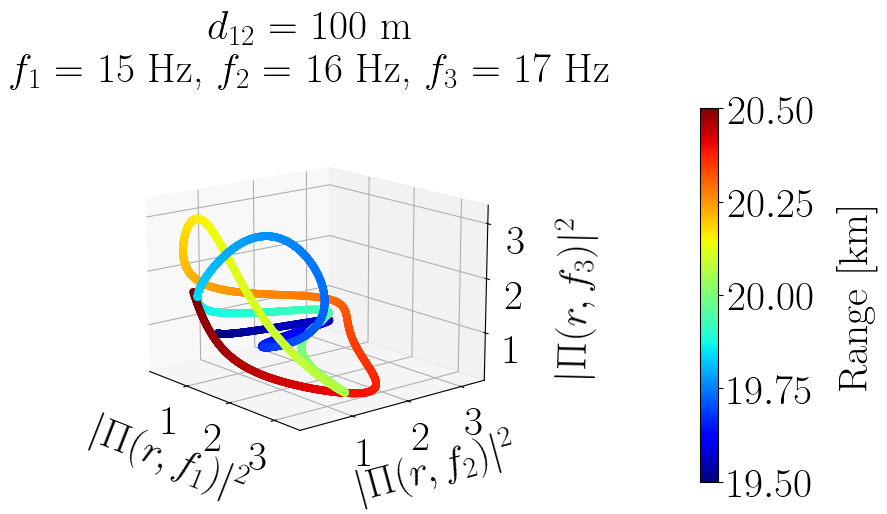

In [66]:
# Comparaison avec un développement analytique asymptotique dans le cas M = 2 modes
f1 = 15
f2 = 16
f3 = 17

# Create figure and 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for d12 in d:
    Pi_f1 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f1,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_f2 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f2,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_f3 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f3,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )

    # Scatter plot with color mapping
    sc = ax.scatter3D(Pi_f1, Pi_f2, Pi_f3, c=colors, cmap="jet")
    plt.colorbar(sc, ax=ax, label="Range [km]", pad=0.15)

    # ax.plot(Pi_f1, Pi_f2, Pi_f3)

# Customization

ax.set_xlabel(r"$\lvert \Pi(r, f_1) \rvert^2$")
ax.set_ylabel(r"$\lvert \Pi(r, f_2) \rvert^2$")
ax.set_zlabel(r"$\lvert \Pi(r, f_3) \rvert^2$")
# ax.zaxis.labelpad=-0.7 # <- change the value here
ax.view_init(elev=15, azim=-40)  # Adjust view angle
plt.title(rf"$d_{{12}}$ = {{{d12}}} m" + "\n" + rf"  $f_1$ = {f1} Hz, $f_2$ = {f2} Hz, $f_3$ = {f3} Hz")

Text(0.5, 0.92, 'PCA (nc=3) of $\\lvert \\Pi(r, f) \\rvert^2$\n$f_1$ = 15 Hz, $f_2$ = 16 Hz, $f_3$ = 17 Hz\n$d_{12}$ = {100} m')

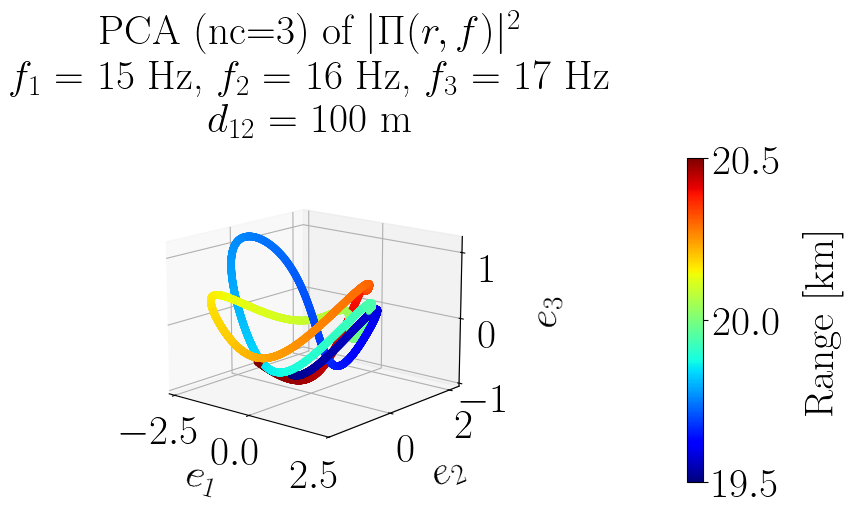

In [78]:
from sklearn.decomposition import PCA

data = np.array([Pi_f1, Pi_f2, Pi_f3]).T
X = PCA(n_components=3).fit_transform(data)


# Create figure and 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Scatter plot with color mapping
sc = ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], c=colors, cmap="jet")
plt.colorbar(sc, ax=ax, label="Range [km]", pad=0.15)

# Customization
ax.view_init(elev=15, azim=-50)  # Adjust view angle

ax.set_xlabel(r"$e_1$")
ax.set_ylabel(r"$e_2$")
ax.set_zlabel(r"$e_3$")
plt.title(rf"PCA (nc=3) of $\lvert \Pi(r, f) \rvert^2$"+ "\n" + fr"$f_1$ = {f1} Hz, $f_2$ = {f2} Hz, $f_3$ = {f3} Hz" + "\n" + rf"$d_{{12}}$ = {{{d12}}} m")

Text(0.5, 1.0, 'PCA (nc=2) of $\\lvert \\Pi(r, f) \\rvert^2$\n$f_1$ = 15 Hz, $f_2$ = 16 Hz, $f_3$ = 17 Hz\n$d_{12}$ = {100} m')

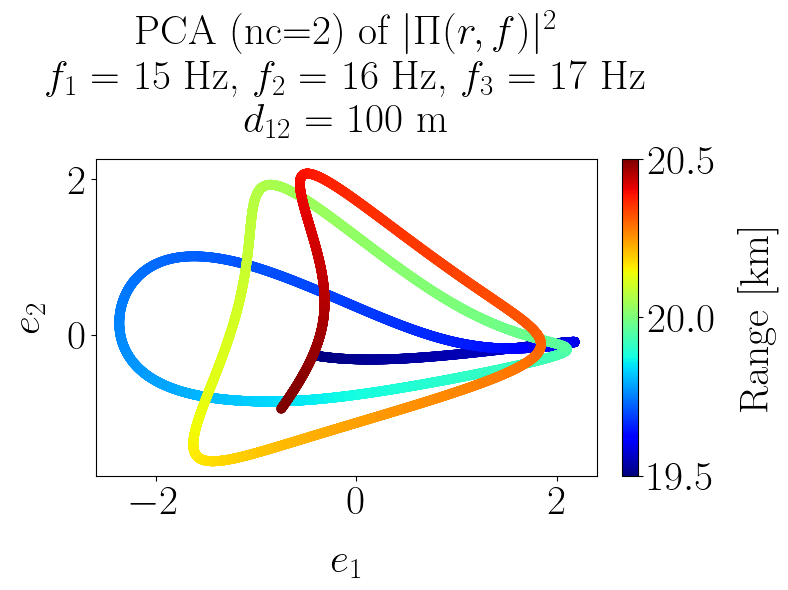

In [79]:
from sklearn.decomposition import PCA

data = np.array([Pi_f1, Pi_f2, Pi_f3]).T
X = PCA(n_components=n_components).fit_transform(data)


# Create figure and 3D axis
plt.figure(figsize=(8, 6))

# Scatter plot with color mapping
plt.scatter(X[:, 0], X[:, 1], c=colors, cmap="jet")

plt.colorbar(label="Range [km]")
plt.xlabel(r"$e_1$")
plt.ylabel(r"$e_2$")

plt.title(rf"PCA (nc=2) of $\lvert \Pi(r, f) \rvert^2$"+ "\n" + fr"$f_1$ = {f1} Hz, $f_2$ = {f2} Hz, $f_3$ = {f3} Hz" + "\n" + rf"$d_{{12}}$ = {{{d12}}} m")

Text(0.5, 1.0, 'PCA (nc=1) of $\\lvert \\Pi(r, f) \\rvert^2$\n$f_1$ = 15 Hz, $f_2$ = 16 Hz, $f_3$ = 17 Hz\n$d_{12}$ = {100} m')

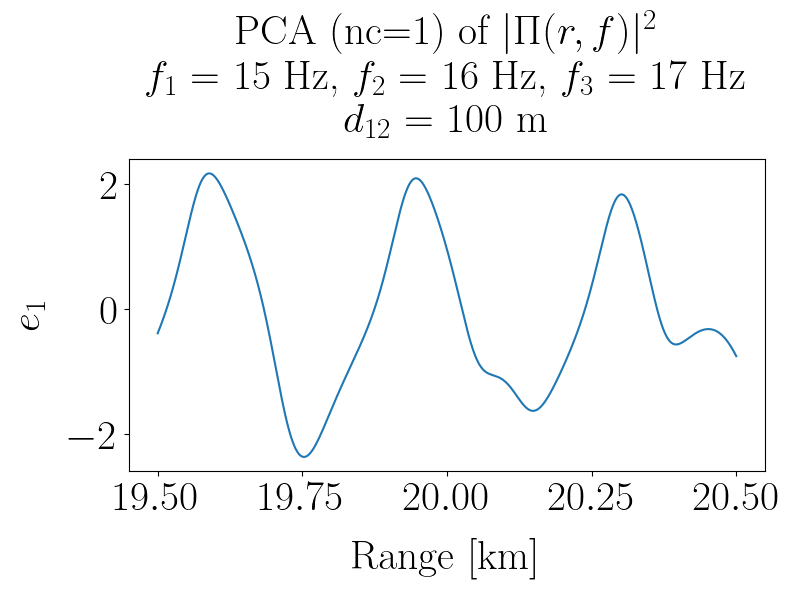

In [80]:
data = np.array([Pi_f1, Pi_f2, Pi_f3]).T
X = PCA(n_components=1).fit_transform(data)


# Create figure and 3D axis
plt.figure(figsize=(8, 6))

# Scatter plot with color mapping
sc = plt.plot(colors, X[:, 0], )

# plt.colorbar(sc, "Range [km]")
plt.xlabel("Range [km]")
plt.ylabel(r"$e_1$")

plt.title(rf"PCA (nc=1) of $\lvert \Pi(r, f) \rvert^2$"+ "\n" + fr"$f_1$ = {f1} Hz, $f_2$ = {f2} Hz, $f_3$ = {f3} Hz" + "\n" + rf"$d_{{12}}$ = {{{d12}}} m")

Text(0.5, 1.0, 'PCA (nc=1) of $\\lvert \\Pi(r, f) \\rvert^2$\n$f$ = [12 Hz, 18 Hz] (nf = {201})\n$d_{12}$ = {100} m')

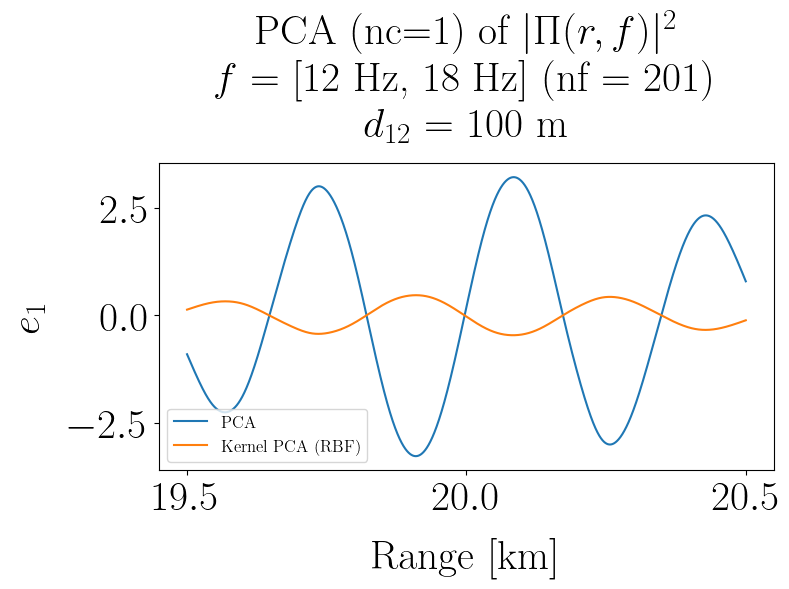

In [102]:
# Avec un nombre très important de fréquence
freqs = np.linspace(12, 18, 201)

Pi_f = []
for fi in freqs:
    Pi_fi = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=fi,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_fi = Pi_fi / np.max(np.abs(Pi_fi))
    Pi_f.append(Pi_fi)

Pi_f = np.array(Pi_f)  # nfreqs x nranges

data = Pi_f.T  # nranges x nfreqs
X_pca = PCA(n_components=1).fit_transform(data)     # Only one degree of freedom = r 
from sklearn.decomposition import KernelPCA
kernel_pca = KernelPCA(n_components=1, kernel="poly")
X_kernel_pca = kernel_pca.fit(data).transform(data)

# Create figure and 3D axis
plt.figure(figsize=(8, 6))
plt.plot(
    colors,
    X_pca[:, 0],
    label="PCA",
)
plt.plot(
    colors,
    X_kernel_pca[:, 0],
    label="Kernel PCA (RBF)",
)
plt.xlabel("Range [km]")
plt.ylabel(r"$e_1$")
plt.legend(fontsize=12)

plt.title(rf"PCA (nc=1) of $\lvert \Pi(r, f) \rvert^2$"+ "\n" + fr"$f$ = [12 Hz, 18 Hz] (nf = {{{freqs.size}}})" + "\n" + rf"$d_{{12}}$ = {{{d12}}} m")

Text(0, 0.5, '$e_2$')

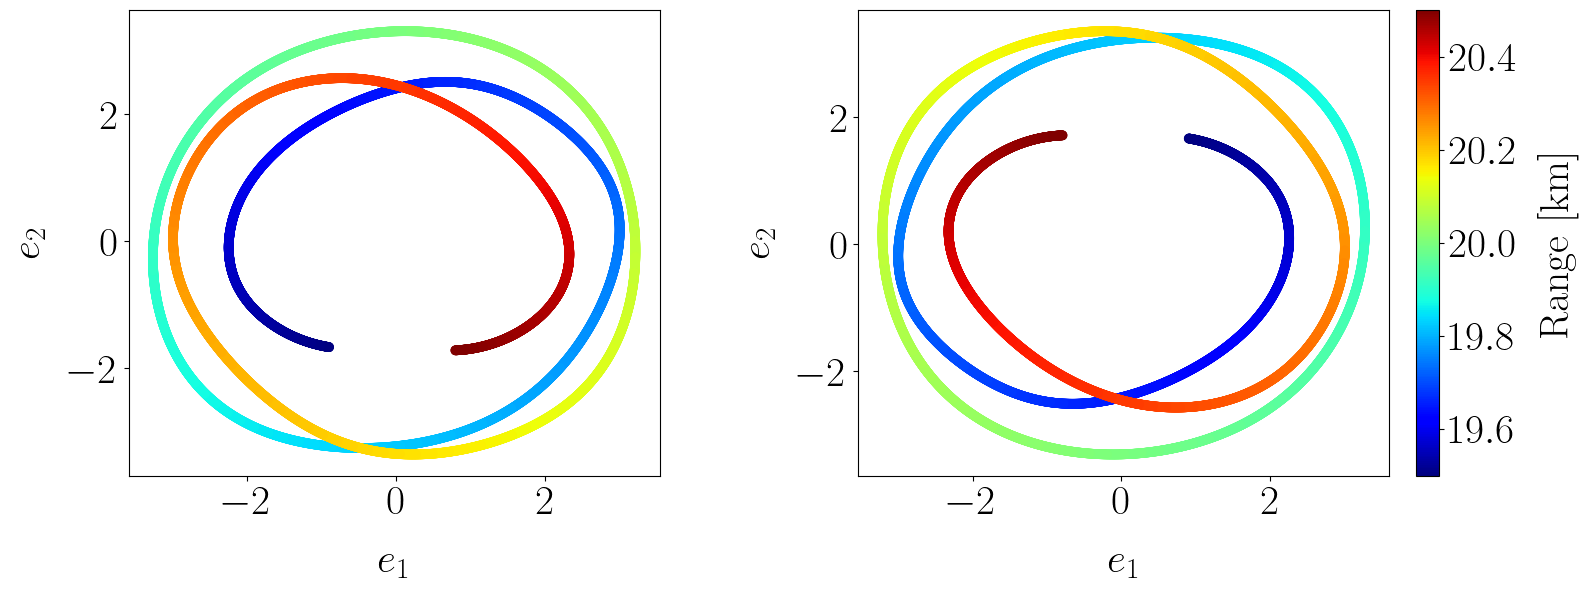

In [103]:
data = Pi_f.T  # nranges x nfreqs
n_components = 2
X_pca = PCA(n_components=n_components).fit_transform(data)  # Only one degree of freedom = r
from sklearn.decomposition import KernelPCA

kernel_pca = KernelPCA(n_components=n_components, kernel="linear")
X_kernel_pca = kernel_pca.fit(data).transform(data)

# Create figure and 3D axis
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Scatter plot with color mapping
sc = axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap="jet")
sc = axs[1].scatter(X_kernel_pca[:, 0], X_kernel_pca[:, 1], c=colors, cmap="jet")


# plt.colorbar(sc, ax=axs[0], label="Range [km]")
plt.colorbar(sc, ax=axs[1], label="Range [km]")

axs[0].set_xlabel(r"$e_1$")
axs[0].set_ylabel(r"$e_2$")
axs[1].set_xlabel(r"$e_1$")
axs[1].set_ylabel(r"$e_2$")

In [107]:
from sklearn.preprocessing import MinMaxScaler

def plot_embedding(X, title):
    _, ax = plt.subplots()
    X = MinMaxScaler().fit_transform(X)
    ax.plot(r_grid * 1e-3, X[:, 0])
    ax.set_title(title)
    ax.set_xlabel("Range [km]")
    ax.set_ylabel(r"$e_1$")

Computing Random projection embedding...
Computing Truncated SVD embedding...
Computing Isomap embedding...


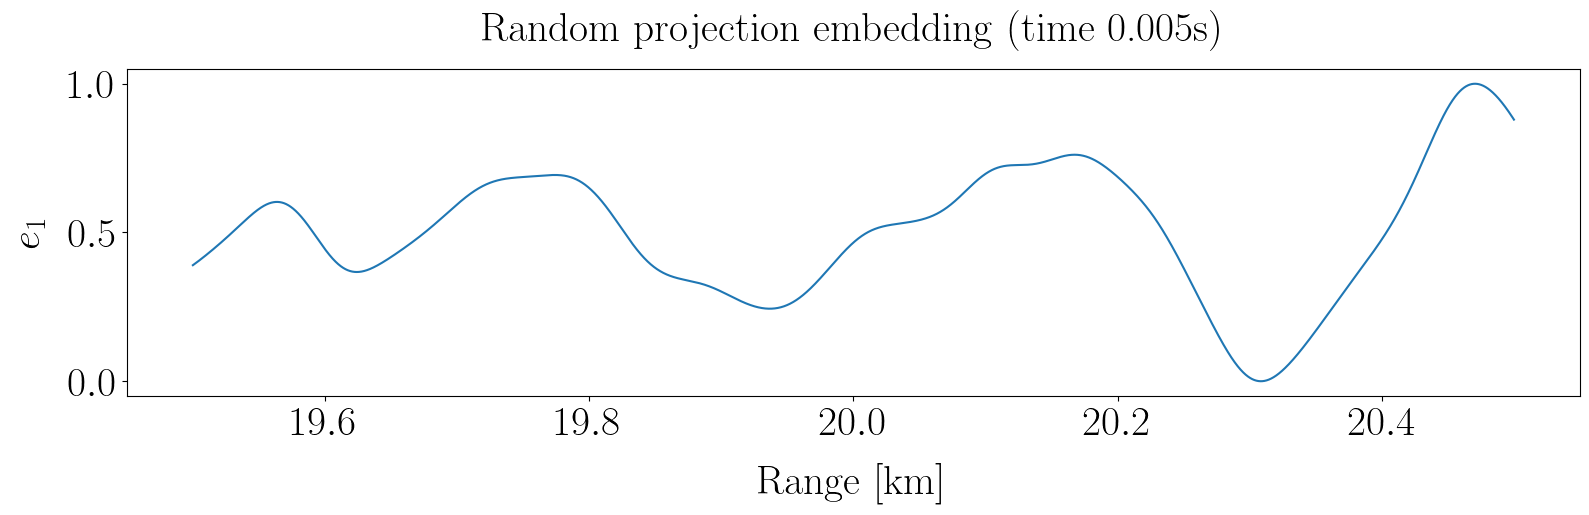

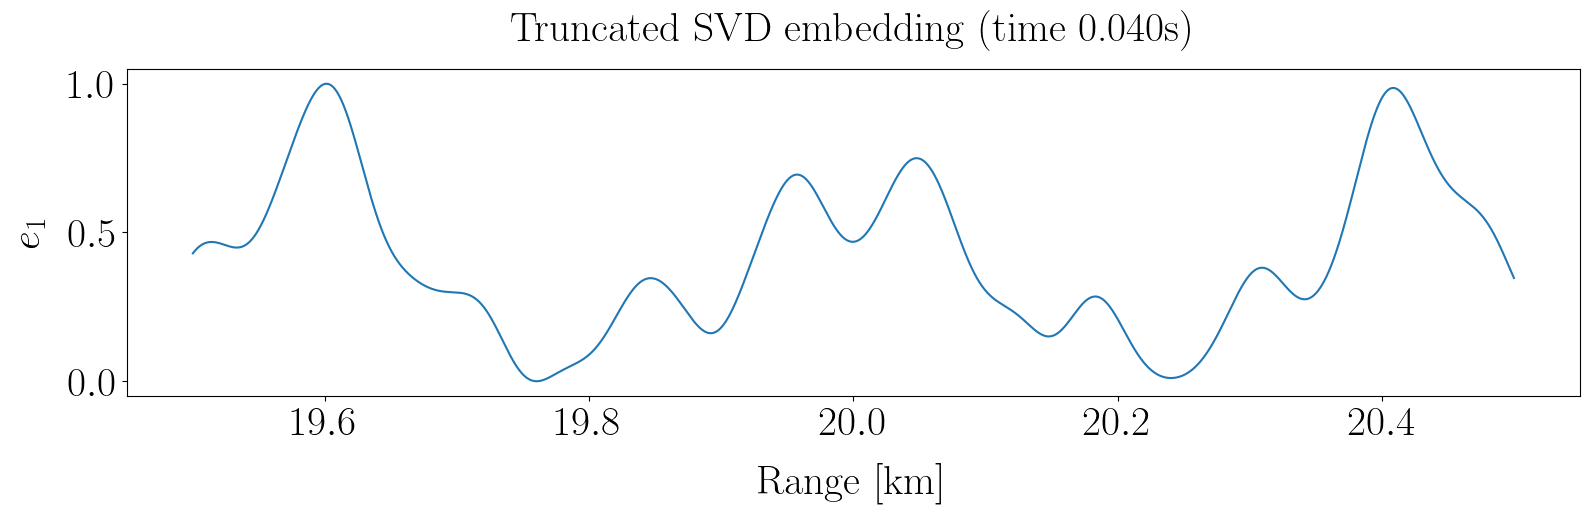

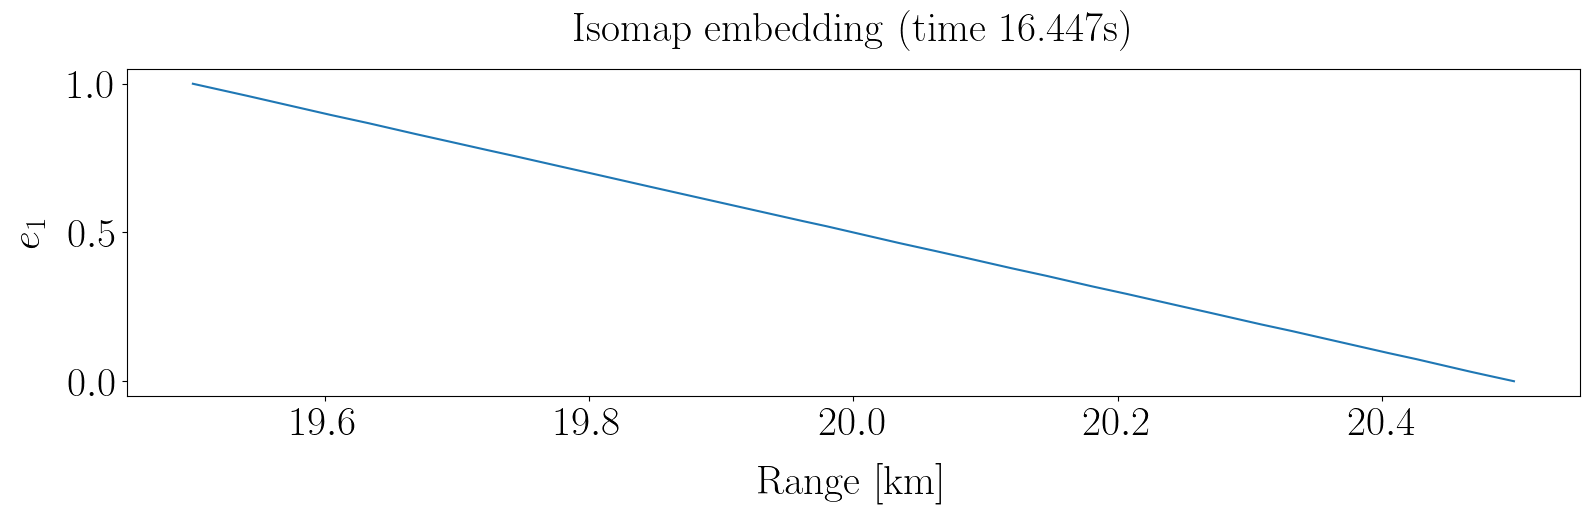

In [108]:
data = Pi_f.T  # nranges x nfreqs



# digits = load_digits(n_class=6)
# X, y = digits.data, digits.target
# n_samples, n_features = X.shape
# n_neighbors = 30

# X, y = digits.data, digits.target
X = data    
y = None
n_samples, n_features = X.shape
n_neighbors = 30
n_components = 1



from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomTreesEmbedding
from sklearn.manifold import (
    MDS,
    TSNE,
    Isomap,
    LocallyLinearEmbedding,
    SpectralEmbedding,
)
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.random_projection import SparseRandomProjection


embeddings = {
    "Random projection embedding": SparseRandomProjection(
        n_components=n_components, random_state=42
    ),
    "Truncated SVD embedding": TruncatedSVD(n_components=n_components),
    # "Linear Discriminant Analysis embedding": LinearDiscriminantAnalysis(
    #     n_components=n_components
    # ),
    "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
    # "Standard LLE embedding": LocallyLinearEmbedding(
    #     n_neighbors=n_neighbors, n_components=n_components, method="standard"
    # ),
    # "Modified LLE embedding": LocallyLinearEmbedding(
    #     n_neighbors=n_neighbors, n_components=n_components, method="modified"
    # ),
    # "Hessian LLE embedding": LocallyLinearEmbedding(
    #     n_neighbors=n_neighbors, n_components=n_components, method="hessian"
    # ),
    # "LTSA LLE embedding": LocallyLinearEmbedding(
    #     n_neighbors=n_neighbors, n_components=n_components, method="ltsa"
    # ),
    # "MDS embedding": MDS(n_components=n_components, n_init=1, max_iter=120, eps=1e-6),
    # "Random Trees embedding": make_pipeline(
    #     RandomTreesEmbedding(n_estimators=200, max_depth=5, random_state=0),
    #     TruncatedSVD(n_components=n_components),
    # ),
    # "Spectral embedding": SpectralEmbedding(
    #     n_components=n_components, random_state=0, eigen_solver="arpack"
    # ),
    # "t-SNE embedding": TSNE(
    #     n_components=n_components,
    #     max_iter=500,
    #     n_iter_without_progress=150,
    #     n_jobs=2,
    #     random_state=0,
    # ),
    # "NCA embedding": NeighborhoodComponentsAnalysis(
    #     n_components=n_components, init="pca", random_state=0
    # ),
}



Computing Random projection embedding...
Computing Truncated SVD embedding...
Computing Isomap embedding...


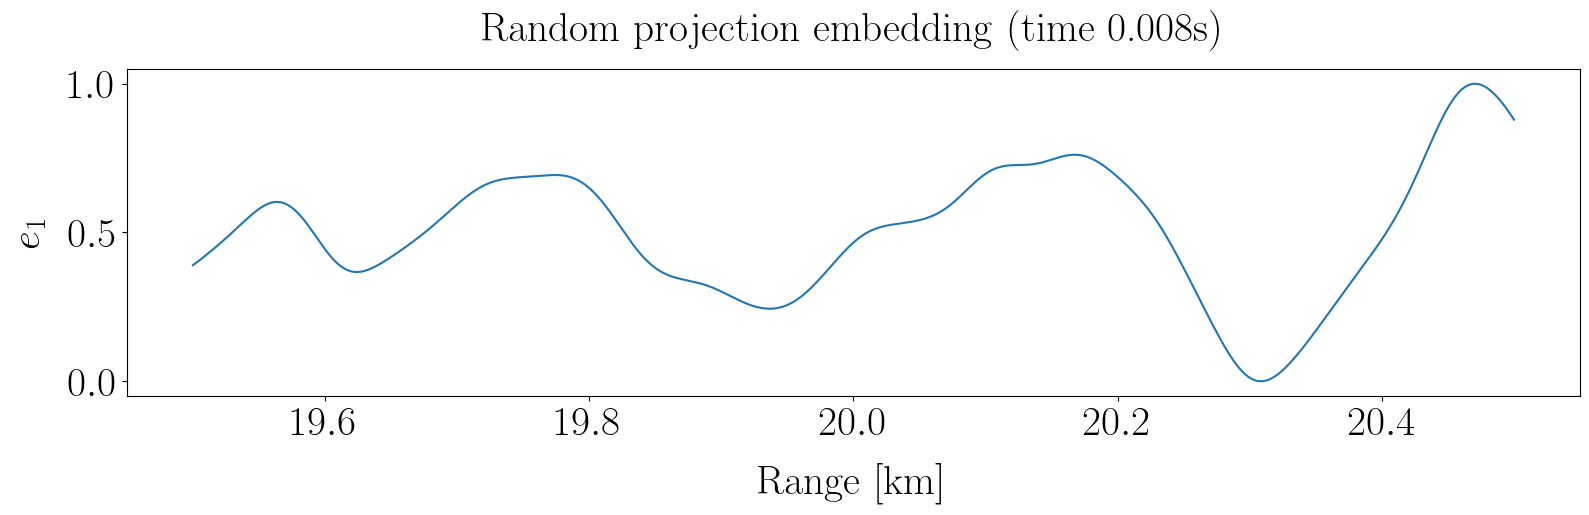

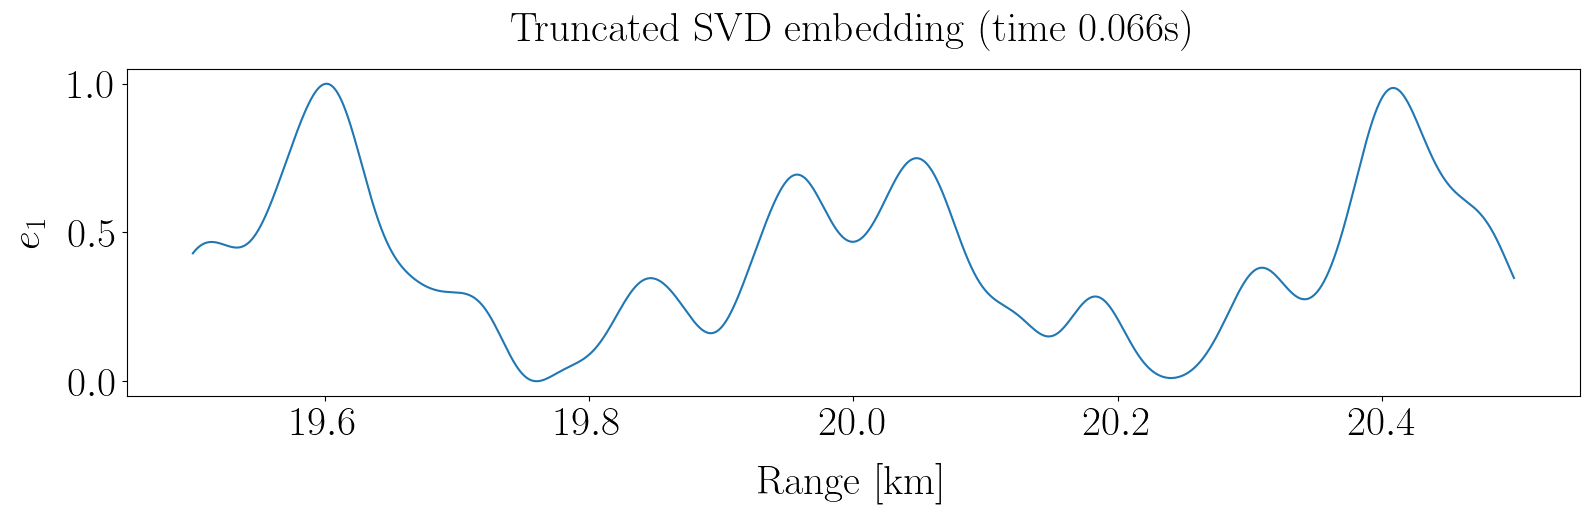

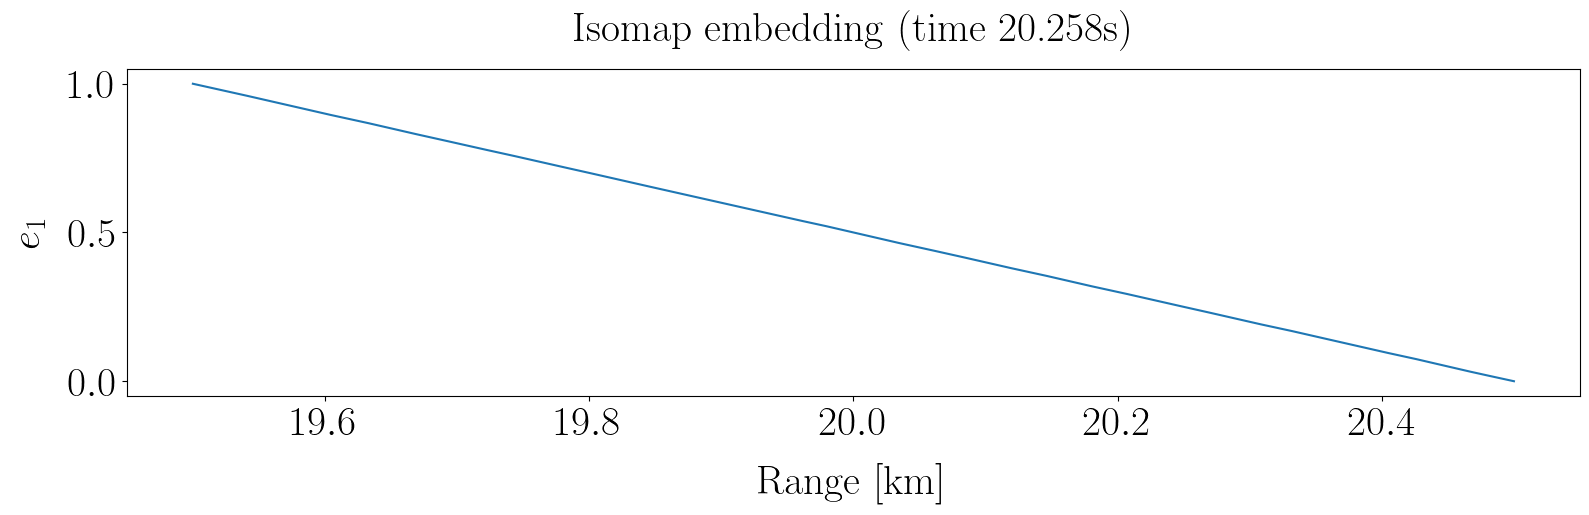

In [109]:
from time import time

projections, timing = {}, {}
for name, transformer in embeddings.items():
    if name.startswith("Linear Discriminant Analysis"):
        data = X.copy()
        data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
    else:
        data = X

    print(f"Computing {name}...")
    start_time = time()
    projections[name] = transformer.fit_transform(data, y)
    # projections[name] = transformer.fit_transform(data)

    timing[name] = time() - start_time


for name in timing:
    title = f"{name} (time {timing[name]:.3f}s)"
    plot_embedding(projections[name], title)

plt.show()

Computing Isomap embedding...


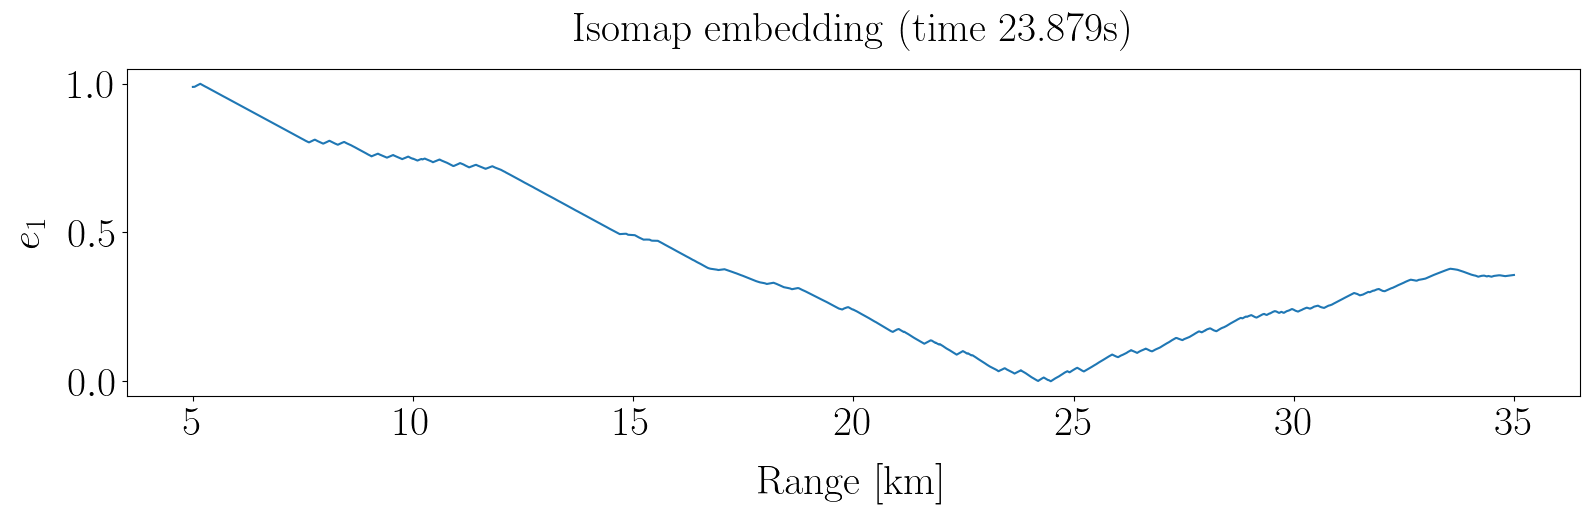

In [118]:
# Isomap on a wider range of distances
nrgrid = 10000
rc = 20 * 1e3
delta_r = 30 * 1e3
rmin = rc - delta_r / 2
rmax = rc + delta_r / 2
r_grid = np.linspace(rmin, rmax, nrgrid)
colors = r_grid * 1e-3

# Avec un nombre très important de fréquence
freqs = np.linspace(12, 18, 101)

Pi_f = []
for fi in freqs:
    Pi_fi = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=fi,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_fi = Pi_fi / np.max(np.abs(Pi_fi))
    Pi_f.append(Pi_fi)

Pi_f = np.array(Pi_f)  # nfreqs x nranges

data = Pi_f.T  # nranges x nfreqs
X = data
y = None
n_samples, n_features = X.shape
n_neighbors = 30
n_components = 1


embeddings = {
    "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
}

projections, timing = {}, {}
for name, transformer in embeddings.items():
    if name.startswith("Linear Discriminant Analysis"):
        data = X.copy()
        data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
    else:
        data = X

    print(f"Computing {name}...")
    start_time = time()
    projections[name] = transformer.fit_transform(data, y)
    # projections[name] = transformer.fit_transform(data)

    timing[name] = time() - start_time


for name in timing:
    title = f"{name} (time {timing[name]:.3f}s)"
    plot_embedding(projections[name], title)

plt.show()

Computing Isomap embedding...


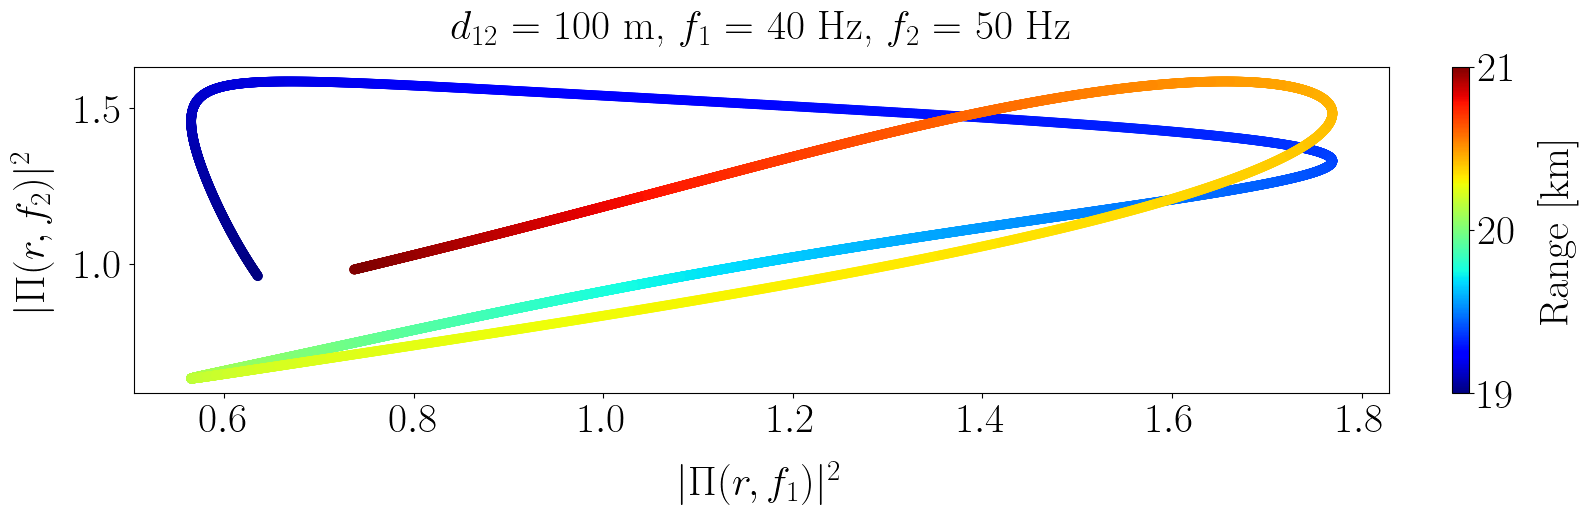

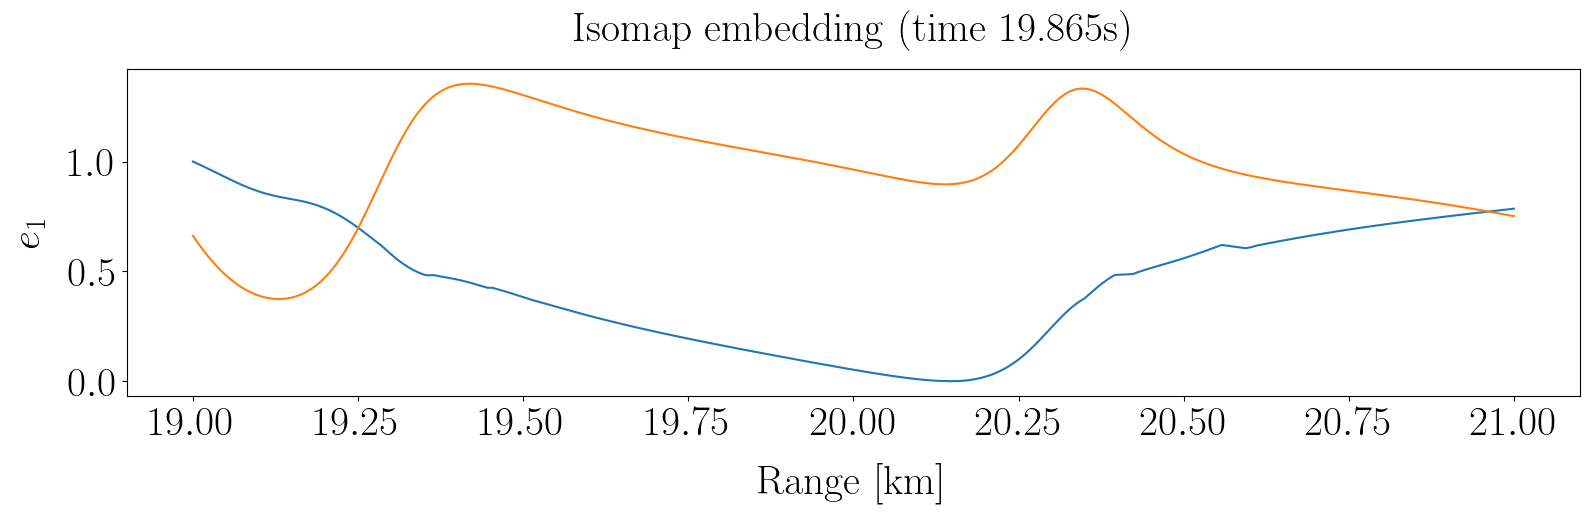

In [183]:
# Comparaison de la représentation du plan (Pi(f1), Pi(f2)) et de la projection sur le vecteur e1 trouvé par isomap
# pour le même couple de fréquence f1 f2

nrgrid = 10000
rc = 20 * 1e3
delta_r = 2 * 1e3
rmin = rc - delta_r / 2
rmax = rc + delta_r / 2
r_grid = np.linspace(rmin, rmax, nrgrid)
colors = r_grid * 1e-3

f1, f2 = 40, 50
freqs = [f1, f2]

lfig = LargeFigure()
plt.figure()

d12 = 100
Pi_f1 = Pi2_asympto_M2(
    r=r_grid,
    d12=d12,
    f=f1,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)
Pi_f2 = Pi2_asympto_M2(
    r=r_grid,
    d12=d12,
    f=f2,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)

plt.scatter(Pi_f1, Pi_f2, c=colors, cmap="jet", linestyle="-", zorder=10)


# plt.legend()
plt.xlabel(r"$\lvert \Pi(r, f_1) \rvert^2$")
plt.ylabel(r"$\lvert \Pi(r, f_2) \rvert^2$")
plt.colorbar(label="Range [km]")
plt.title(rf"$d_{{12}}$ = {{{d12}}} m, $f_1$ = {f1} Hz, $f_2$ = {f2} Hz")


Pi_f = np.array([Pi_f1, Pi_f2])
data = Pi_f.T  # nranges x nfreqs
X = data
y = None
n_samples, n_features = X.shape
n_neighbors = 30
n_components = 1

embeddings = {
    "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
}

projections, timing = {}, {}
for name, transformer in embeddings.items():
    if name.startswith("Linear Discriminant Analysis"):
        data = X.copy()
        data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
    else:
        data = X

    print(f"Computing {name}...")
    start_time = time()
    projections[name] = transformer.fit_transform(data, y)
    # projections[name] = transformer.fit_transform(data)

    timing[name] = time() - start_time



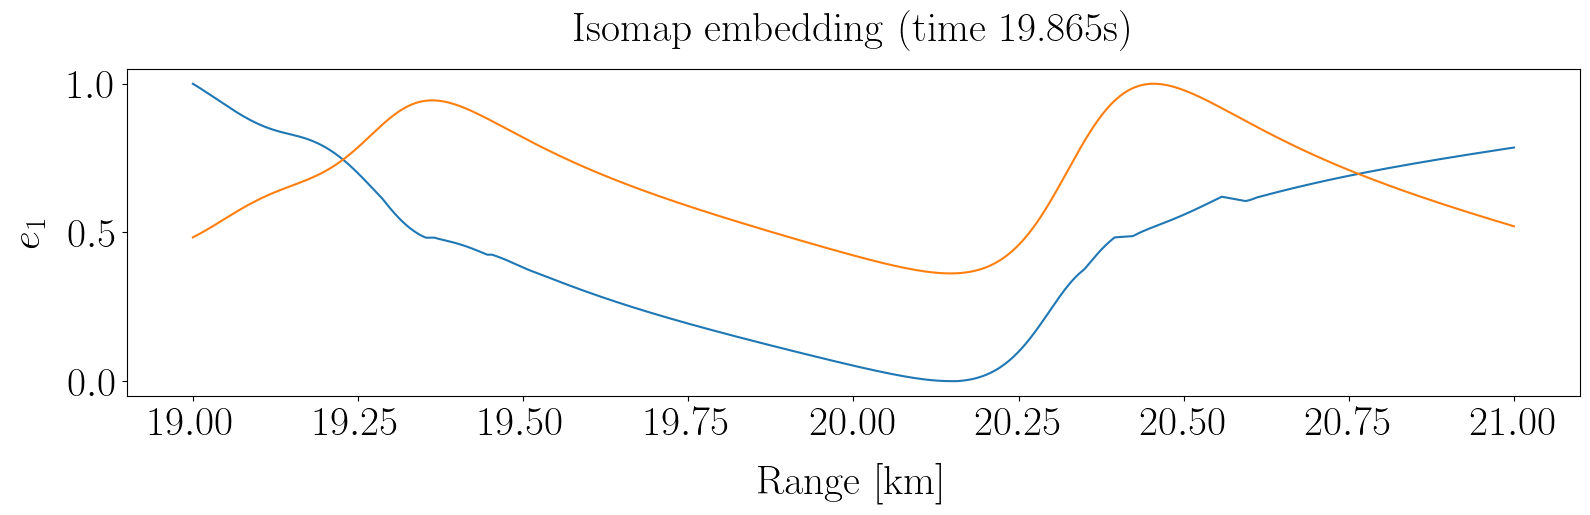

In [187]:
plt.figure()
for name in timing:
    title = f"{name} (time {timing[name]:.3f}s)"
    # plot_embedding(projections[name], title)

    X_ = MinMaxScaler().fit_transform(projections[name])
    plt.plot(r_grid * 1e-3, X_[:, 0])

plt.plot(r_grid * 1e-3, (Pi_f1 + Pi_f2) / np.max(Pi_f1 + Pi_f2))
plt.title(title)
plt.xlabel("Range [km]")
plt.ylabel(r"$e_1$")

# plt.legend(fontsize=12)
plt.show()

In [167]:
# Avec un nombre très important de fréquence
proj_nf = []
nf = [2, 5, 10, 50, 100]
for nf_i in nf:
    freqs = np.linspace(40, 50, nf_i)

    Pi_f = []
    for fi in freqs:
        Pi_fi = Pi2_asympto_M2(
            r=r_grid,
            d12=d12,
            f=fi,
            z_src=z_src,
            z_rcv=z_antenna,
            depth=D,
            bottom_bc=bottom_bc,
        )
        Pi_fi = Pi_fi / np.max(np.abs(Pi_fi))
        Pi_f.append(Pi_fi)

    Pi_f = np.array(Pi_f)  # nfreqs x nranges
    Pi_f = 10 * np.log10(Pi_f)
    
    data = Pi_f.T  # nranges x nfreqs
    X = data
    y = None
    n_samples, n_features = X.shape
    n_neighbors = 30
    n_components = 1

    embeddings = {
        "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
    }

    projections, timing = {}, {}
    for name, transformer in embeddings.items():
        if name.startswith("Linear Discriminant Analysis"):
            data = X.copy()
            data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
        else:
            data = X

        print(f"Computing {name}...")
        start_time = time()
        projections[name] = transformer.fit_transform(data, y)
        # projections[name] = transformer.fit_transform(data)

        timing[name] = time() - start_time

    proj_nf.append(projections)

Computing Isomap embedding...
Computing Isomap embedding...
Computing Isomap embedding...
Computing Isomap embedding...
Computing Isomap embedding...


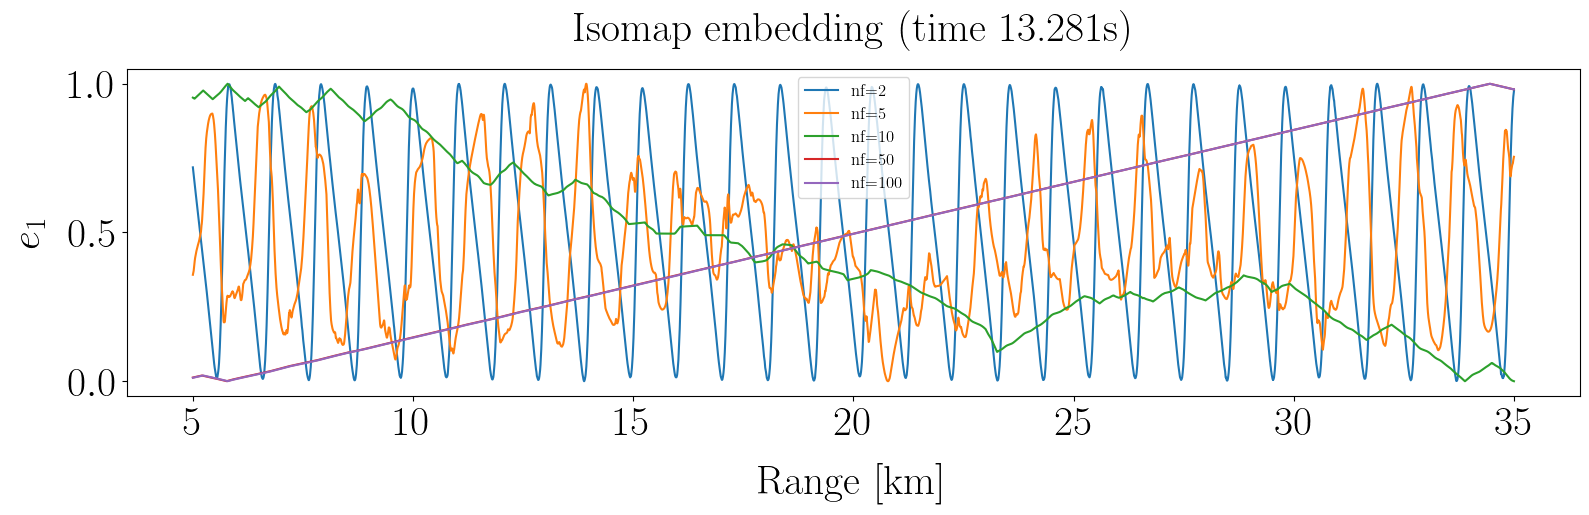

In [168]:
# nf = [2, 5, 10, 50, 100]

plt.figure()
for i_nf, projections in enumerate(proj_nf):
    for name in timing:
        title = f"{name} (time {timing[name]:.3f}s)"
        # plot_embedding(projections[name], title)

        X_ = MinMaxScaler().fit_transform(projections[name])
        plt.plot(r_grid * 1e-3, X_[:, 0], label=f"nf={nf[i_nf]}")

plt.title(title)
plt.xlabel("Range [km]")
plt.ylabel(r"$e_1$")

plt.legend(fontsize=12)
plt.show()

False
False
False
False
False


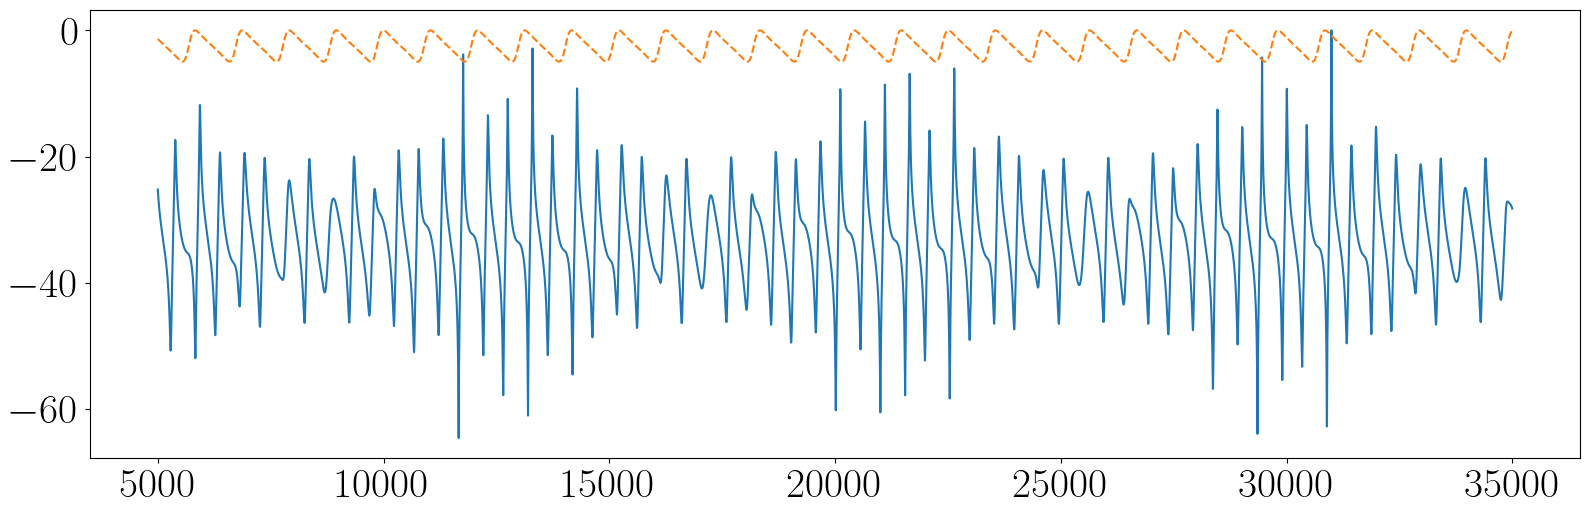

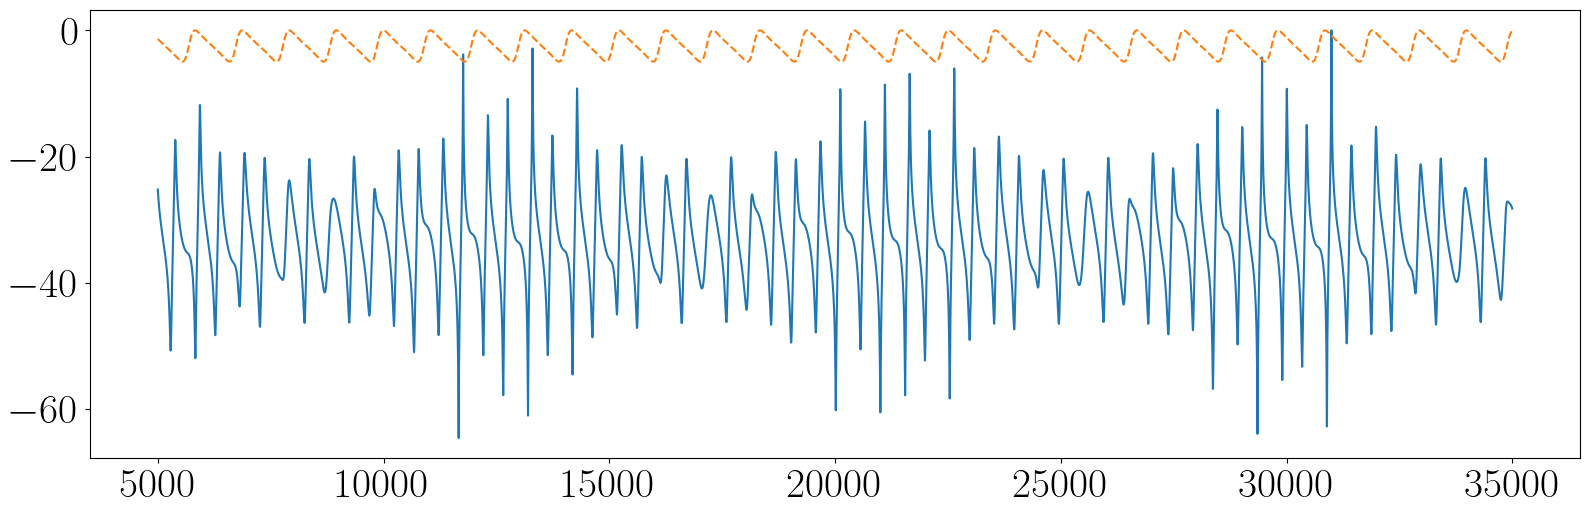

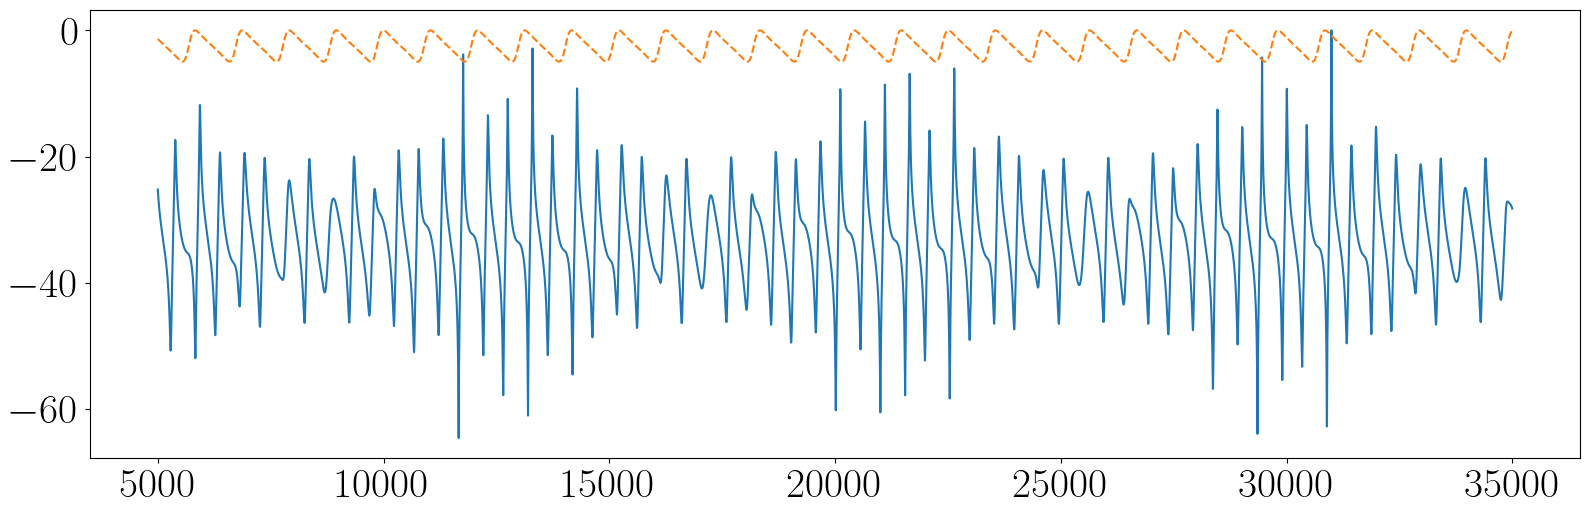

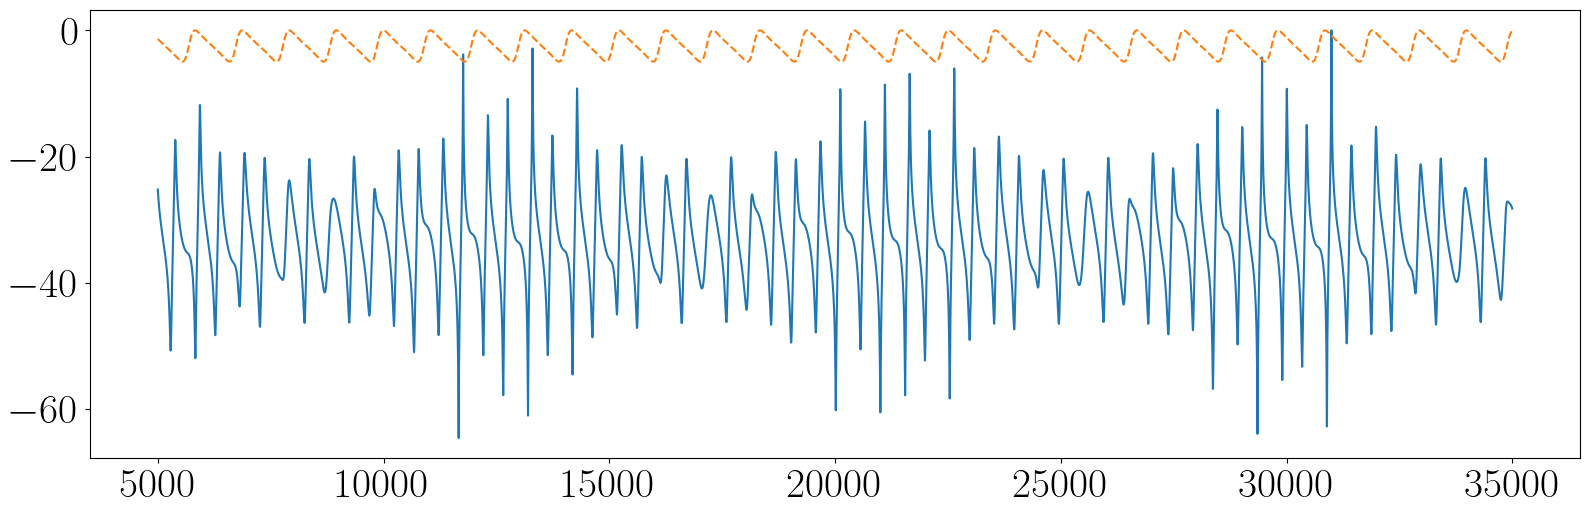

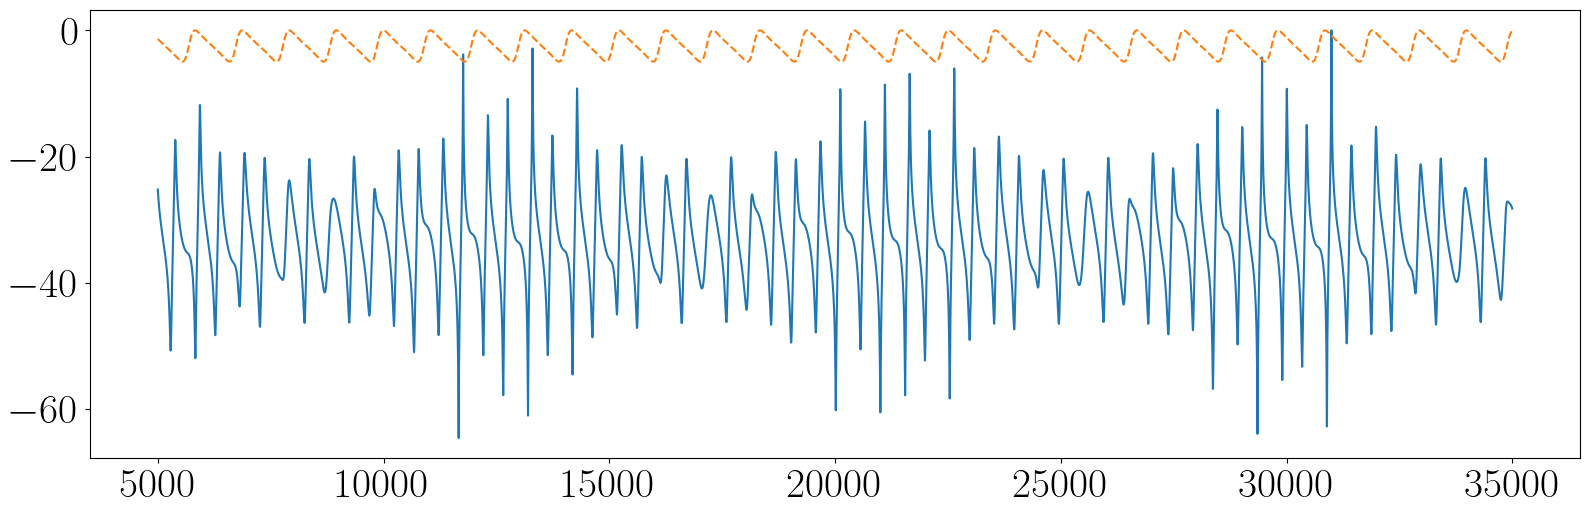

In [169]:
r_grid1 = r_grid
r_grid2 = r_grid + d12

nf = [2, 5, 10, 50, 100]
for nf_i in nf:
    freqs = np.linspace(40, 50, nf_i)

    Pi_f = []
    for fi in freqs:
        Pi_fi = Pi2_asympto_M2(
            r=r_grid,
            d12=d12,
            f=fi,
            z_src=z_src,
            z_rcv=z_antenna,
            depth=D,
            bottom_bc=bottom_bc,
        )
        Pi_fi = Pi_fi / np.max(np.abs(Pi_fi))
        Pi_f.append(Pi_fi)

    Pi_f_1 = 10*np.log10(np.array(Pi_f))  # nfreqs x nranges

    ff, rr, zz, p_field1 = field(
        f=freqs,
        z_src=z_antenna,
        z=z_src,
        r=r_grid1,
        depth=D,
        bottom_bc=bottom_bc,
        n=3,
    )
    ff, _, _, p_field2 = field(
        f=freqs,
        z_src=z_antenna,
        z=z_src,
        r=r_grid2,
        depth=D,
        bottom_bc=bottom_bc,
        n=3,
    )
    p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
    p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
    Pi_f = p_field2 / p_field1
    Pi_f = Pi_f.squeeze()  # nfreqs x nranges
    Pi_f = np.abs(Pi_f) ** 2
    Pi_f_2 = Pi_f / np.max(np.abs(Pi_f), axis=1).reshape(Pi_f.shape[0], 1)
    Pi_f_2 = 10 * np.log10(Pi_f_2)
    print(np.allclose(Pi_f_1, Pi_f_2))
    plt.figure()
    plt.plot(r_grid, Pi_f_2[0, :], label="2")
    plt.plot(r_grid, Pi_f_1[0, :], label="1", linestyle="--")

In [176]:
# Avec un nombre très important de fréquence
r_grid1 = r_grid
r_grid2 = r_grid + d12
# modes = [2, 3, 4, 5]
modes = [3, 4]

# nf = [2, 5, 10, 50, 100]
nf = [1000]

fcutoff_M = (np.max(modes) - 1/2) * g.c0 / (2 * D)
print(fcutoff_M)
# fmin =
proj_n_nf = []
for n in modes :
    proj_nf = []
    for nf_i in nf:
        freqs = np.linspace(40, 60, nf_i)

        ff, rr, zz, p_field1 = field(
            f=freqs, z_src=z_antenna, z=z_src, r=r_grid1, depth=D, bottom_bc=bottom_bc, n=n
        )
        ff, _, _, p_field2 = field(
            f=freqs,
            z_src=z_antenna,
            z=z_src,
            r=r_grid2,
            depth=D,
            bottom_bc=bottom_bc,
            n=n,
        )
        p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
        p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
        Pi_f = p_field2 / p_field1
        Pi_f = Pi_f.squeeze()  # nfreqs x nranges
        Pi_f = np.abs(Pi_f) ** 2
        Pi_f = Pi_f / np.max(np.abs(Pi_f), axis=1).reshape(Pi_f.shape[0], 1)
        Pi_f = 10*np.log10(Pi_f)
        
        data = Pi_f.T  # nranges x nfreqs
        X = data
        y = None
        n_samples, n_features = X.shape
        n_neighbors = 30
        n_components = 1

        embeddings = {
            "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
        }

        projections, timing = {}, {}
        for name, transformer in embeddings.items():
            if name.startswith("Linear Discriminant Analysis"):
                data = X.copy()
                data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
            else:
                data = X

            print(f"Computing {name}...")
            start_time = time()
            projections[name] = transformer.fit_transform(data, y)
            # projections[name] = transformer.fit_transform(data)

            timing[name] = time() - start_time

        proj_nf.append(projections)
    proj_n_nf.append(proj_nf)

26.25
Computing Isomap embedding...
Computing Isomap embedding...


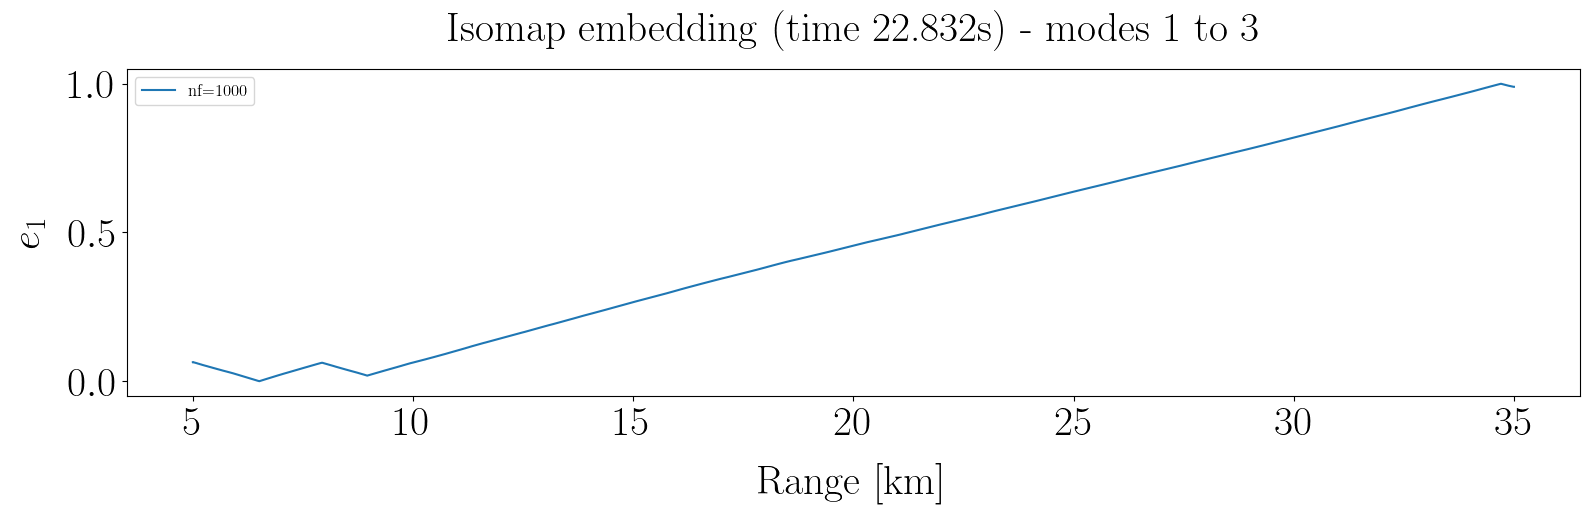

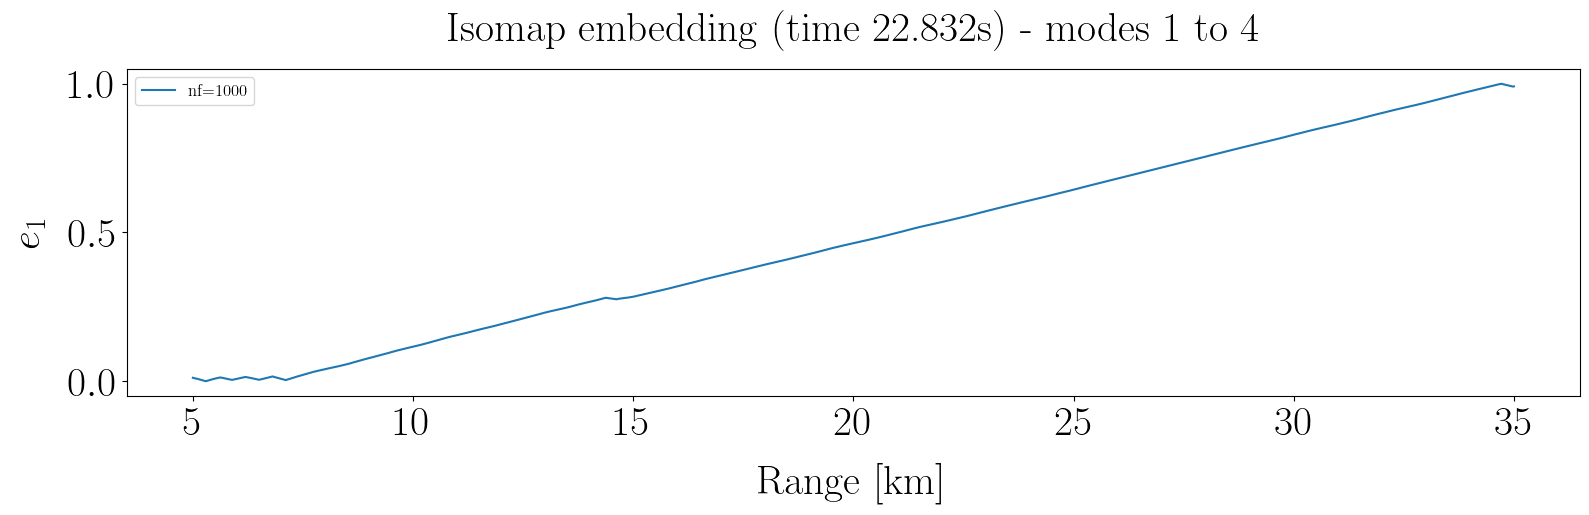

In [177]:
for i_n, n in enumerate(modes):
    plt.figure()
    proj_nf = proj_n_nf[i_n]
    for i_nf, projections in enumerate(proj_nf):
        for name in timing:
            title = f"{name} (time {timing[name]:.3f}s) - modes 1 to {n}"
            # plot_embedding(projections[name], title)

            X_ = MinMaxScaler().fit_transform(projections[name])
            plt.plot(r_grid1 * 1e-3, X_[:, 0], label=f"nf={nf[i_nf]}")
    plt.title(title)
    plt.xlabel("Range [km]")
    plt.ylabel(r"$e_1$")

    plt.legend(fontsize=12)
    plt.show()

Text(0.5, 0, '$\\lvert \\Pi(r, f_3) \\rvert^2$')

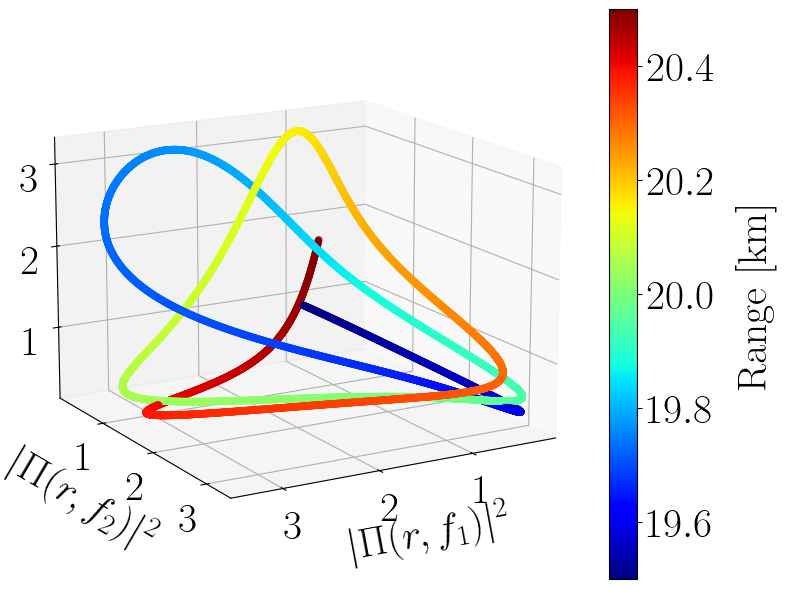

In [49]:
# Create figure and 3D axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

modes = [2]

for d12 in d:
    __, __, Pi_f1 = pi_12_modes(
        f=f1,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f2 = pi_12_modes(
        f=f2,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f3 = pi_12_modes(
        f=f3,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    Pi_f1 = np.abs(Pi_f1) ** 2
    Pi_f2 = np.abs(Pi_f2) ** 2
    Pi_f3 = np.abs(Pi_f3) ** 2
    # Pi_f1 = np.abs(Pi_f1)
    # Pi_f2 = np.abs(Pi_f2)
    # Pi_f3 = np.abs(Pi_f3)

    # Scatter plot with color mapping
    sc = ax.scatter3D(Pi_f1, Pi_f2, Pi_f3, c=colors, cmap="jet")
    plt.colorbar(sc, ax=ax, label="Range [km]")

    ax.plot(Pi_f1, Pi_f2, Pi_f3)


# Customization
ax.view_init(elev=15, azim=60)  # Adjust view angle

ax.set_xlabel(r"$\lvert \Pi(r, f_1) \rvert^2$")
ax.set_ylabel(r"$\lvert \Pi(r, f_2) \rvert^2$")
ax.set_zlabel(r"$\lvert \Pi(r, f_3) \rvert^2$")

Text(0.5, 0, '$\\phi (\\Pi(r, f_3))$')

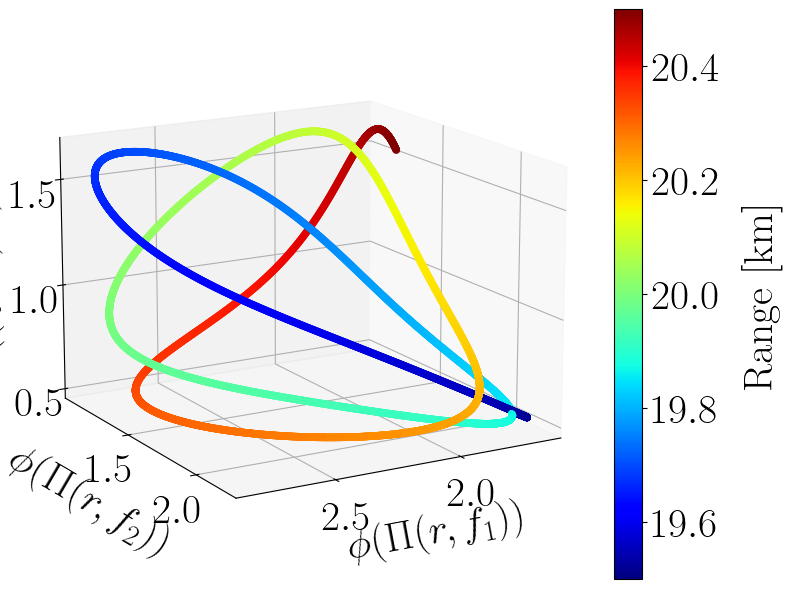

In [50]:
# Create figure and 3D axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

modes = [2]

for d12 in d:
    __, __, Pi_f1 = pi_12_modes(
        f=f1,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f2 = pi_12_modes(
        f=f2,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f3 = pi_12_modes(
        f=f3,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    Pi_f1 = np.angle(Pi_f1)
    Pi_f2 = np.angle(Pi_f2)
    Pi_f3 = np.angle(Pi_f3)

    # Scatter plot with color mapping
    sc = ax.scatter3D(Pi_f1, Pi_f2, Pi_f3, c=colors, cmap="jet")
    plt.colorbar(sc, ax=ax, label="Range [km]")

    ax.plot(Pi_f1, Pi_f2, Pi_f3)


# Customization
ax.view_init(elev=15, azim=60)  # Adjust view angle

ax.set_xlabel(r"$\phi (\Pi(r, f_1))$")
ax.set_ylabel(r"$\phi (\Pi(r, f_2))$")
ax.set_zlabel(r"$\phi (\Pi(r, f_3))$")

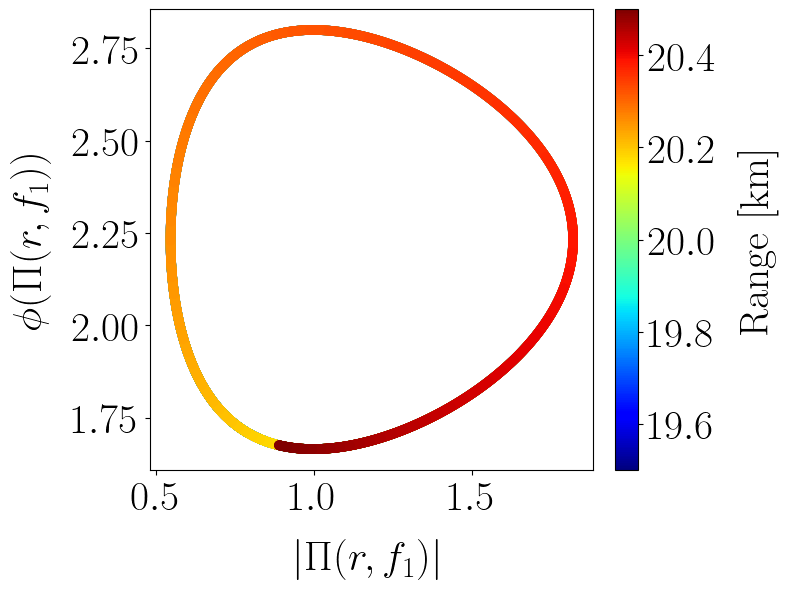

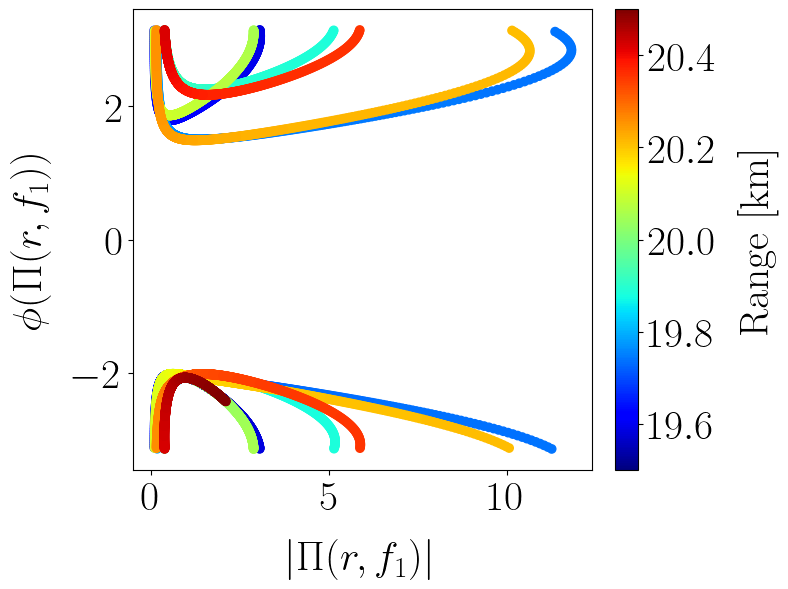

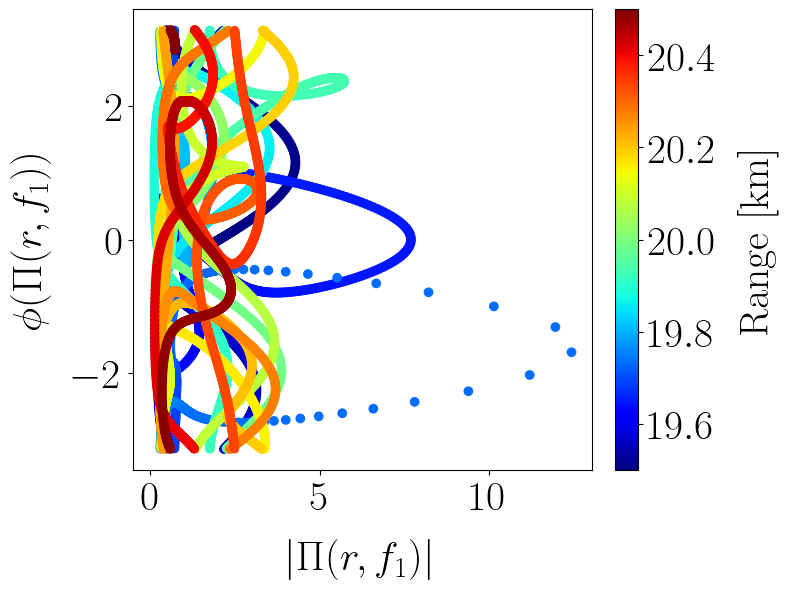

In [51]:
# Create figure and 3D axis

f1, f2, f3 = 15, 20, 100
modes = [13]

for d12 in d:
    for fi in [f1, f2, f3]:

        fig = plt.figure(figsize=(8, 6))
        __, __, Pi_f1 = pi_12_modes(
            f=fi,
            z_antenna=z_antenna,
            z_grid=z_src,
            r_grid=r_grid,
            d12=d12,
            depth=D,
            bottom_bc=bottom_bc,
            modes=modes,
        )

        Pi_f1_phi = np.angle(Pi_f1)
        Pi_f1_mod= np.abs(Pi_f1)

        # Scatter plot with color mapping
        plt.scatter(
            Pi_f1_mod, Pi_f1_phi, c=colors, cmap="jet", linestyle="-", zorder=10
        )
        plt.ylabel(r"$\phi (\Pi(r, f_1))$")
        plt.xlabel(r"$\lvert \Pi(r, f_1) \rvert$")
        plt.colorbar(label="Range [km]")

Text(0.5, 0, '$\\lvert \\Pi(r, f_2) \\rvert$')

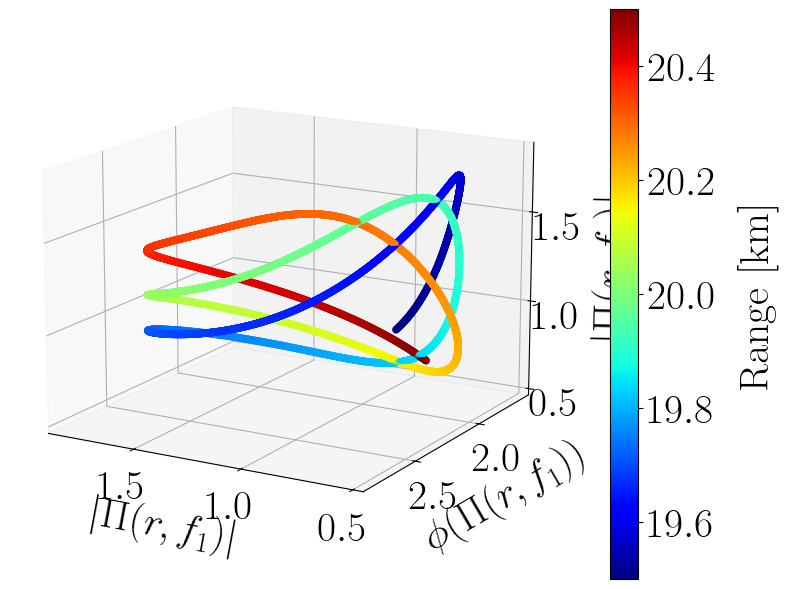

In [52]:
# Create figure and 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

f1, f2 = 15, 16
modes = [2]

for d12 in d:
    __, __, Pi_f1 = pi_12_modes(
        f=f1,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f2 = pi_12_modes(
        f=f2,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )

    Pi_f1_mod = np.abs(Pi_f1)
    Pi_f1_arg = np.angle(Pi_f1)
    Pi_f2_mod = np.abs(Pi_f2)
    Pi_f2_arg = np.angle(Pi_f2)

    # Scatter plot with color mapping
    sc = ax.scatter3D(Pi_f1_mod, Pi_f1_arg, Pi_f2_mod, c=colors, cmap="jet")
    # sc = ax.scatter3D(Pi_f1_mod, Pi_f1_arg, Pi_f2_arg, c=colors, cmap="jet")
    # sc = ax.plot3D(Pi_f1_mod, Pi_f1_arg, Pi_f2_arg)

    plt.colorbar(sc, ax=ax, label="Range [km]")


# Customization
ax.view_init(elev=15, azim=120)  # Adjust view angle

ax.set_xlabel(r"$\lvert \Pi(r, f_1) \rvert$")
ax.set_ylabel(r"$\phi (\Pi(r, f_1))$")
ax.set_zlabel(r"$\lvert \Pi(r, f_2) \rvert$")

In [53]:
# # Compute RTF on the whole grid for a different number of modes
# n_modes = [1, 2, 3]

# pi_12 = []
# for n in n_modes:
#     ff, rr, zz, p_field1 = field(
#         f=f0, z_src=z_antenna, z=z_grid, r=r_grid1, depth=D, bottom_bc=bottom_bc, n=n
#     )
#     ff, _, _, p_field2 = field(
#         f=f0, z_src=z_antenna, z=z_grid, r=r_grid2, depth=D, bottom_bc=bottom_bc, n=n
#     )
#     p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
#     p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
#     pi_12.append(p_field2 / p_field1)
# pi_12 = np.array(pi_12)

In [54]:
# sfig = LargeFigure(size=(16, 10))

# abcd_labels = ["a", "b", "c", "d", "e", "f"]
# for i, n in enumerate(n_modes):
#     fig, axs = plt.subplots(f.size, sharex=True)
#     for idx_freq, freq in enumerate(f):
#         # Plot Pi for each freq at given number of modes
#         title = f"{n} modes - {freq} Hz"
#         # Plot TL
#         pi = 20 * np.log10(np.abs(pi_12[i, idx_freq]))
#         vmin = np.percentile(pi, 25)
#         vmax = np.percentile(pi, 75)
#         im = axs[idx_freq].pcolormesh(
#             rr * 1e-3,
#             zz,
#             pi,
#             vmin=vmin,
#             vmax=vmax,
#             cmap="jet_r",
#             rasterized=True,
#         )
#         axs[idx_freq].invert_yaxis()

#         # Add a, b, c labels
#         axs[idx_freq].text(
#             0.95,
#             1.05,
#             f"({abcd_labels[i]})",
#             transform=axs[idx_freq].transAxes,
#             fontsize=25,
#             fontweight="bold",
#             va="bottom",
#         )
#         axs[idx_freq].set_title(title)

#     fig.supxlabel("Range [km]")
#     fig.supylabel("Depth [m]")

#     # Add common colorbar
#     cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
#     cbar.set_label(r"$\Pi$ [dB]")

**Remarque**
 
Le terme oscillant semble dépendre du nombre d'onde horizontal $k_{rm}$ et de la longueur d'onde associée : 
$$
\lambda_{rm} = \frac{2\pi}{k_{rm}}
$$ 
où 
$$
    k_{rm} = \sqrt{ k^2 - k_{zm}^2}
$$

avec, 

$$ 
k_{zm} =  (m - \frac{1}{2}) \frac{\pi}{D}, \quad m \in \mathbb{N}^{*} .
$$
           




In [55]:
# idx_freq = -1
# for i_m, m in enumerate(n_modes):
#     peak_k_r_if_in = peak_k_r[i_m, idx_freq]
#     print(f"Mode {m} :  k_r(peaks) = {peak_k_r_if_in} [1/m]")
#     lambda_r_if_in = 2*np.pi / peak_k_r_if_in
#     print(f"Mode {m} :  lambda_kr(peaks) = {lambda_r_if_in} [m]")

In [56]:
# for fi in f[-1:]:
#     print(f"Fréquence f = {fi} Hz")
#     for i_m, m in enumerate(modes):
#         lambda_m = lambda_rm(f=100, m=m)
#         print(f"Mode {m}: lambda = {lambda_m:.2f} m")

#         for i_n in range(i_m+1, len(modes)):
#             n = modes[i_n]
#             k_rm = kr(m, f=fi, depth=D, bottom_bc=bottom_bc)
#             k_rn = kr(n, f=fi, depth=D, bottom_bc=bottom_bc)
#             delta_kmn = k_rm - k_rn
#             l_delta = 2*np.pi / delta_kmn
#             print(f"L_mn (m={m}, n={n}) =  {l_delta:.2f} m")

In [57]:
# # Plot FFT results
# lfig = LargeFigure(size=(8, 6), legend_fontsize=6)
# peak_k_r = np.empty((len(n_modes), len(f)), dtype=object)

# for idx_freq, freq in enumerate(f):
#     plt.figure()
#     for i_mode, n in enumerate(n_modes):
#         plt.plot(
#             2*np.pi/k_r * 1e-3,
#             np.abs(pi_12_abs_fft[i_mode, idx_freq]),
#             label=f"{n} modes",
#             color=color(i_mode),
#         )

#         peaks, properties = find_peaks(
#             np.abs(pi_12_abs_fft[i_mode, idx_freq]), distance=10
#         )
#         peak_k_r_if_in = k_r[peaks]
#         # Store
#         peak_k_r[i_mode, idx_freq] = peak_k_r_if_in
#         print(f"Frequency {freq} Hz - {n} modes - Peak k_r: {peak_k_r_if_in}")

#         # Annotate peaks
#         plt.scatter(
#             2 * np.pi / peak_k_r_if_in * 1e-3,
#             np.abs(pi_12_abs_fft[i_mode, idx_freq])[peaks],
#             color=color(i_mode),
#             s=20,
#         )

#     plt.legend()
#     plt.xlabel(r"$\lambda_r = \frac{2\pi}{k_r}$ [km]")
#     plt.ylabel(r"FFT amplitude")
#     plt.title(r"FFT of $\lvert \Pi(r, z=z_s) \rvert$" + f" - f = {freq} Hz")
#     plt.xlim([0, 20])
#     # plt.ylim([0, 2])

In [58]:
# from scipy.stats import linregress
# for idx_freq, freq in enumerate(f):

#     plt.figure()
#     for i_mode, n in enumerate(n_modes):
#         peak_k_r_if_in = peak_k_r[i_mode, idx_freq]
#         idx_peaks = np.arange(1, len(peak_k_r_if_in) + 1)
#         plt.scatter(
#             idx_peaks,
#             peak_k_r_if_in,
#             label=f"{n} modes",
#             color=color(i_mode),
#         )

#         # Compute linear fit
#         result = linregress(idx_peaks, peak_k_r_if_in)
#         slope = result.slope
#         intercept = result.intercept

#         print(f"Frequency {freq} Hz - {n} modes - Linear fit: k_r = {slope:.6e} * idx + {intercept:.6e}")
#         # Plot linear fit
#         plt.plot(
#             idx_peaks,
#             intercept + slope * idx_peaks,
#             linestyle="--",
#             color=color(i_mode),
#             label=f"Fit {n} modes",
#         )
#     plt.legend()
#     plt.xlabel("Peak index")
#     plt.ylabel(r"Peak $k_r$ [1/m]")
#     plt.title(r"Peaks of FFT of $\lvert \Pi(r, z=z_s) \rvert$"  + f" - f = {freq} Hz")

In [59]:
# i_mode = 1
# n = modes[i_mode]

# peak_k_r_if_in = peak_k_r[i_mode, idx_freq]
# idx_peaks = np.arange(1, len(peak_k_r_if_in) + 1)

# ratio = peak_k_r_if_in[1:] / peak_k_r_if_in[0] 
# print(f"Frequency {freq} Hz - {n} modes - Peaks: {peak_k_r_if_in}")
# print(f"Frequency {freq} Hz - {n} modes - Ratio of peaks to peaks 1: {ratio}")

In [60]:
# peak_kr0 = peak_k_r_if_in[-1]
# lambda_kr0 = 2*np.pi/peak_kr0

# print(f"Frequency {freq} Hz - {n} modes - Lambda_kr0: {lambda_kr0}m")